# Epsilon Parameter Optimisation — Analysis

Analysis of the Phase 1 coarse scan: 1,944 HTCondor jobs sweeping
$k \times \theta_d \times \sigma_{\text{res}} \times \sigma_{\text{scatt}}$
at 3 angular cones and 3 track densities.

All Hamiltonians use **ERF-smoothed acceptance** (`convolution=True`).

See `experiment_plan.md` for full design details.

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path

sns.set(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 6)

DATA_DIR = Path('results/aggregated')
PLOT_DIR = Path('plots')
PLOT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_DIR / 'param_opt.csv')
print(f'Loaded {len(df)} rows, {len(df.columns)} columns')
df.head()

Loaded 1944 rows, 31 columns


,angle,n_tracks,scale,theta_d,measurement_error,collision_noise,convolution,epsilon,n_repeats,m_reconstruction_efficiency_mean,...,m_hit_efficiency_mean_mean,m_hit_efficiency_mean_se,m_hit_efficiency_weighted_mean,m_hit_efficiency_weighted_se,hit_purity_mean_primary_mean,hit_purity_mean_primary_se,hit_efficiency_mean_primary_mean,hit_efficiency_mean_primary_se,hit_efficiency_weighted_primary_mean,hit_efficiency_weighted_primary_se
0,0.04,10,1,0.0001,0.00,0.00005,True,0.000074,3,1.000000,...,0.980000,0.000000,0.0,0.0,1.0,0.0,0.980000,0.000000,0.0,0.0
1,0.04,10,1,0.0001,0.00,0.00010,True,0.000143,3,0.900000,...,0.932778,0.004339,0.0,0.0,1.0,0.0,0.932778,0.004339,0.0,0.0
2,0.04,10,1,0.0001,0.00,0.00040,True,0.000566,3,0.500000,...,0.773810,0.072179,0.0,0.0,1.0,0.0,0.773810,0.072179,0.0,0.0
3,0.04,10,1,0.0001,0.01,0.00005,True,0.001052,3,0.433333,...,0.788889,0.029397,0.0,0.0,1.0,0.0,0.788889,0.029397,0.0,0.0
4,0.04,10,1,0.0001,0.01,0.00010,True,0.001059,3,0.400000,...,0.744444,0.029397,0.0,0.0,1.0,0.0,0.744444,0.029397,0.0,0.0


In [49]:
# ── Convenience labels and derived columns ────────────────────
df['score'] = df['m_reconstruction_efficiency_mean'] * (1 - df['m_ghost_rate_mean'])

ANGLE_LABELS = {0.2: r'$\pm 0.2$ rad', 0.1: r'$\pm 0.1$ rad', 0.04: r'$\pm 0.04$ rad'}
TRACK_LABELS = {10: '10 tracks', 50: '50 tracks', 100: '100 tracks'}
TD_LABELS = {1e-4: r'$10^{-4}$', 1e-3: r'$10^{-3}$', 1e-2: r'$10^{-2}$', 1e-1: r'$10^{-1}$'}

# Short metric names for plotting
METRIC_NICE = {
    'm_reconstruction_efficiency_mean': 'Reconstruction Efficiency',
    'm_ghost_rate_mean': 'Ghost Rate',
    'm_clone_fraction_total_mean': 'Clone Fraction (total)',
    'm_clone_fraction_among_matched_mean': 'Clone Fraction (matched)',
    'm_purity_all_matched_mean': 'Hit Purity (all matched)',
    'm_purity_primary_only_mean': 'Hit Purity (primary)',
    'm_hit_efficiency_mean_mean': 'Hit Efficiency (mean)',
    'm_hit_efficiency_weighted_mean': 'Hit Efficiency (weighted)',
    'hit_purity_mean_primary_mean': 'Hit Purity (primary mean)',
    'hit_efficiency_mean_primary_mean': 'Hit Efficiency (primary mean)',
    'hit_efficiency_weighted_primary_mean': 'Hit Efficiency (primary weighted)',
    'score': 'Score (eff × (1 − ghost))',
}

ANGLES = sorted(df.angle.unique())
TRACKS = sorted(df.n_tracks.unique())
SCALES = sorted(df.scale.unique())
THETA_DS = sorted(df.theta_d.unique())
MEAS_ERRS = sorted(df.measurement_error.unique())
COLL_NOISES = sorted(df.collision_noise.unique())

print(f'Angles: {ANGLES}')
print(f'Tracks: {TRACKS}')
print(f'Scales: {SCALES}')
print(f'Theta_d: {THETA_DS}')
print(f'Score range: [{df.score.min():.3f}, {df.score.max():.3f}]')

Angles: [np.float64(0.04), np.float64(0.1), np.float64(0.2)]
Tracks: [np.int64(10), np.int64(50), np.int64(100)]
Scales: [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(10), np.int64(20)]
Theta_d: [np.float64(0.0001), np.float64(0.001), np.float64(0.01), np.float64(0.1)]
Score range: [0.000, 1.000]


---
## A. Track-Level Performance vs Scale Factor $k$

### A1. Reconstruction Efficiency vs $k$

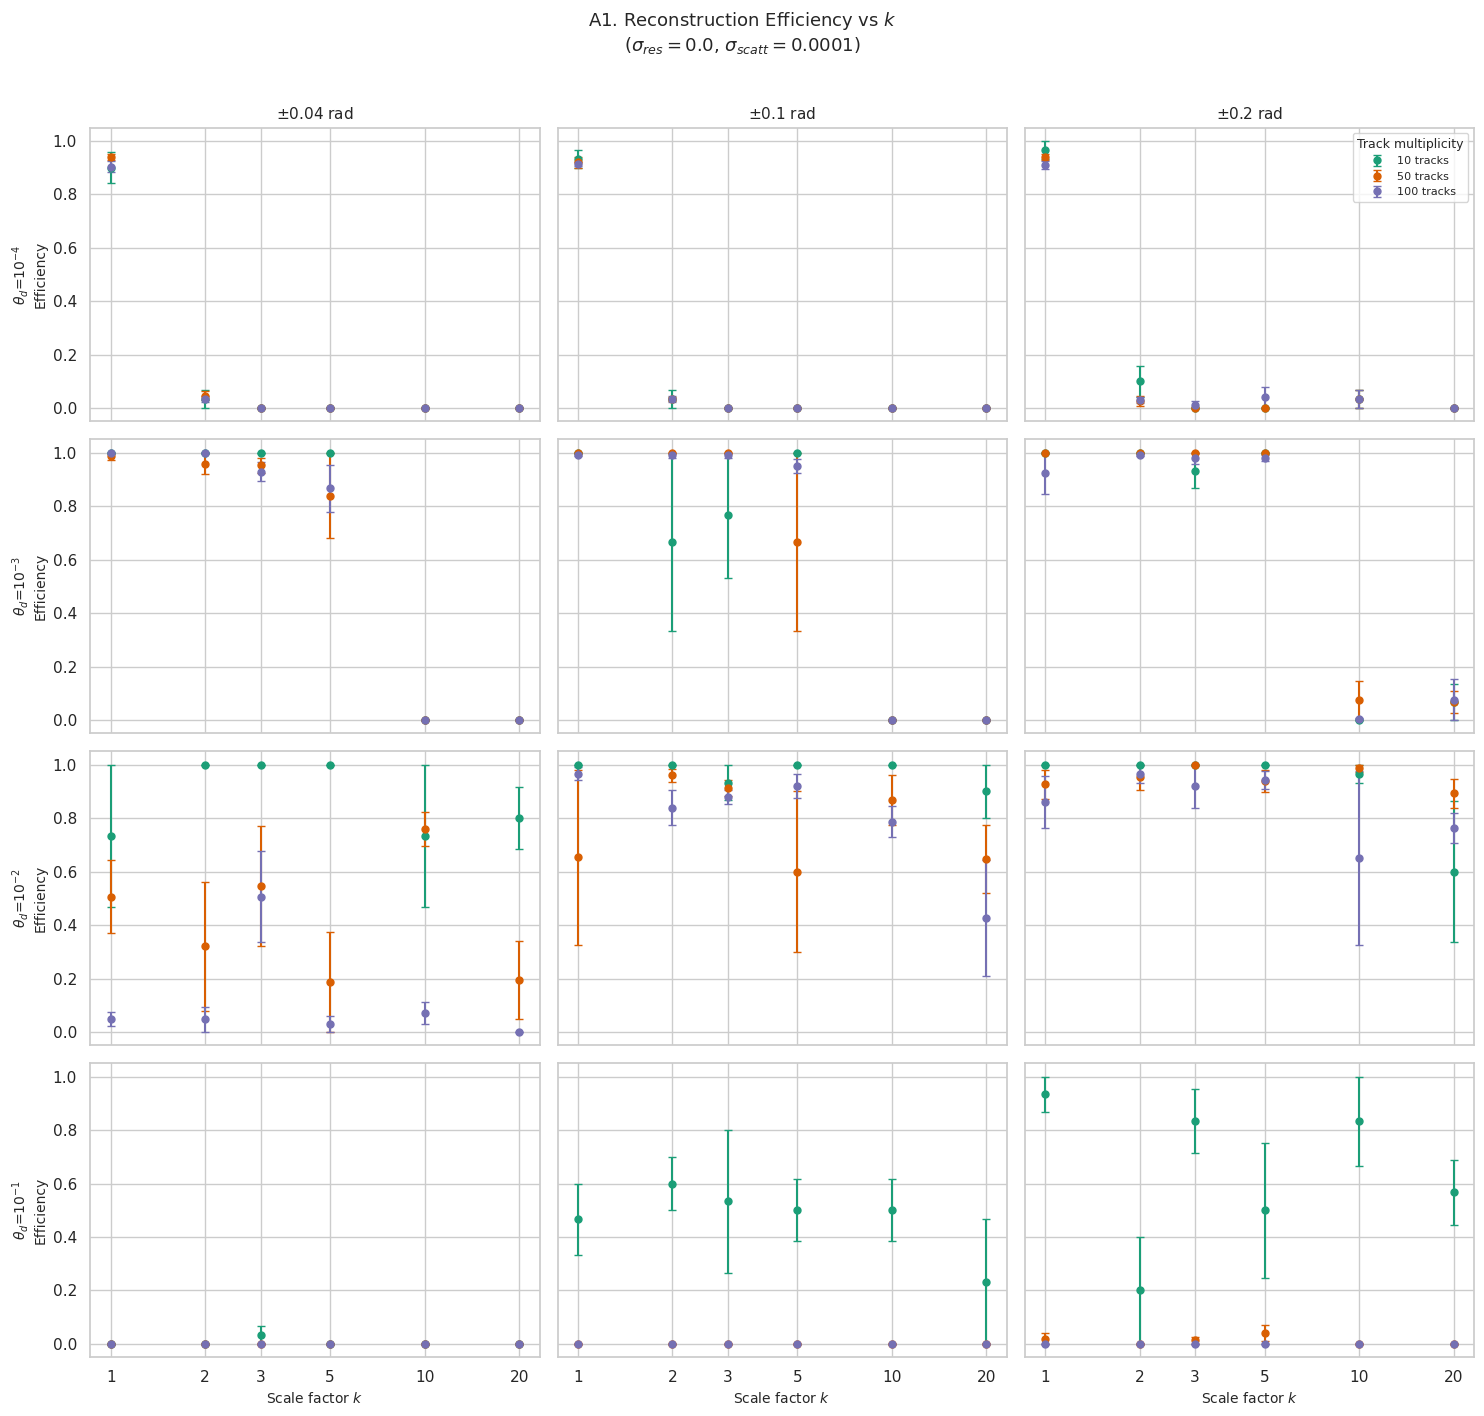

In [50]:
TRACK_COLORS = {10: '#1b9e77', 50: '#d95f02', 100: '#7570b3'}

def plot_metric_vs_k(df, metric_mean, metric_se, title, ylabel,
                     meas_err=0.0, coll_noise=1e-4, save_name=None):
    """Scatter + error-bar plot of a metric vs k, faceted by theta_d (rows) × angle (cols),
    with a different colour per track multiplicity."""
    sub = df[(df.measurement_error == meas_err) & (df.collision_noise == coll_noise)].copy()

    fig, axes = plt.subplots(len(THETA_DS), len(ANGLES), figsize=(15, 14),
                             sharex=True, sharey=True)

    for i, td in enumerate(THETA_DS):
        for j, ang in enumerate(ANGLES):
            ax = axes[i, j]
            sel = sub[(sub.theta_d == td) & (sub.angle == ang)]
            for nt in TRACKS:
                row = sel[sel.n_tracks == nt].sort_values('scale')
                ax.errorbar(row['scale'], row[metric_mean], yerr=row[metric_se],
                            fmt='o', ms=5, capsize=3, lw=1.5,
                            color=TRACK_COLORS[nt],
                            label=TRACK_LABELS[nt] if (i == 0 and j == len(ANGLES) - 1) else None)
            if i == 0:
                ax.set_title(ANGLE_LABELS[ang], fontsize=11)
            if j == 0:
                ax.set_ylabel(f'$\\theta_d$={TD_LABELS[td]}\n{ylabel}', fontsize=10)
            if i == len(THETA_DS) - 1:
                ax.set_xlabel('Scale factor $k$', fontsize=10)
            ax.set_xscale('log')
            ax.set_xticks(SCALES)
            ax.set_xticklabels(SCALES)

    axes[0, -1].legend(title='Track multiplicity', fontsize=8, title_fontsize=9)
    fig.suptitle(f'{title}\n($\\sigma_{{res}}={meas_err}$, $\\sigma_{{scatt}}={coll_noise}$)',
                 fontsize=13, y=1.01)
    fig.tight_layout()
    if save_name:
        fig.savefig(PLOT_DIR / save_name, bbox_inches='tight', dpi=150)
    plt.show()

# A1: Efficiency vs k (default physics)
plot_metric_vs_k(df, 'm_reconstruction_efficiency_mean', 'm_reconstruction_efficiency_se',
                 'A1. Reconstruction Efficiency vs $k$', 'Efficiency',
                 save_name='A1_efficiency_vs_k.png')

### A2. Ghost Rate vs $k$

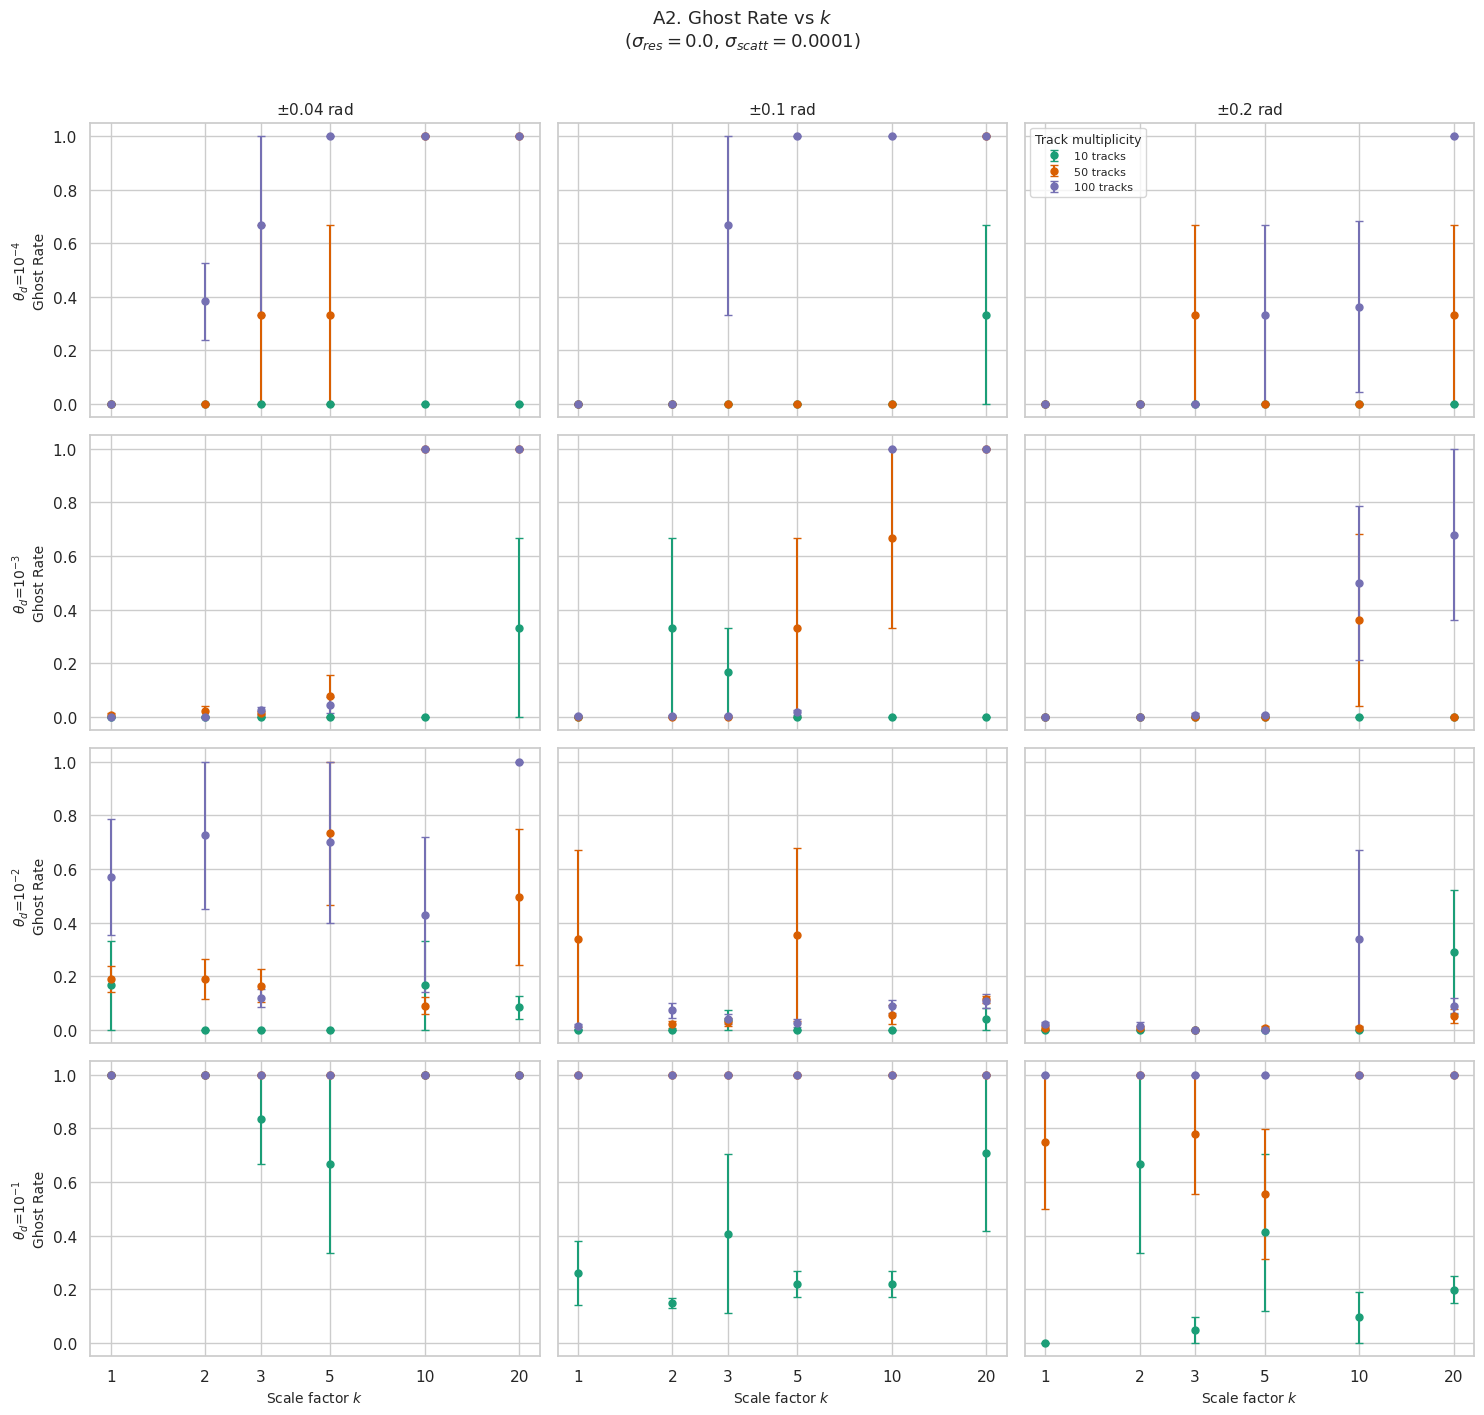

In [51]:
plot_metric_vs_k(df, 'm_ghost_rate_mean', 'm_ghost_rate_se',
                 'A2. Ghost Rate vs $k$', 'Ghost Rate',
                 save_name='A2_ghost_rate_vs_k.png')

### A3. Clone Fraction vs $k$

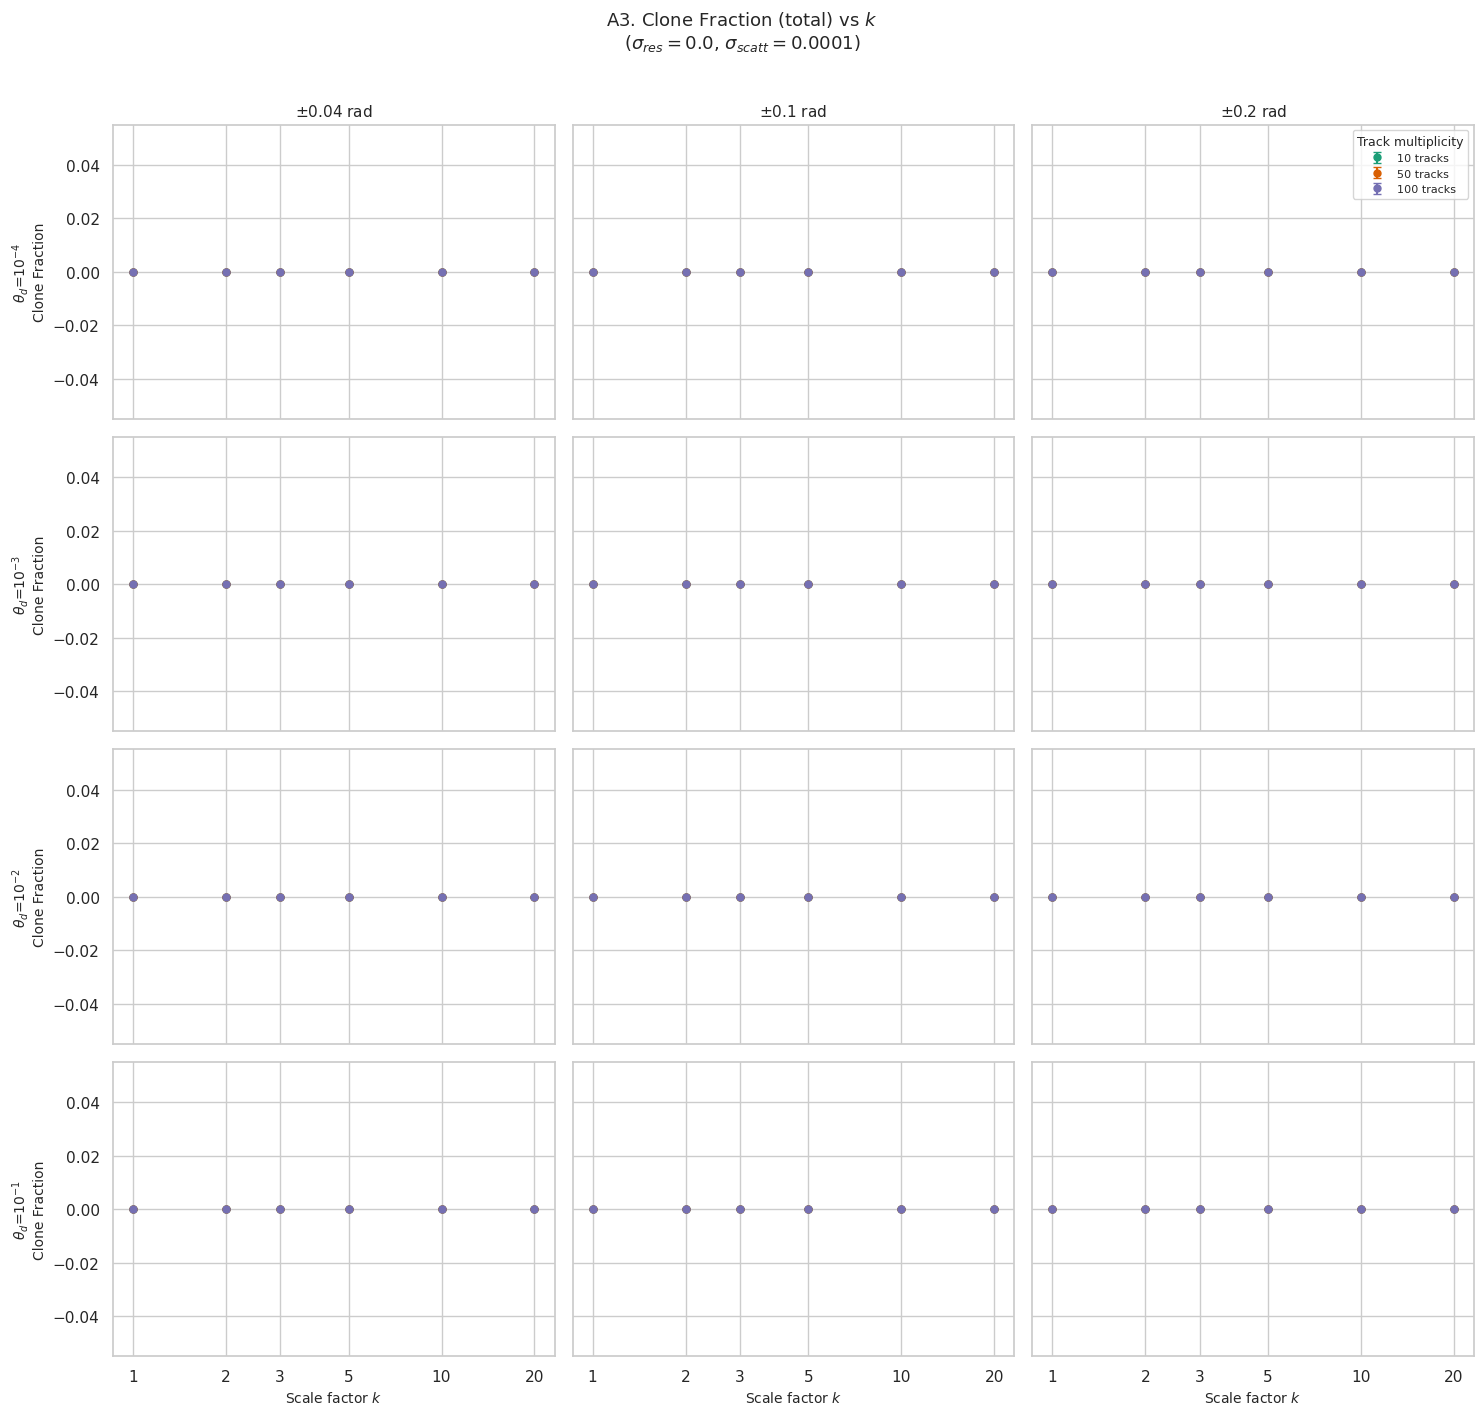

In [52]:
plot_metric_vs_k(df, 'm_clone_fraction_total_mean', 'm_clone_fraction_total_se',
                 'A3. Clone Fraction (total) vs $k$', 'Clone Fraction',
                 save_name='A3_clone_fraction_vs_k.png')

### A — Additional physics conditions

Repeat A1 at each $\sigma_{\text{res}}, \sigma_{\text{scatt}}$ combination to see how the curves shift.

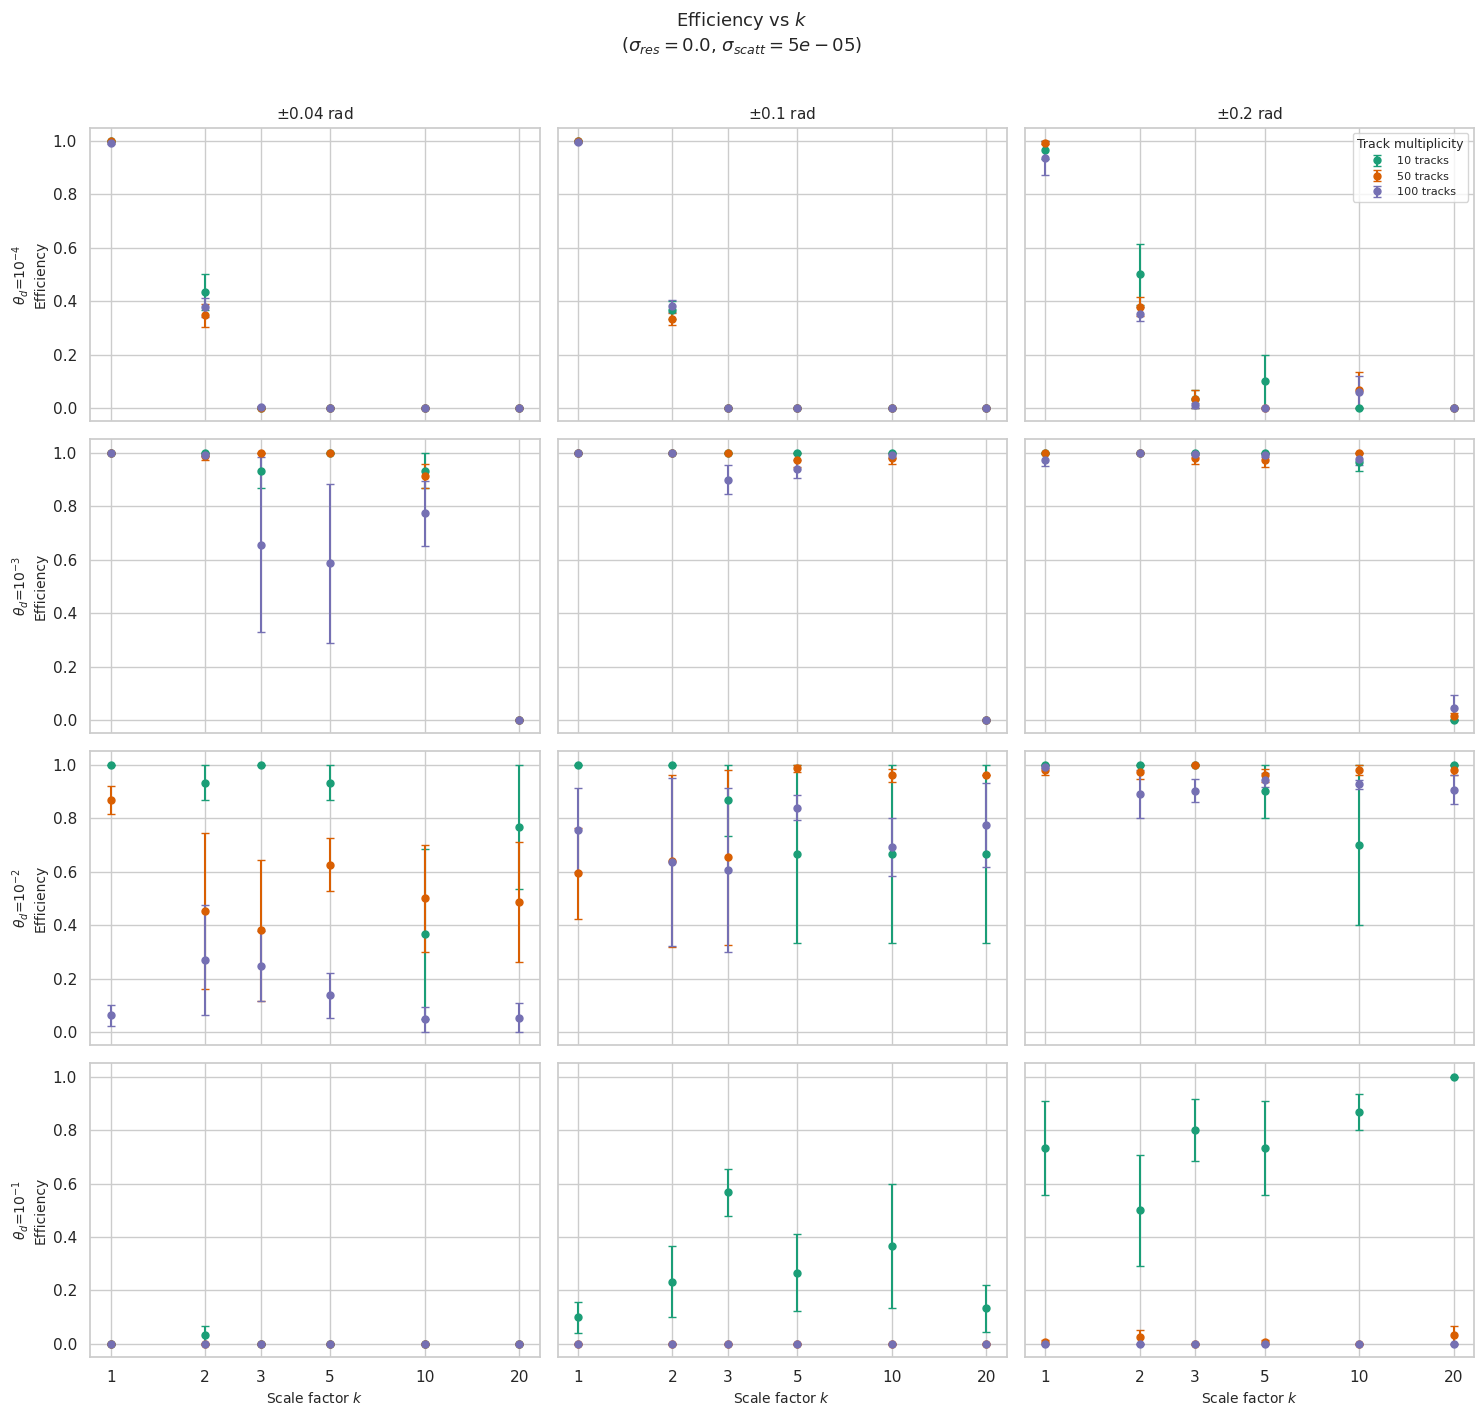

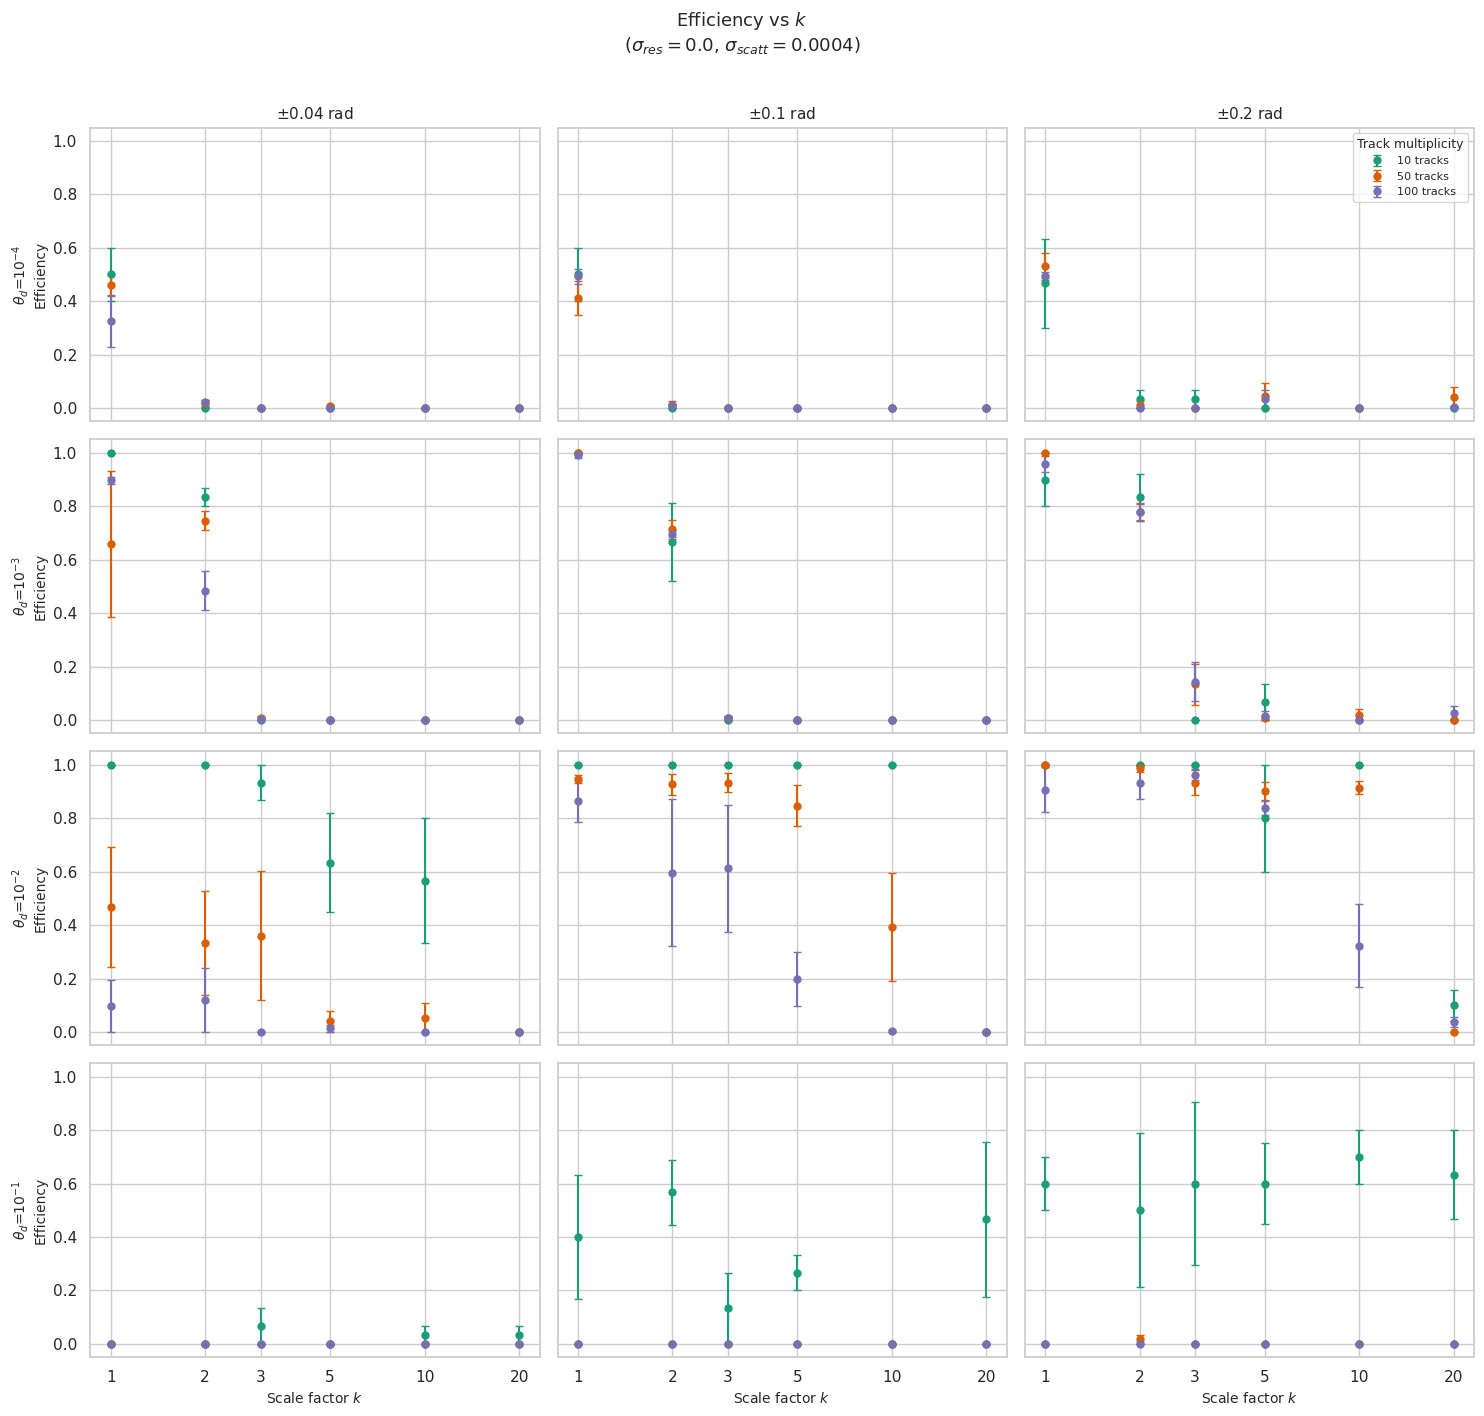

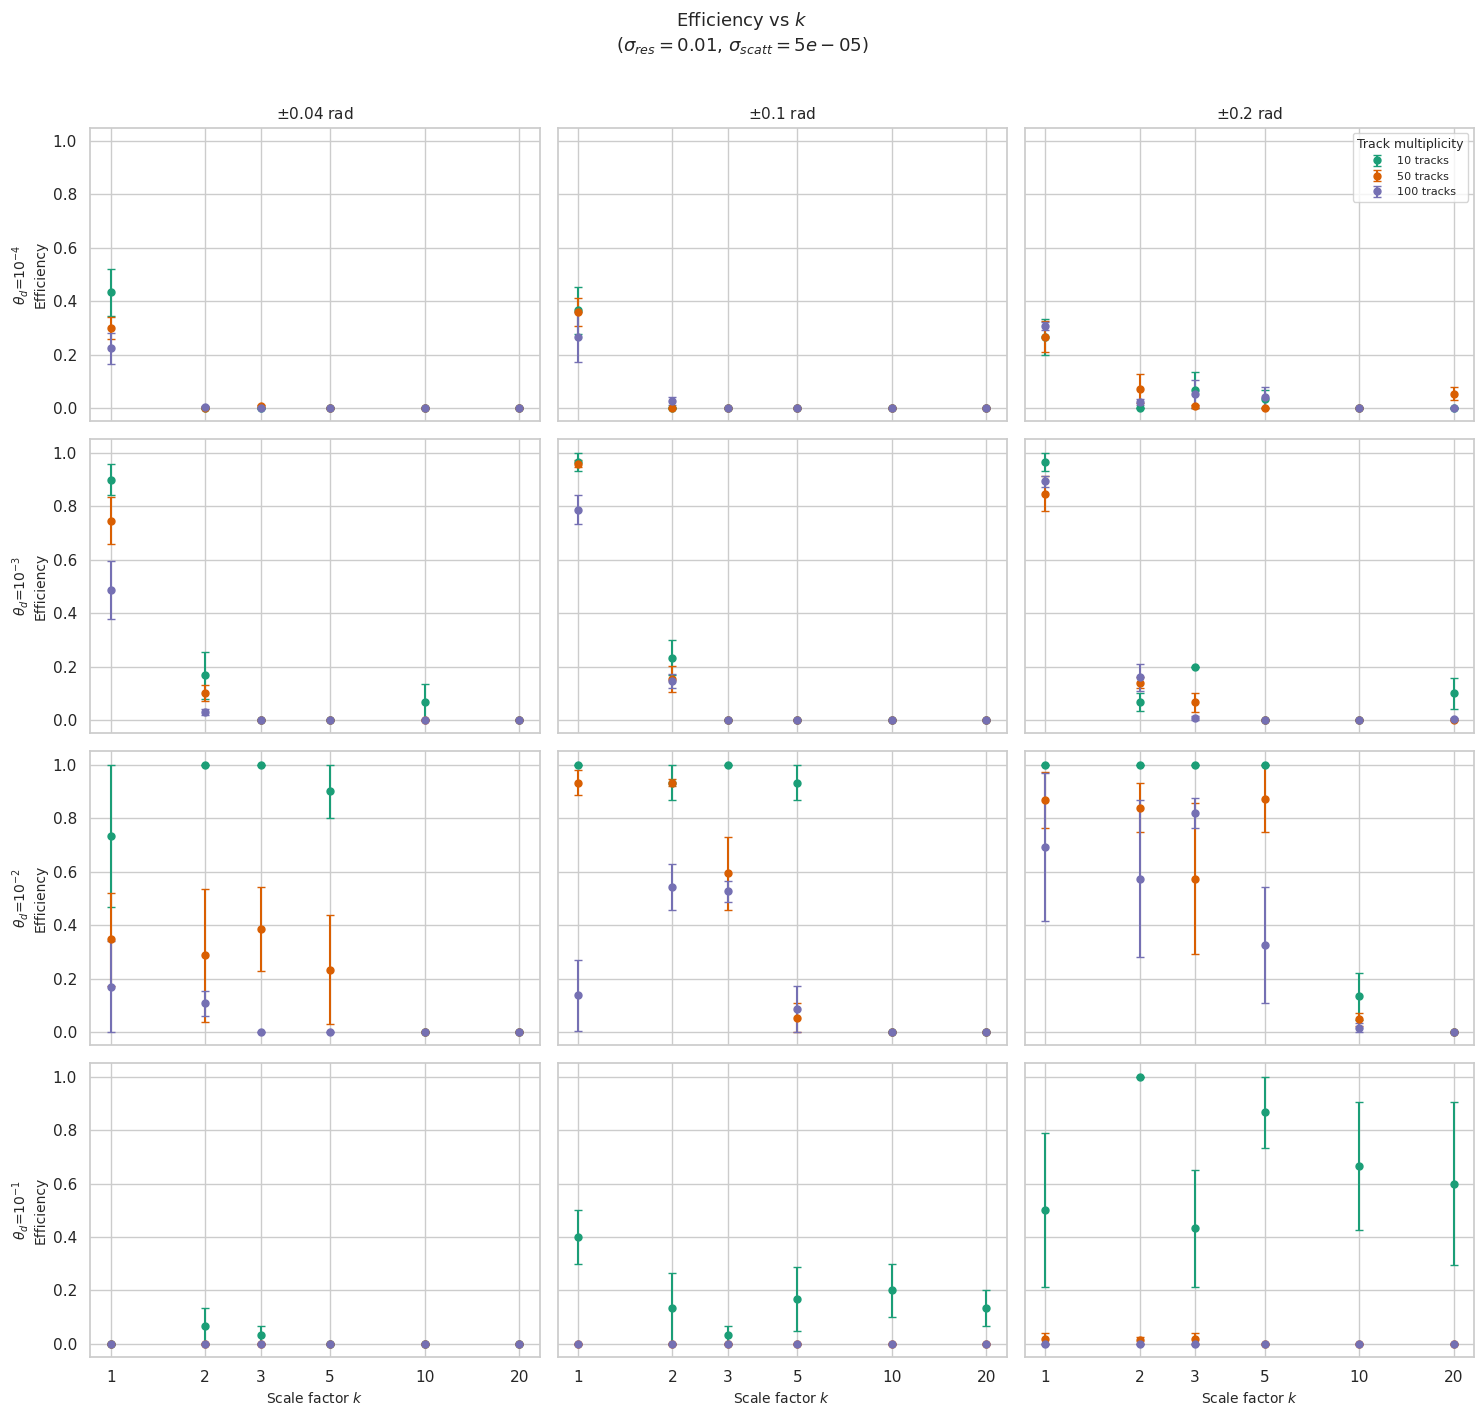

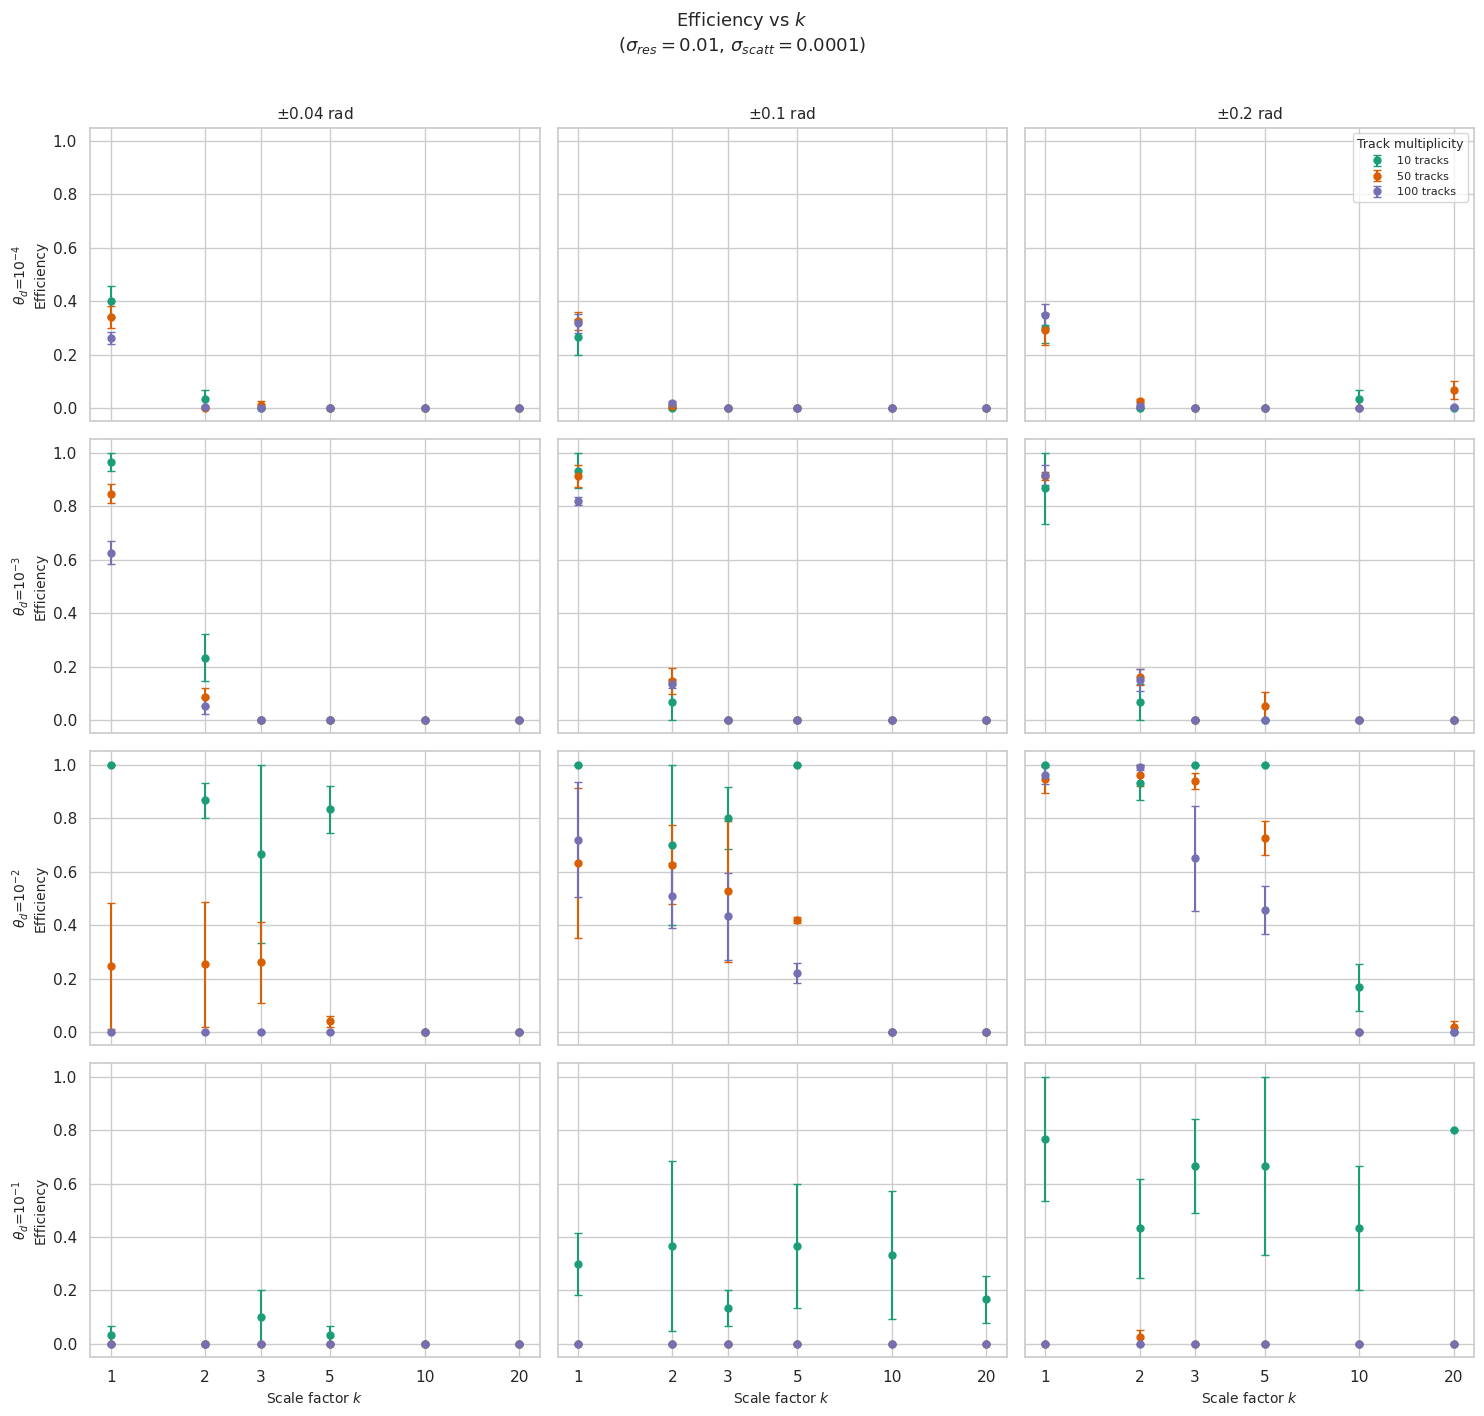

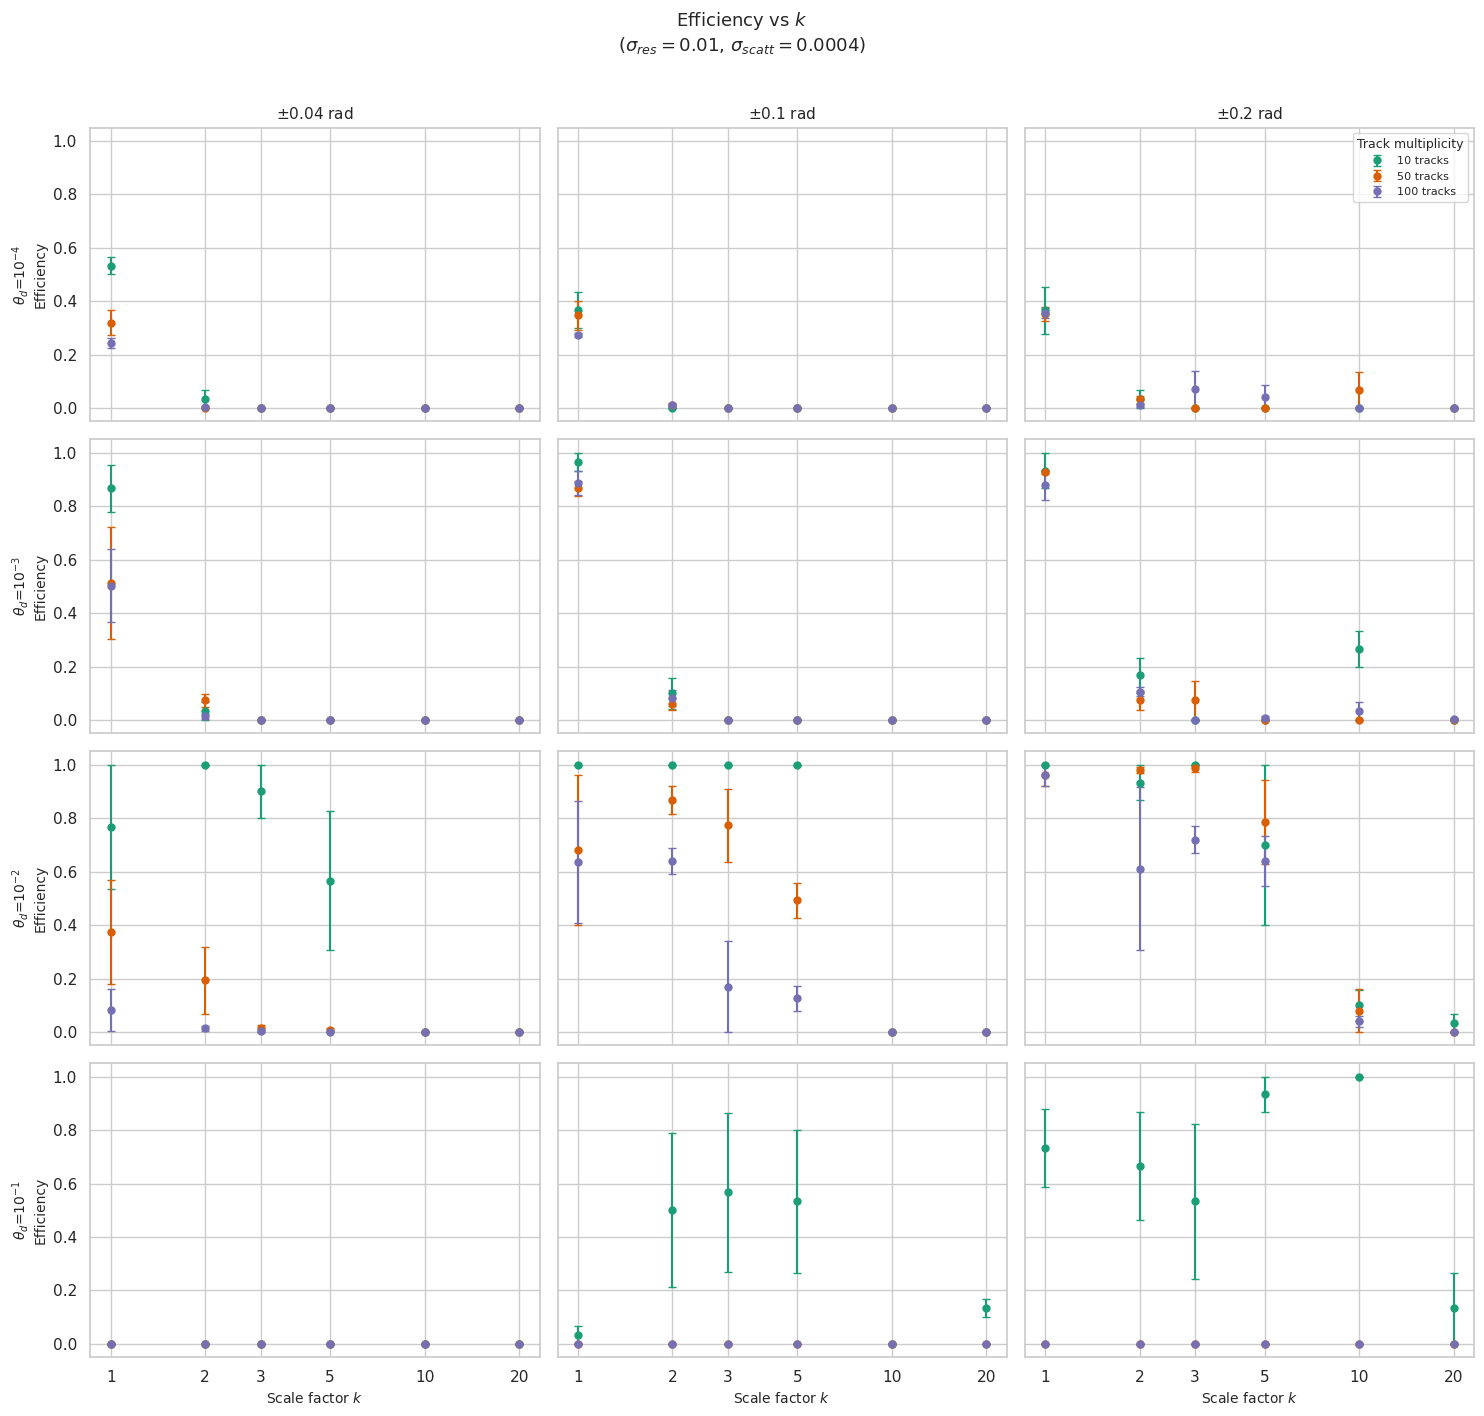

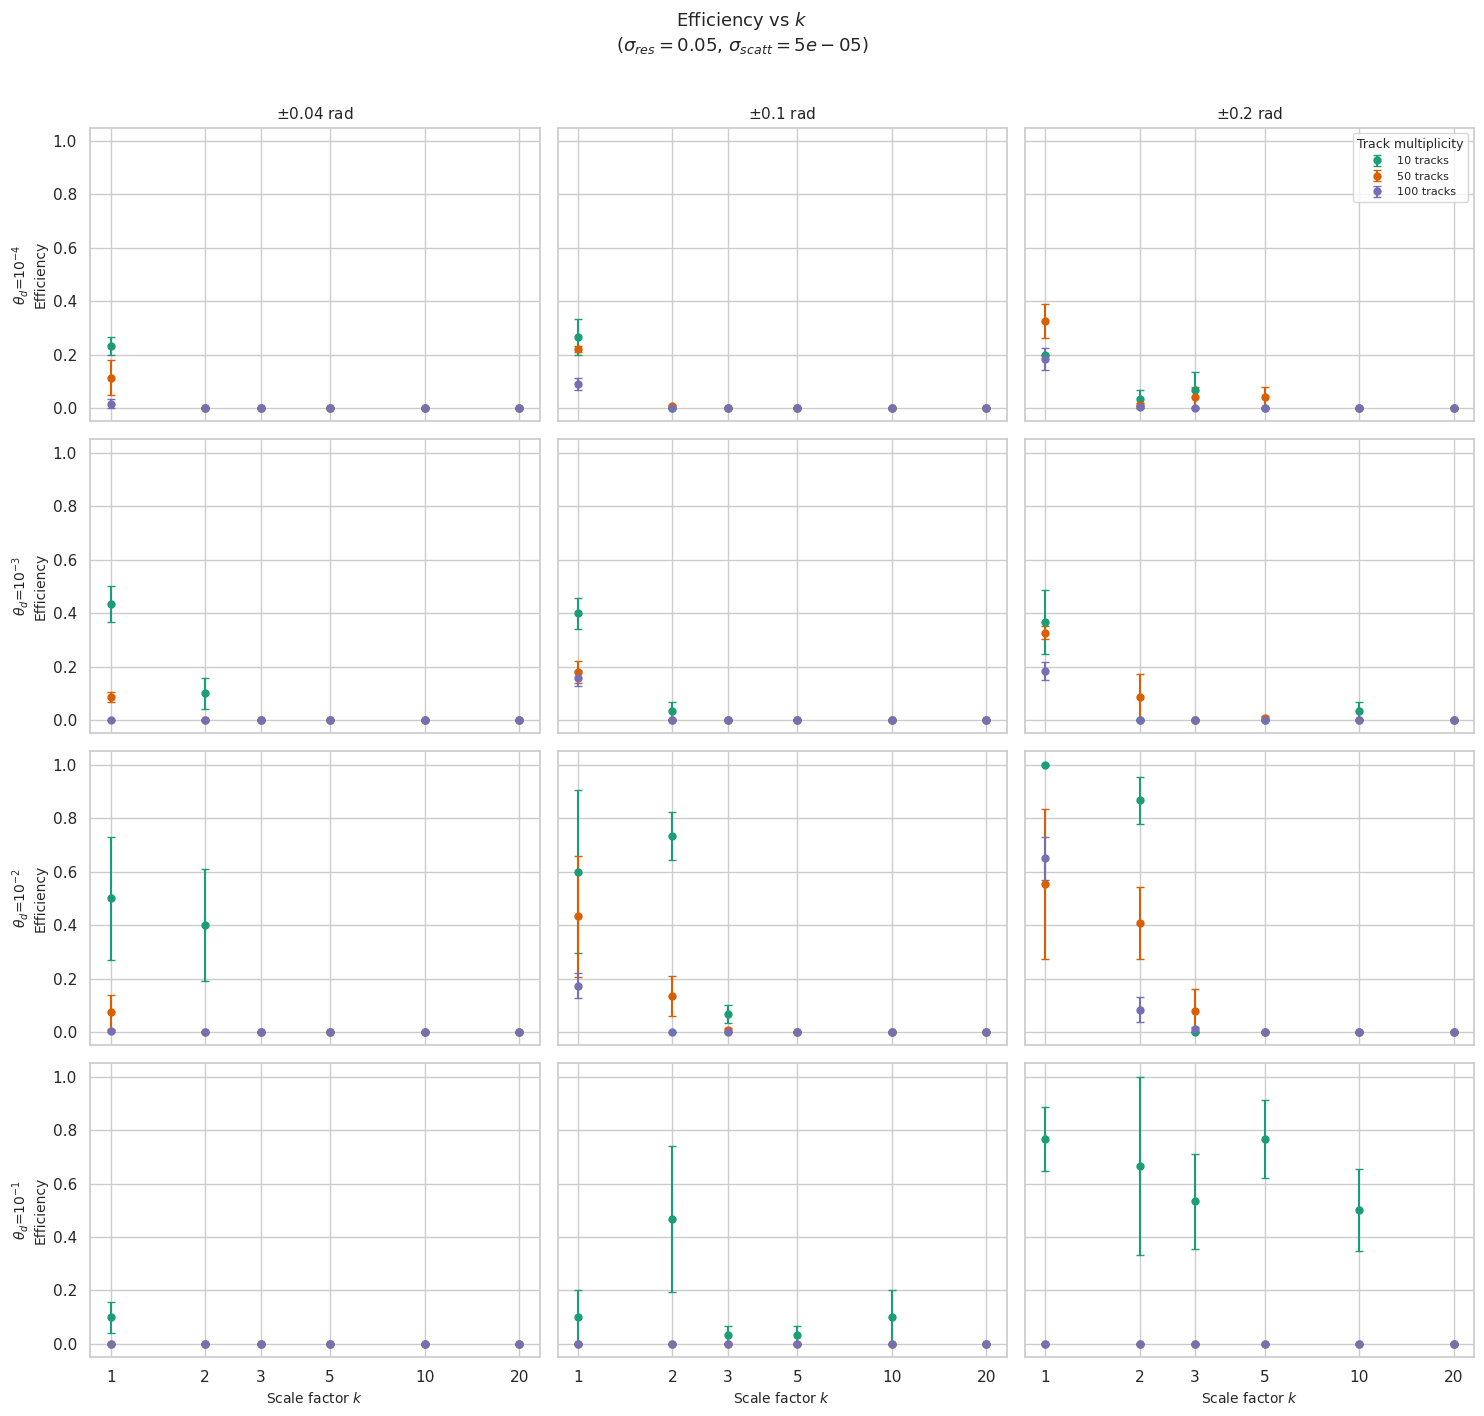

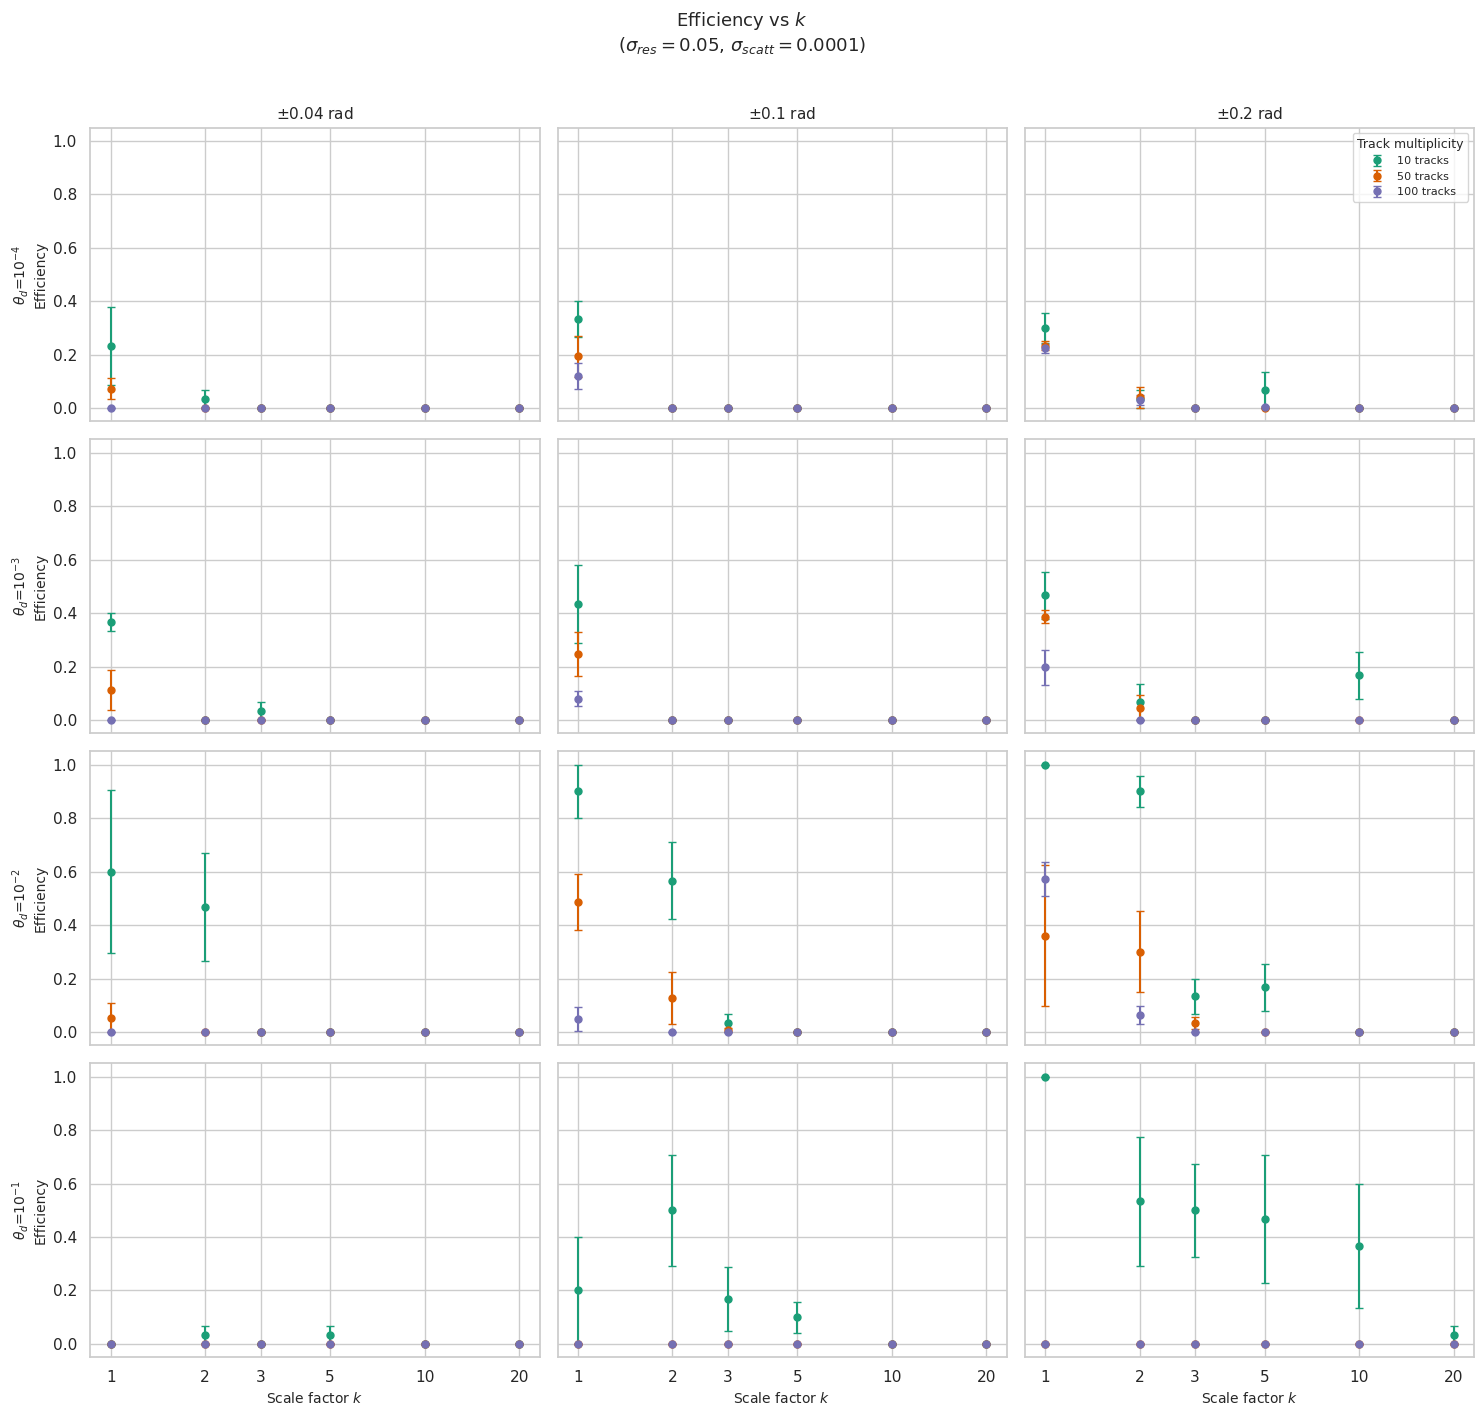

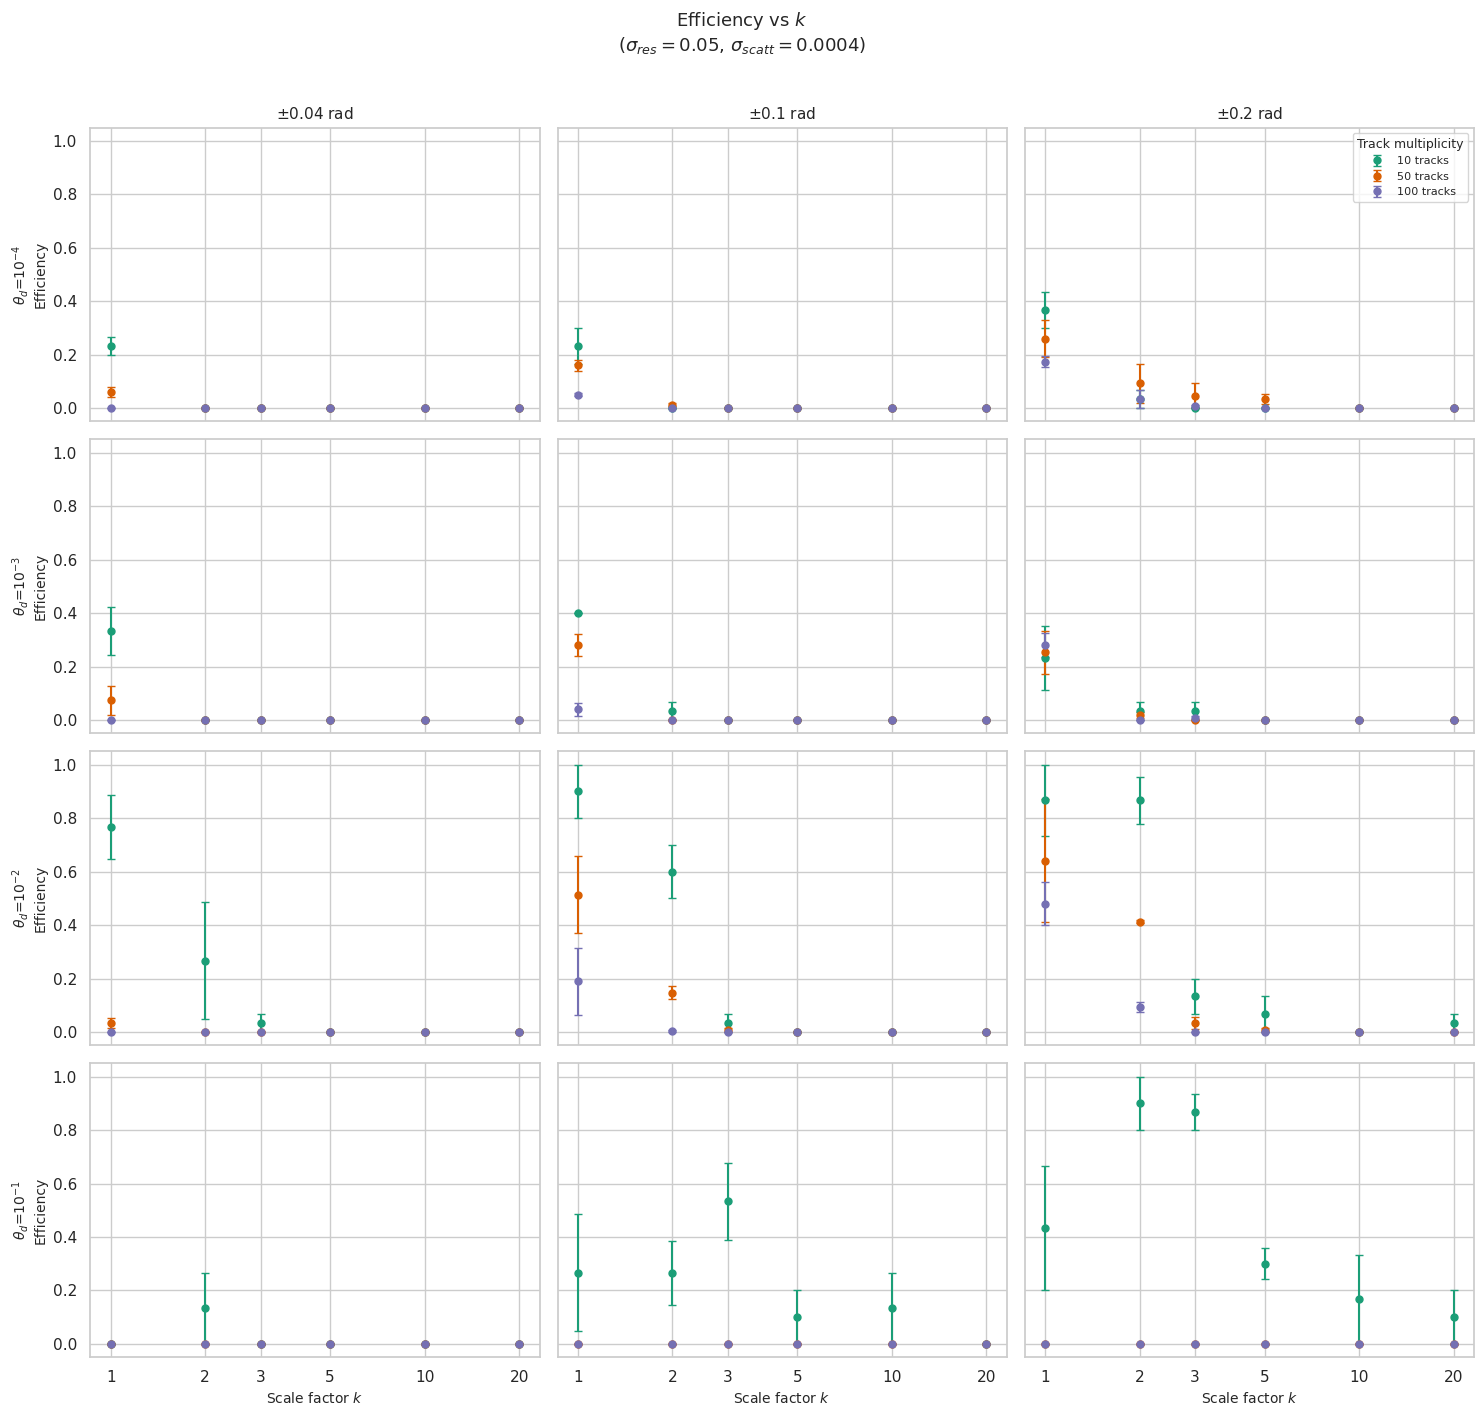

In [53]:
for me in MEAS_ERRS:
    for cn in COLL_NOISES:
        if me == 0.0 and cn == 1e-4:
            continue  # already plotted above
        plot_metric_vs_k(df, 'm_reconstruction_efficiency_mean', 'm_reconstruction_efficiency_se',
                         f'Efficiency vs $k$', 'Efficiency',
                         meas_err=me, coll_noise=cn,
                         save_name=f'A1_eff_me{me}_cn{cn}.png')

---
## B. Hit-Level Quality vs Scale Factor $k$

### B4. Hit Purity vs $k$

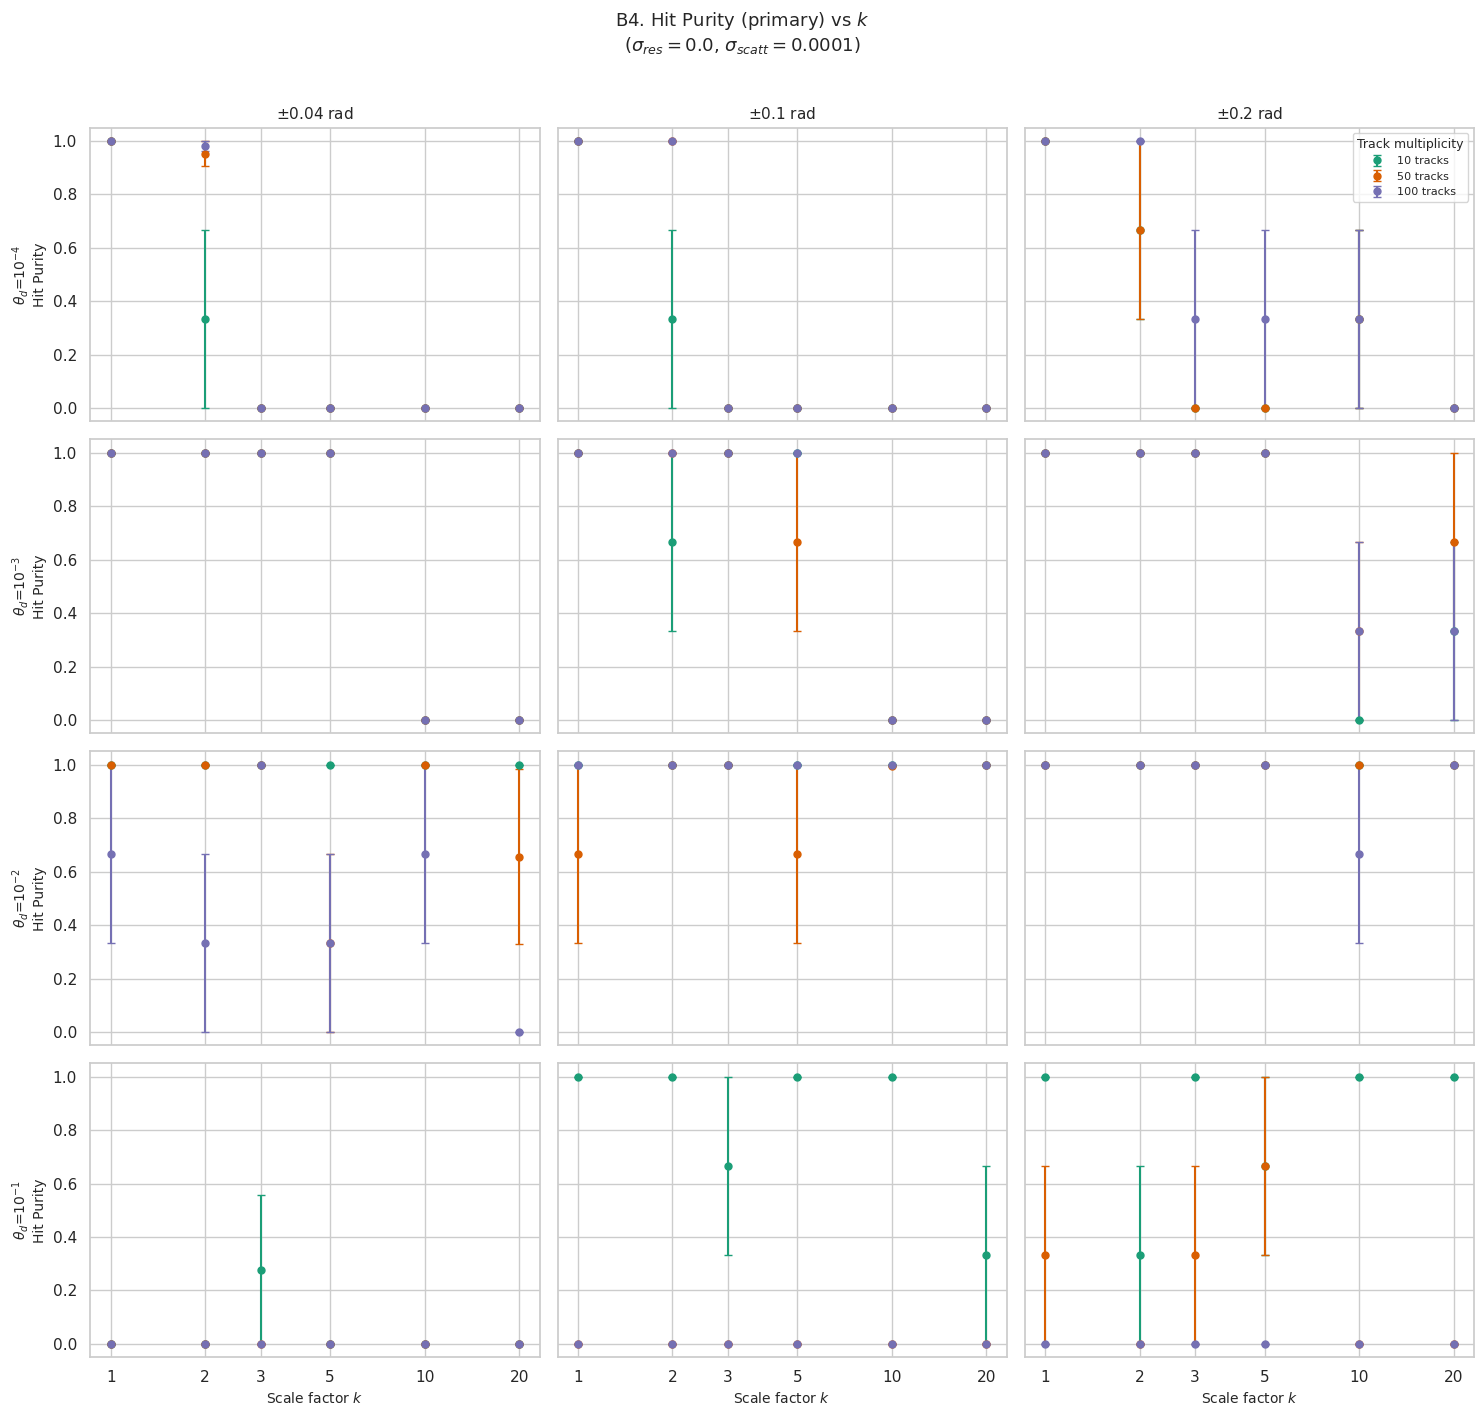

In [54]:
plot_metric_vs_k(df, 'hit_purity_mean_primary_mean', 'hit_purity_mean_primary_se',
                 'B4. Hit Purity (primary) vs $k$', 'Hit Purity',
                 save_name='B4_hit_purity_vs_k.png')

### B5. Hit Efficiency (mean) vs $k$

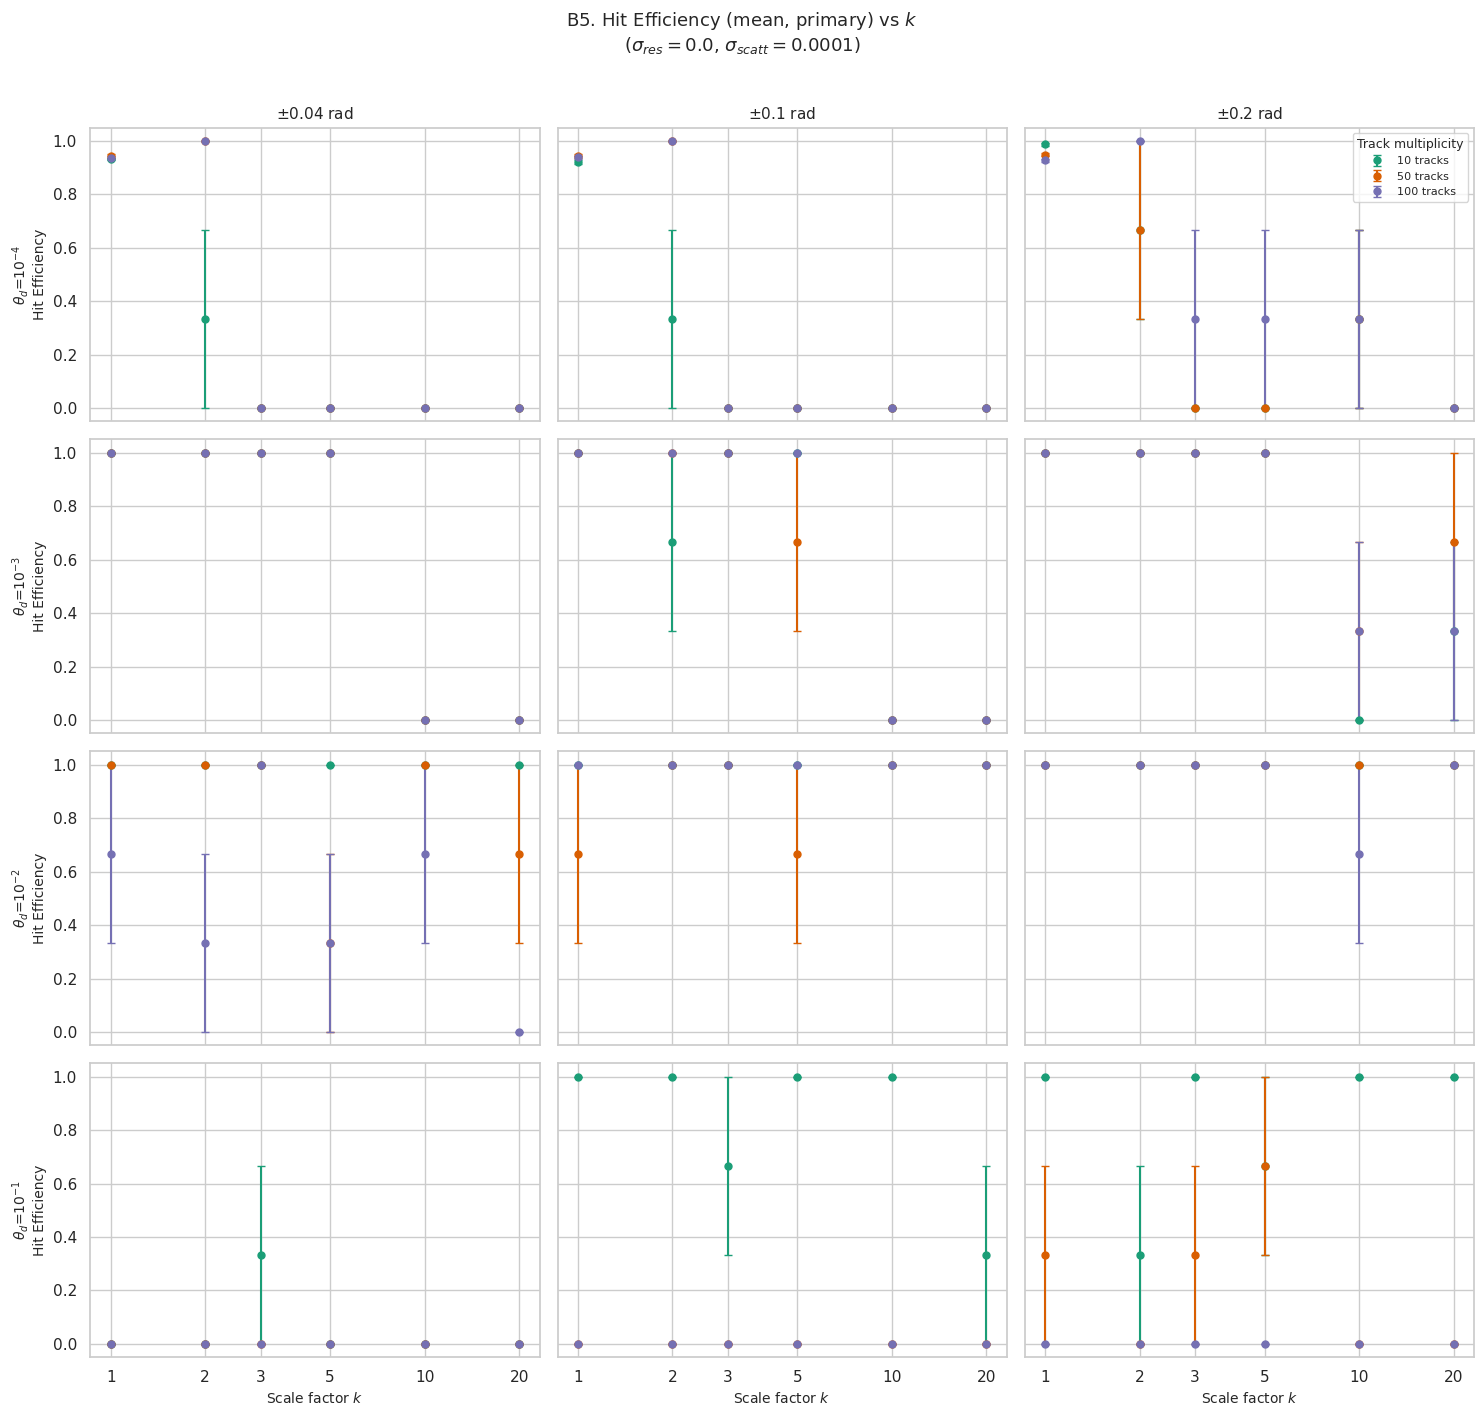

In [55]:
plot_metric_vs_k(df, 'hit_efficiency_mean_primary_mean', 'hit_efficiency_mean_primary_se',
                 'B5. Hit Efficiency (mean, primary) vs $k$', 'Hit Efficiency',
                 save_name='B5_hit_efficiency_vs_k.png')

### B6. Hit Efficiency (weighted) vs $k$

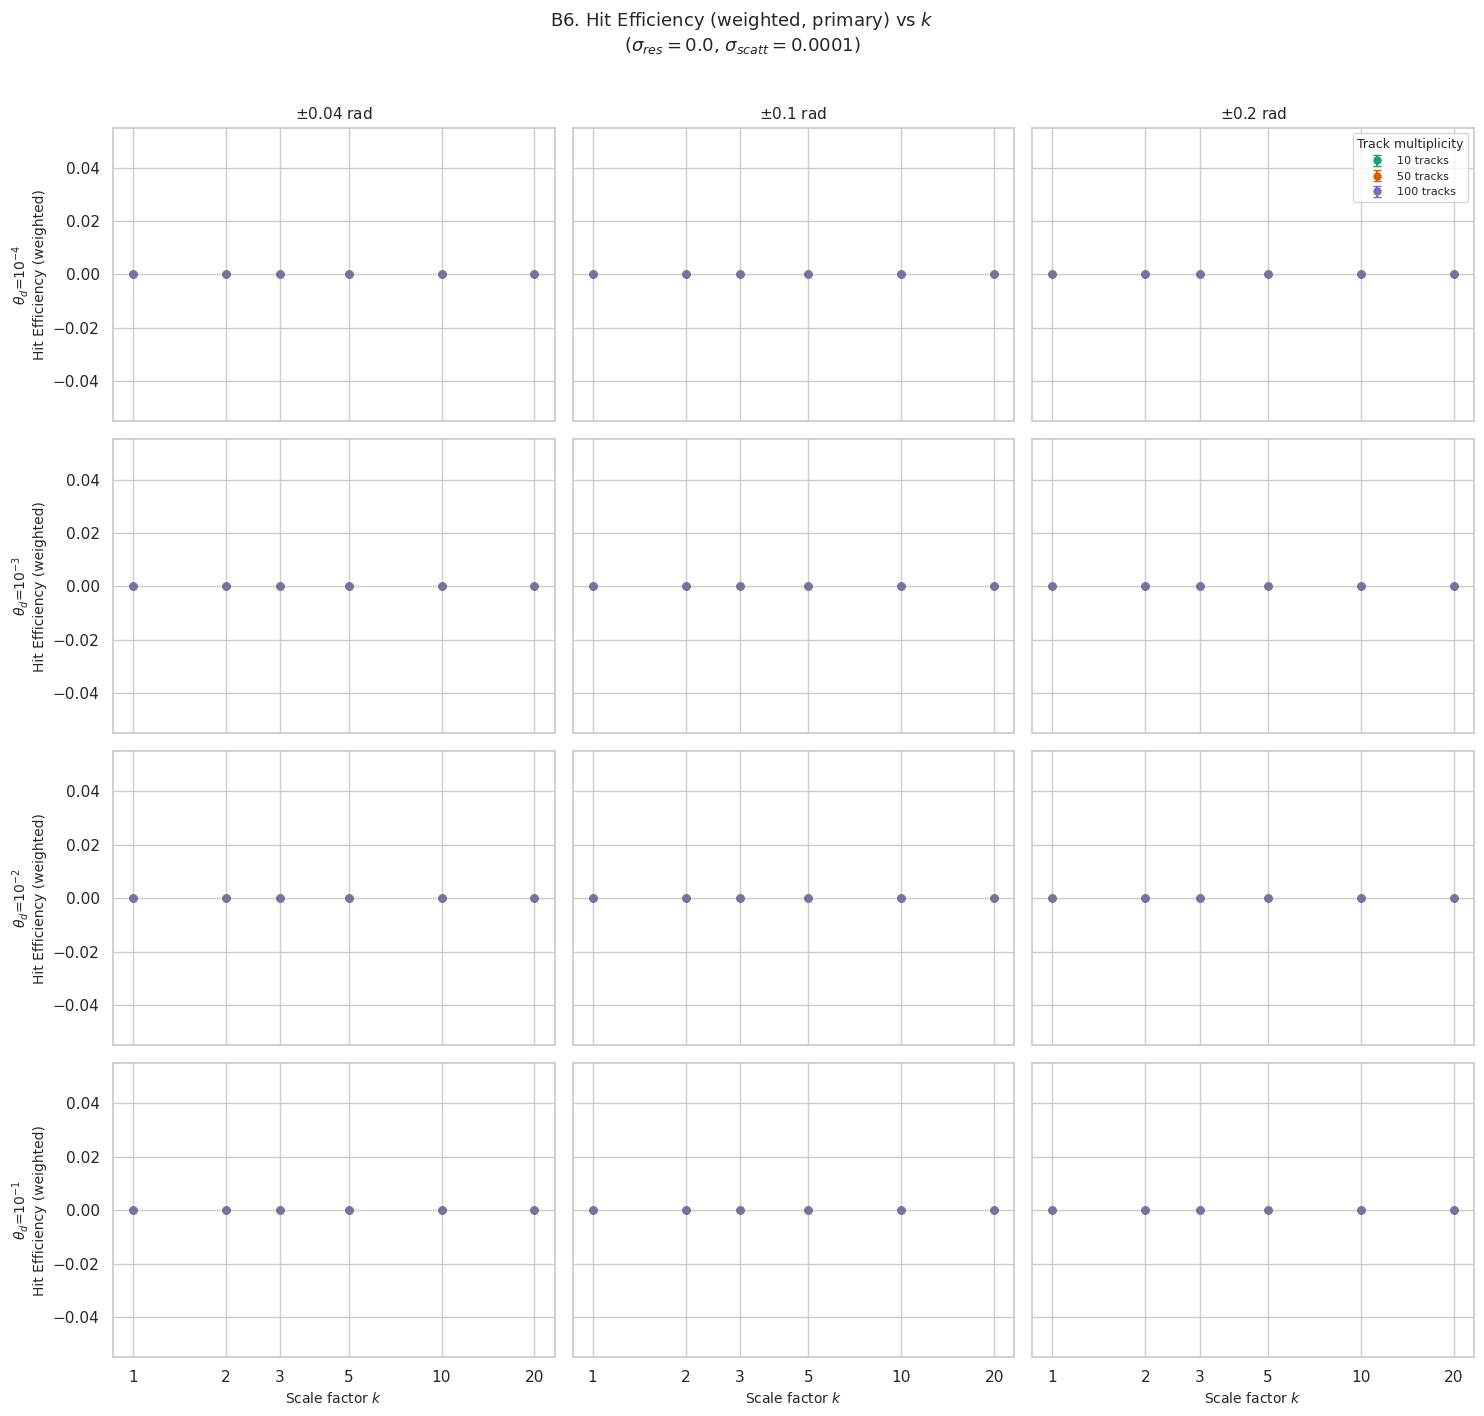

In [56]:
plot_metric_vs_k(df, 'hit_efficiency_weighted_primary_mean', 'hit_efficiency_weighted_primary_se',
                 'B6. Hit Efficiency (weighted, primary) vs $k$', 'Hit Efficiency (weighted)',
                 save_name='B6_hit_efficiency_weighted_vs_k.png')

---
## C. ERF Smoothing Width Analysis

### C7. $\theta_d$ Comparison — Efficiency + Ghost Rate vs $k$

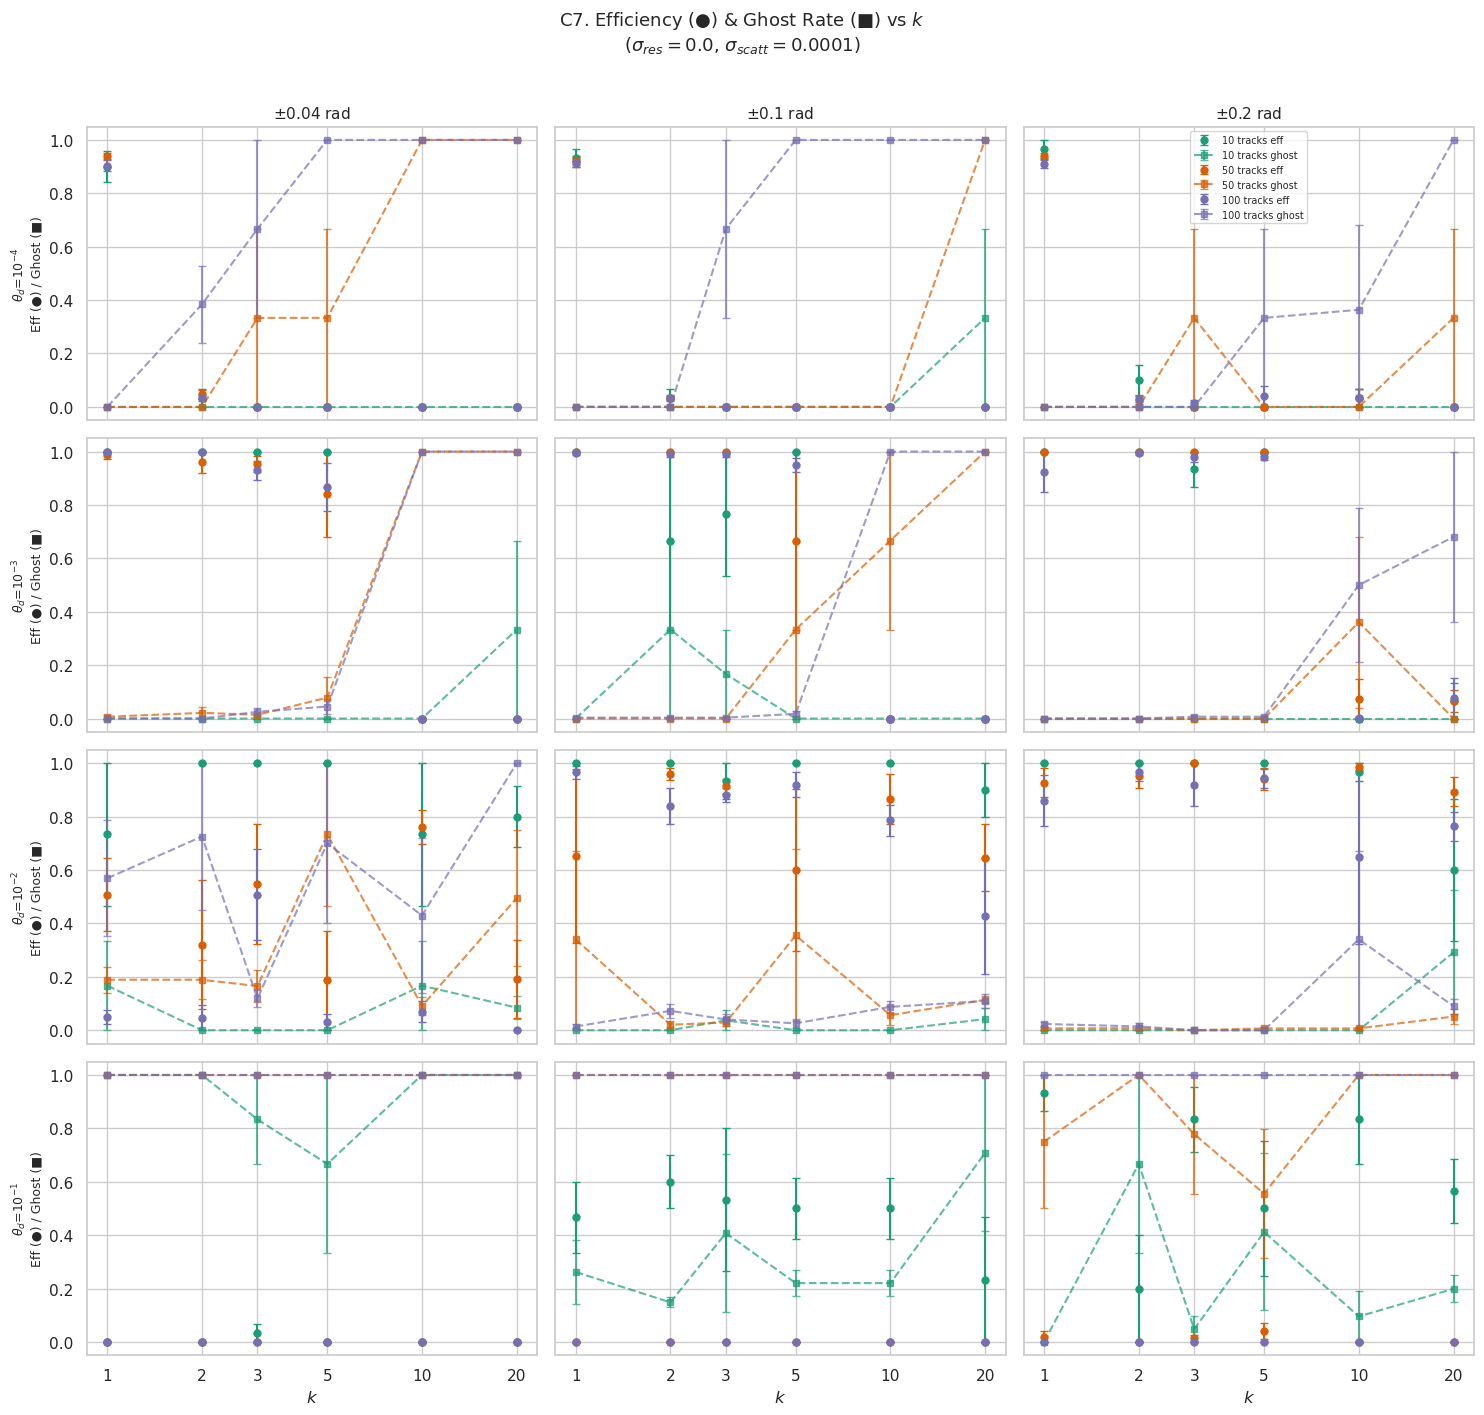

In [57]:
def plot_eff_ghost_dual(df, meas_err=0.0, coll_noise=1e-4, save_name=None):
    """Scatter + error-bar: efficiency (circles) and ghost rate (squares) vs k,
    coloured by track multiplicity, faceted by theta_d (rows) × angle (cols)."""
    sub = df[(df.measurement_error == meas_err) & (df.collision_noise == coll_noise)]

    fig, axes = plt.subplots(len(THETA_DS), len(ANGLES), figsize=(15, 14),
                             sharex=True, sharey=True)
    for i, td in enumerate(THETA_DS):
        for j, ang in enumerate(ANGLES):
            ax = axes[i, j]
            sel = sub[(sub.theta_d == td) & (sub.angle == ang)]
            for nt in TRACKS:
                row = sel[sel.n_tracks == nt].sort_values('scale')
                ax.errorbar(row['scale'], row['m_reconstruction_efficiency_mean'],
                            yerr=row['m_reconstruction_efficiency_se'],
                            fmt='o', ms=5, capsize=3, color=TRACK_COLORS[nt],
                            label=f'{TRACK_LABELS[nt]} eff' if (i == 0 and j == len(ANGLES) - 1) else None)
                ax.errorbar(row['scale'], row['m_ghost_rate_mean'],
                            yerr=row['m_ghost_rate_se'],
                            fmt='s', ms=4, capsize=3, color=TRACK_COLORS[nt], alpha=0.7,
                            linestyle='--',
                            label=f'{TRACK_LABELS[nt]} ghost' if (i == 0 and j == len(ANGLES) - 1) else None)
            ax.set_ylim(-0.05, 1.05)
            if i == 0:
                ax.set_title(ANGLE_LABELS[ang], fontsize=11)
            if j == 0:
                ax.set_ylabel(f'$\\theta_d$={TD_LABELS[td]}\nEff (●) / Ghost (■)', fontsize=9)
            if i == len(THETA_DS) - 1:
                ax.set_xlabel('$k$')
            ax.set_xscale('log')
            ax.set_xticks(SCALES)
            ax.set_xticklabels(SCALES)

    axes[0, -1].legend(fontsize=7, ncol=1)
    fig.suptitle(f'C7. Efficiency (●) & Ghost Rate (■) vs $k$\n'
                 f'($\\sigma_{{res}}={meas_err}$, $\\sigma_{{scatt}}={coll_noise}$)',
                 fontsize=13, y=1.01)
    fig.tight_layout()
    if save_name:
        fig.savefig(PLOT_DIR / save_name, bbox_inches='tight', dpi=150)
    plt.show()

plot_eff_ghost_dual(df, save_name='C7_eff_ghost_vs_k.png')

### C8. Heatmaps — Score vs $(k, \theta_d)$

/tmp/ipykernel_3014358/1632402914.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


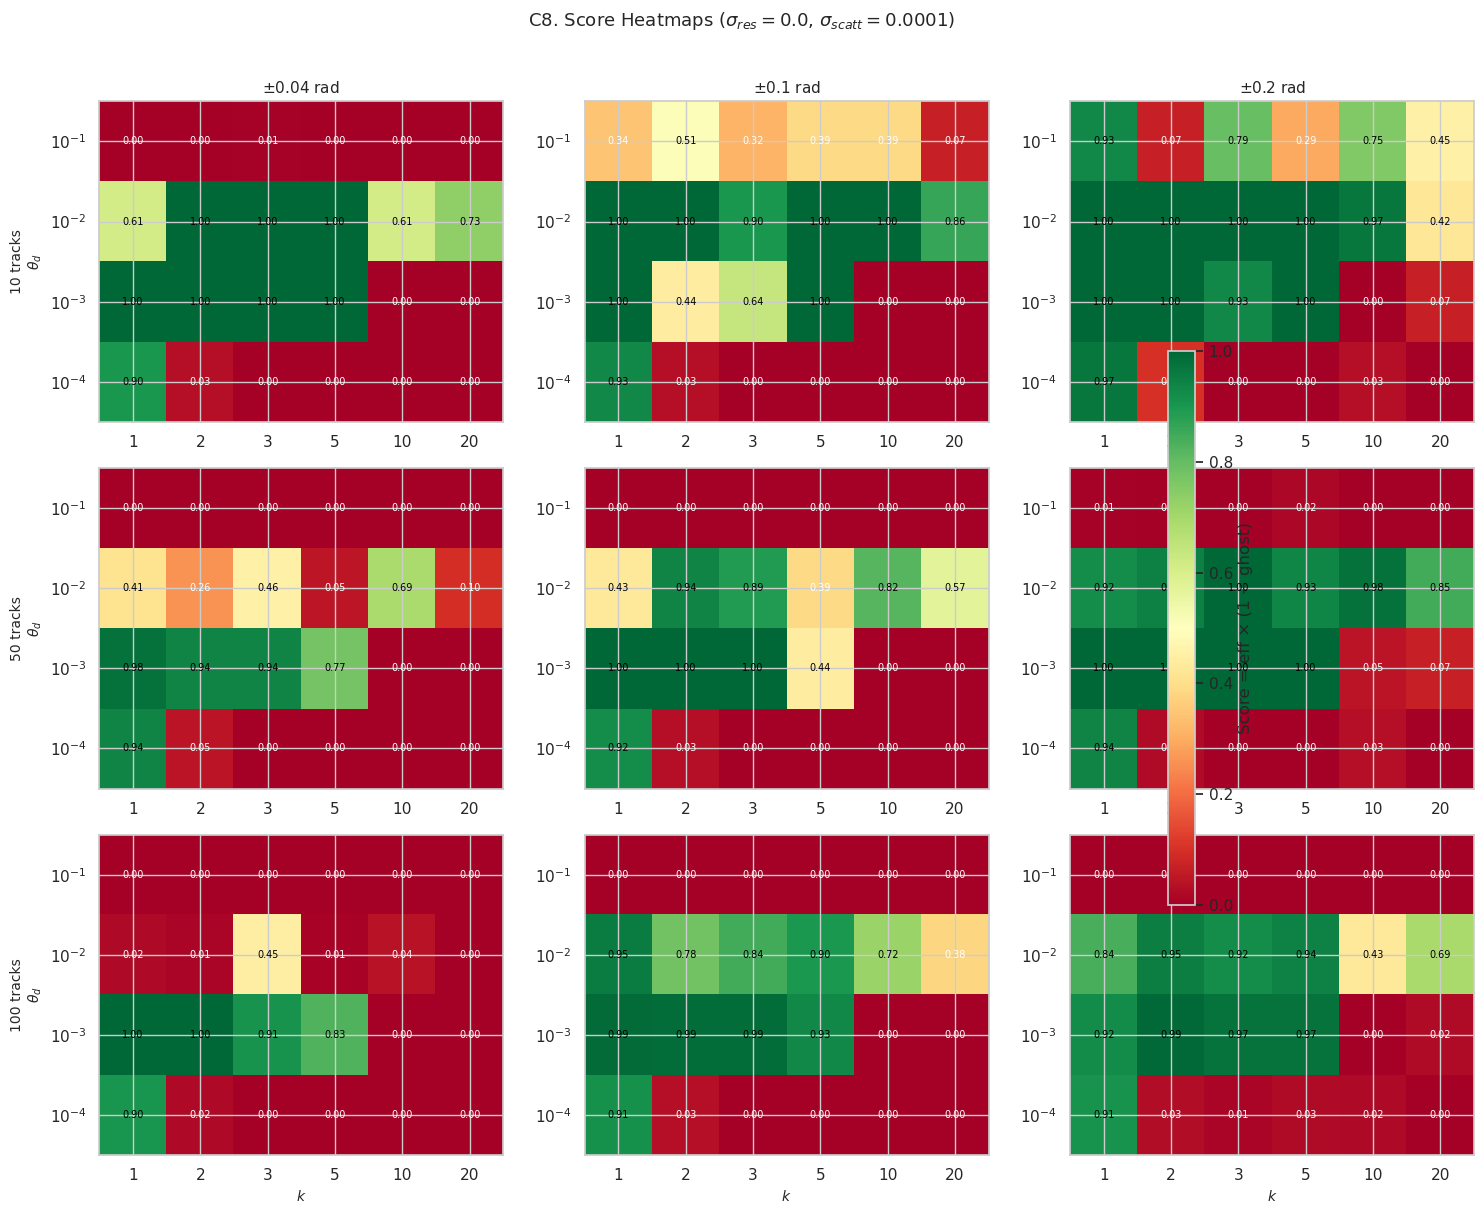

In [58]:
def plot_score_heatmaps(df, meas_err=0.0, coll_noise=1e-4, save_name=None):
    """2D heatmaps: Score vs (k, theta_d) faceted by angle × n_tracks."""
    sub = df[(df.measurement_error == meas_err) & (df.collision_noise == coll_noise)]
    
    fig, axes = plt.subplots(len(TRACKS), len(ANGLES), figsize=(15, 12))
    
    for i, nt in enumerate(TRACKS):
        for j, ang in enumerate(ANGLES):
            ax = axes[i, j]
            sel = sub[(sub.n_tracks == nt) & (sub.angle == ang)]
            pivot = sel.pivot_table(index='theta_d', columns='scale', values='score')
            pivot = pivot.sort_index(ascending=False)
            
            im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn',
                           vmin=0, vmax=1)
            ax.set_xticks(range(len(SCALES)))
            ax.set_xticklabels(SCALES)
            ax.set_yticks(range(len(THETA_DS)))
            ax.set_yticklabels([TD_LABELS[td] for td in sorted(THETA_DS, reverse=True)])
            
            # Annotate cells
            for ii in range(pivot.shape[0]):
                for jj in range(pivot.shape[1]):
                    val = pivot.values[ii, jj]
                    ax.text(jj, ii, f'{val:.2f}', ha='center', va='center',
                            fontsize=7, color='black' if val > 0.4 else 'white')
            
            if i == 0:
                ax.set_title(ANGLE_LABELS[ang], fontsize=11)
            if j == 0:
                ax.set_ylabel(f'{TRACK_LABELS[nt]}\n$\\theta_d$', fontsize=10)
            if i == len(TRACKS) - 1:
                ax.set_xlabel('$k$', fontsize=10)
    
    fig.colorbar(im, ax=axes, label='Score = eff × (1 − ghost)', shrink=0.6)
    fig.suptitle(f'C8. Score Heatmaps ($\\sigma_{{res}}={meas_err}$, $\\sigma_{{scatt}}={coll_noise}$)',
                 fontsize=13, y=1.01)
    fig.tight_layout()
    if save_name:
        fig.savefig(PLOT_DIR / save_name, bbox_inches='tight', dpi=150)
    plt.show()

plot_score_heatmaps(df, save_name='C8_score_heatmaps_default.png')

/tmp/ipykernel_3014358/1632402914.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


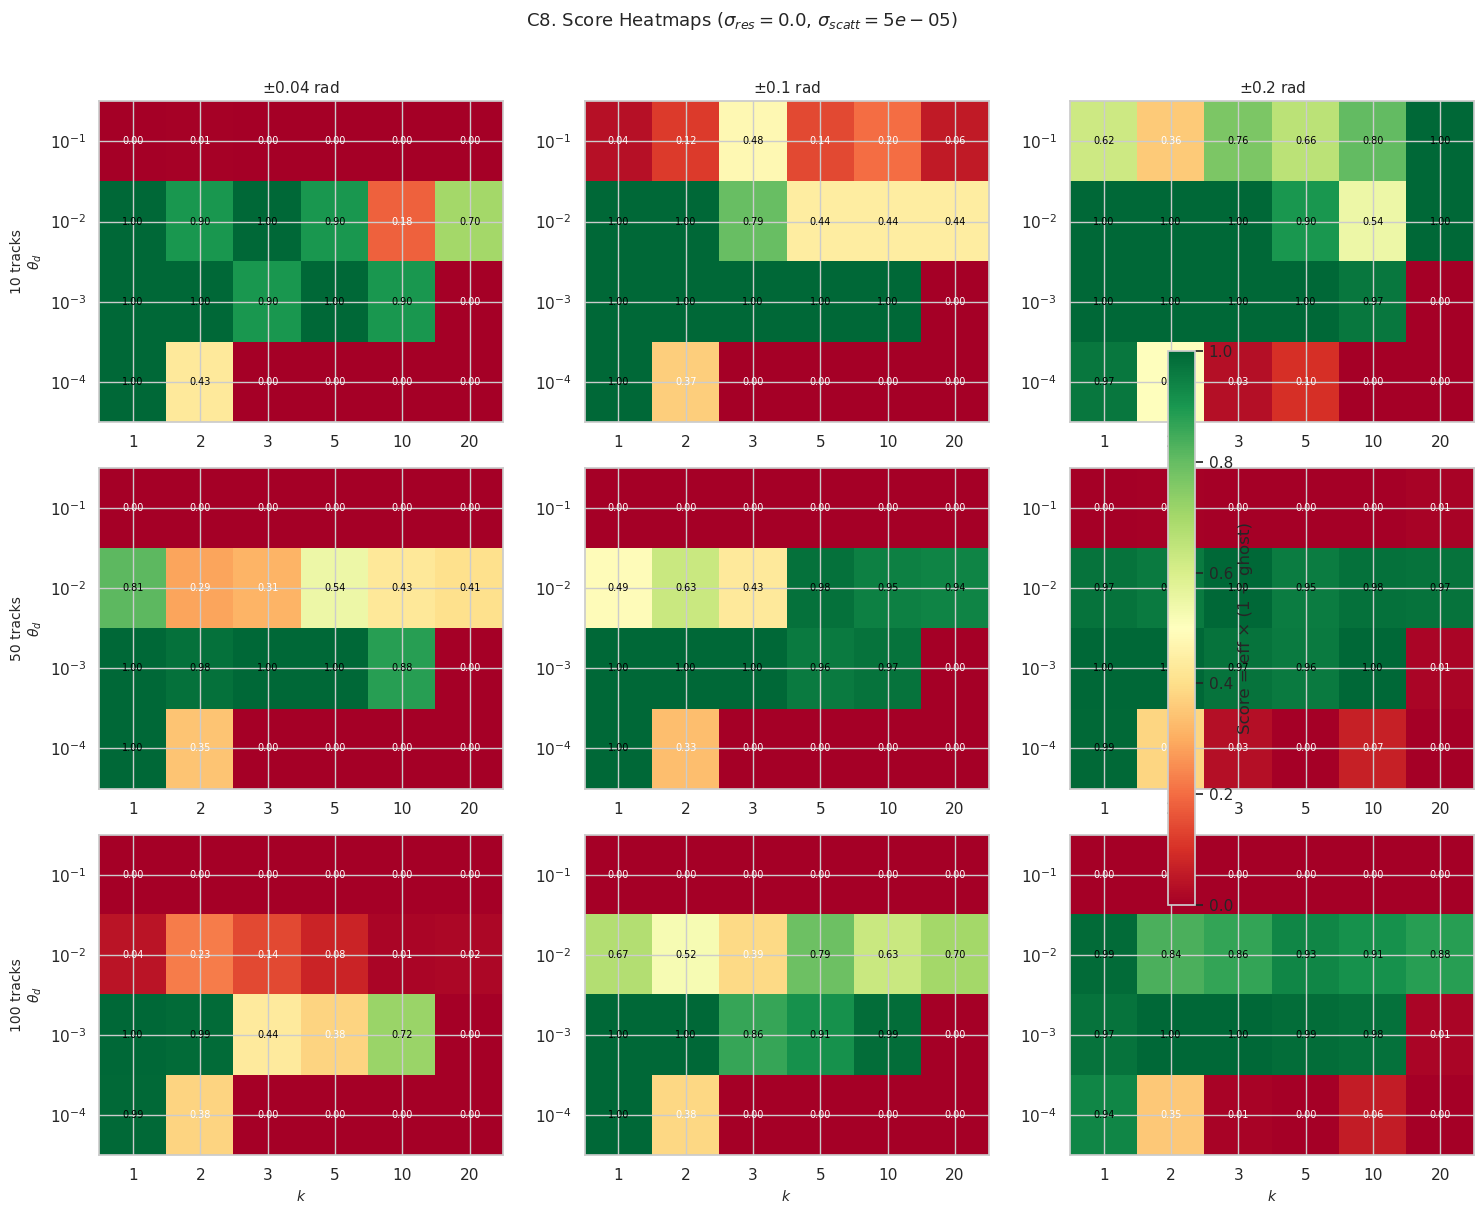

/tmp/ipykernel_3014358/1632402914.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


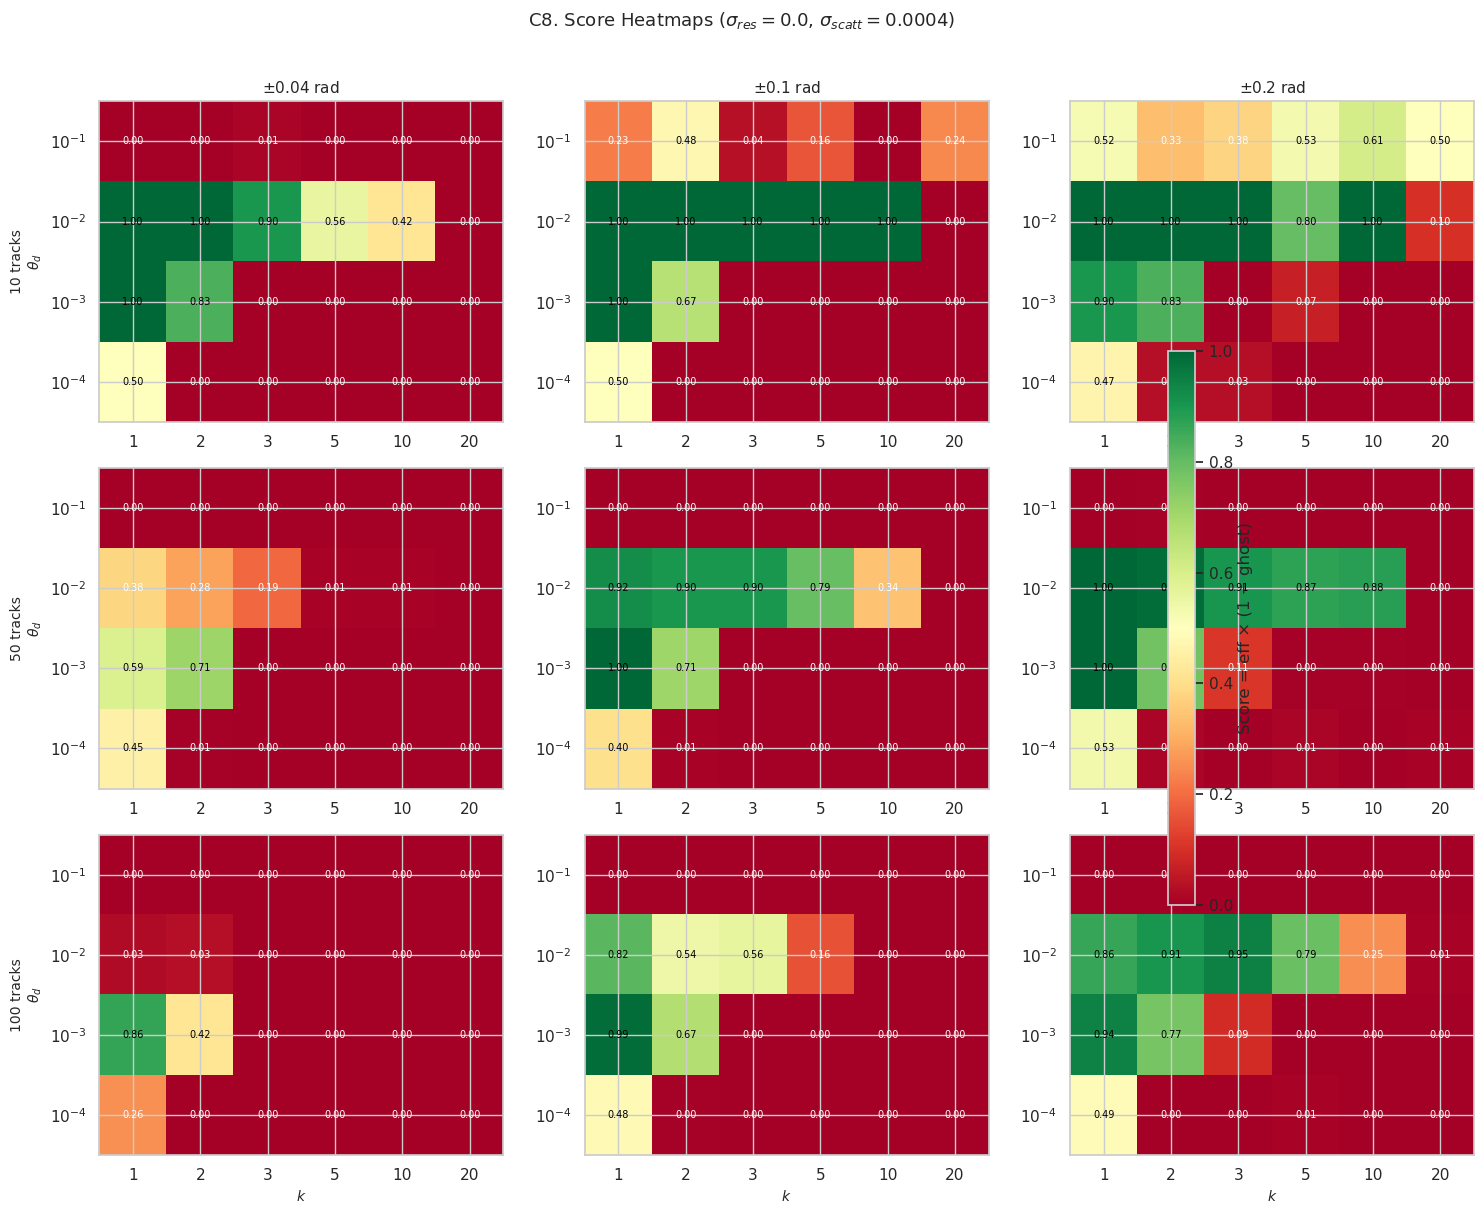

/tmp/ipykernel_3014358/1632402914.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


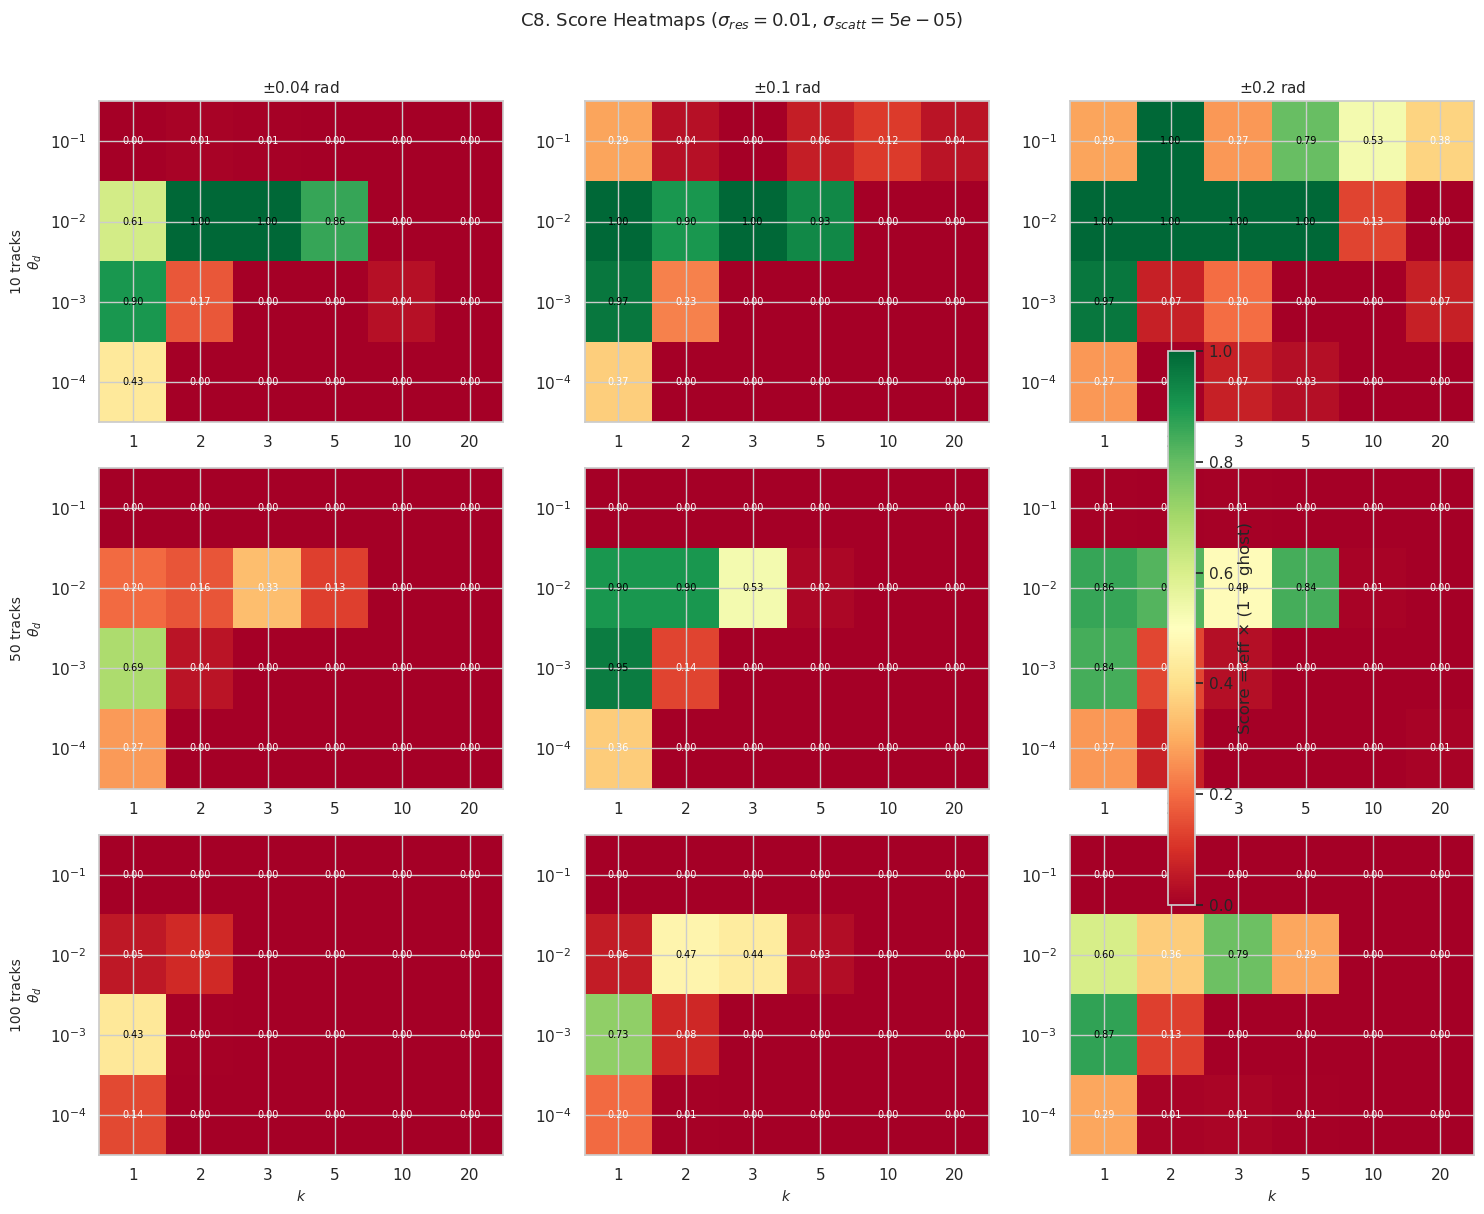

/tmp/ipykernel_3014358/1632402914.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


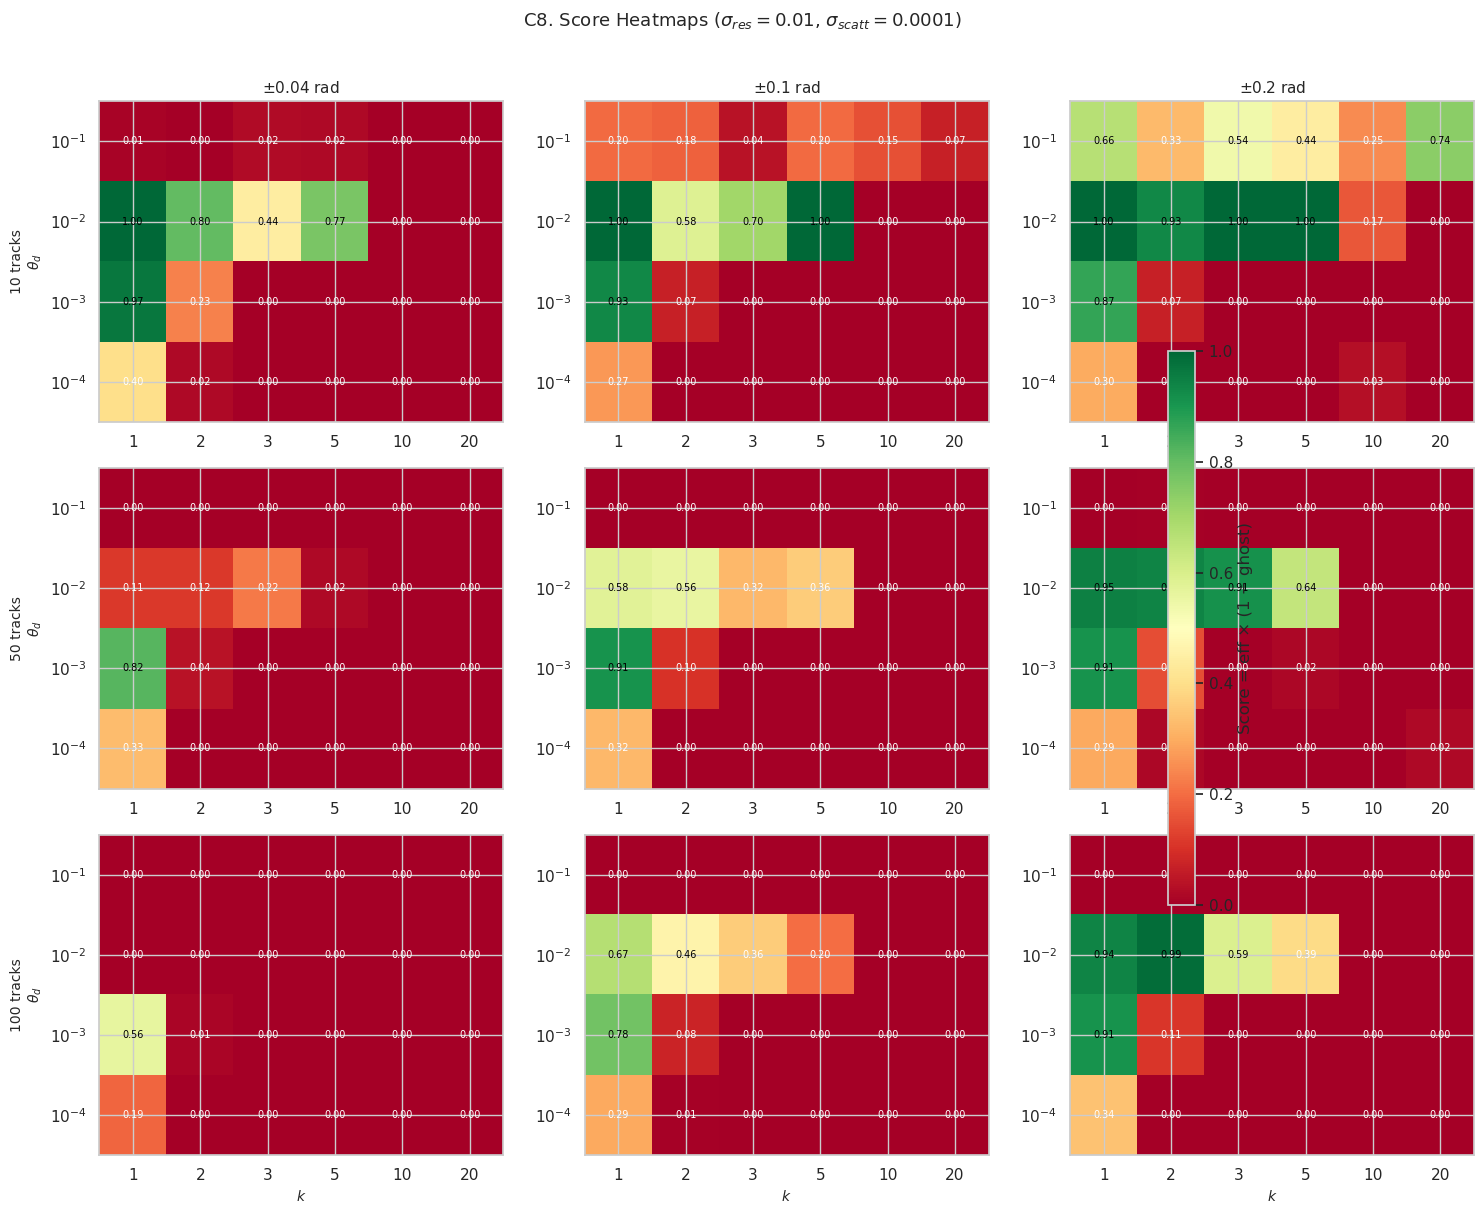

/tmp/ipykernel_3014358/1632402914.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


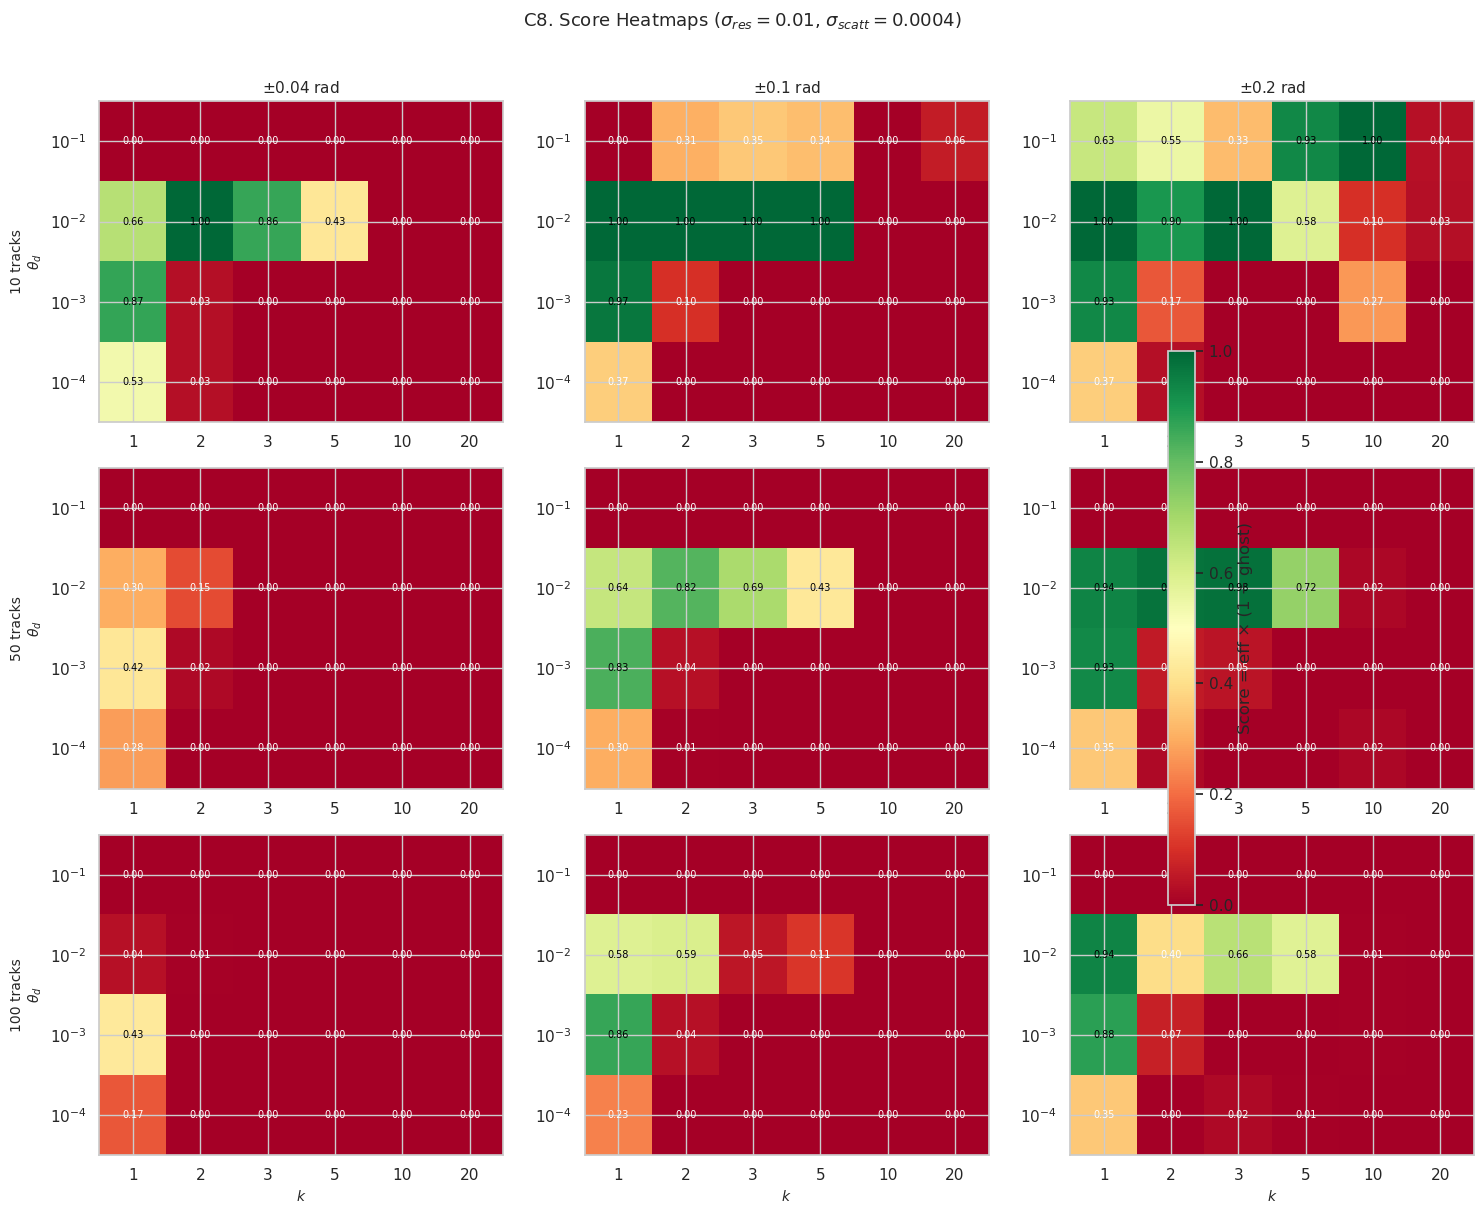

/tmp/ipykernel_3014358/1632402914.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


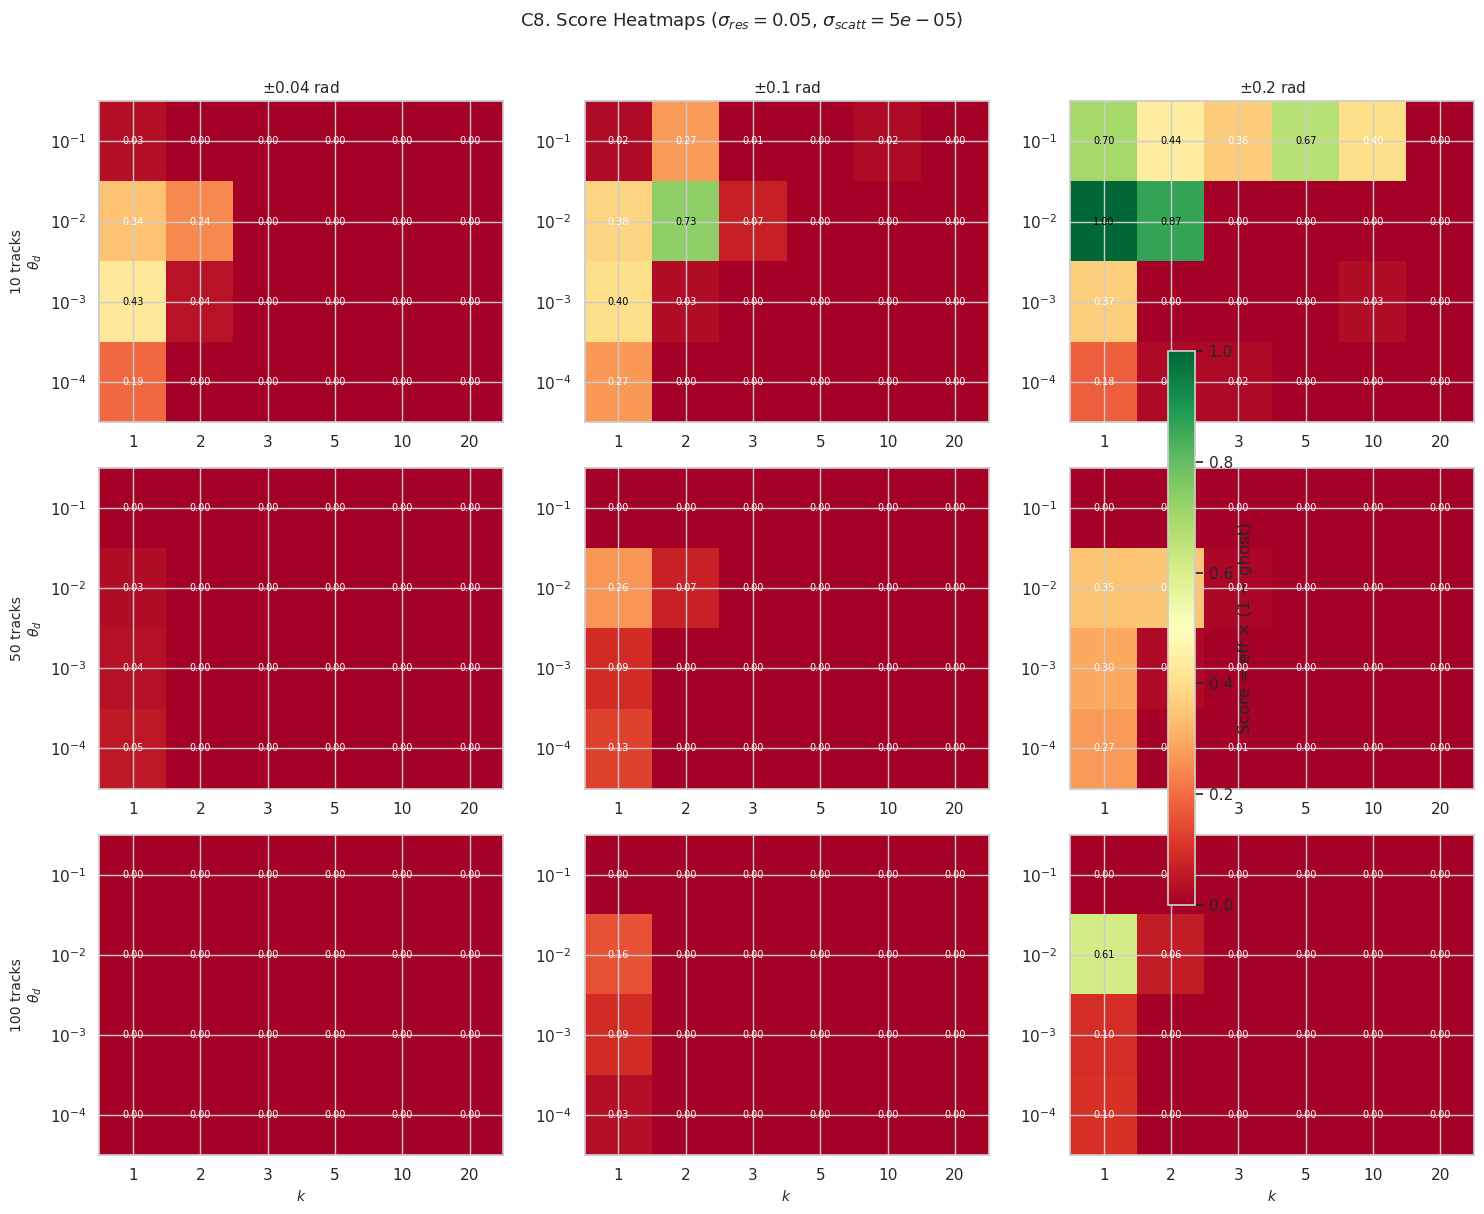

/tmp/ipykernel_3014358/1632402914.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


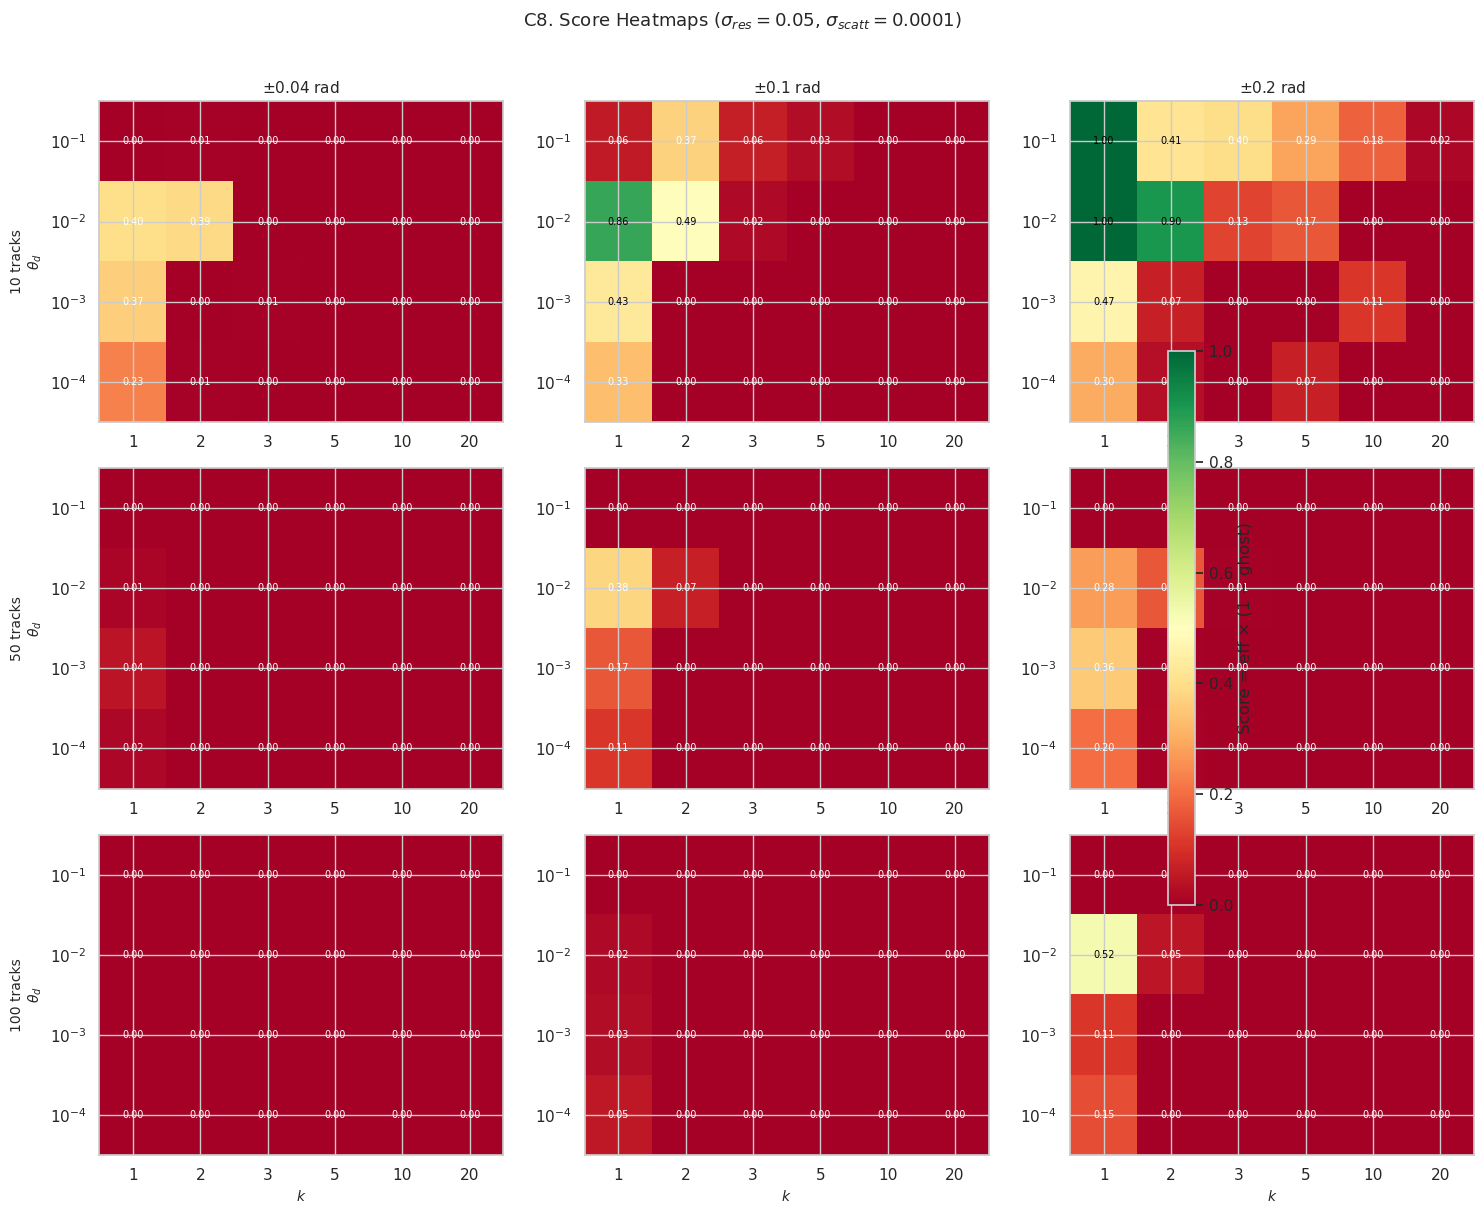

/tmp/ipykernel_3014358/1632402914.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


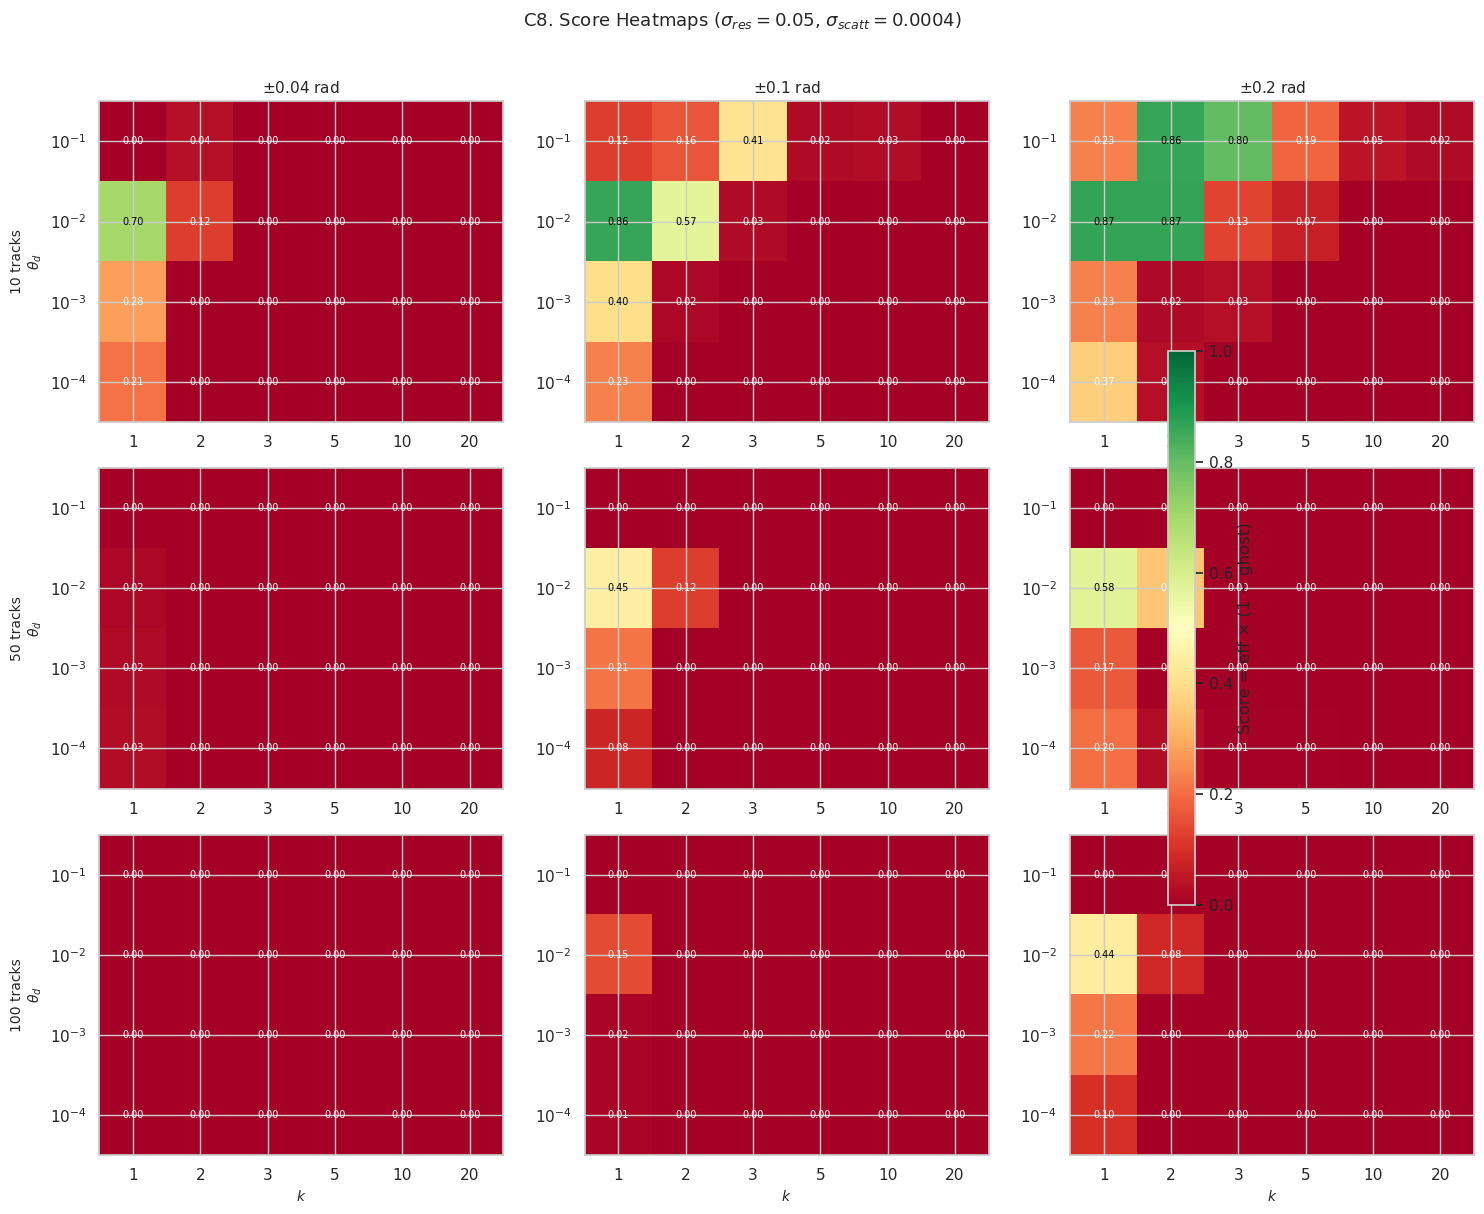

In [59]:
# C8 heatmaps for all physics conditions
for me in MEAS_ERRS:
    for cn in COLL_NOISES:
        if me == 0.0 and cn == 1e-4:
            continue
        plot_score_heatmaps(df, meas_err=me, coll_noise=cn,
                            save_name=f'C8_score_me{me}_cn{cn}.png')

---
## D. Physics Sensitivity

### D9–D10. Optimal $k$ vs Physics Parameters

In [60]:
df['n_tracks'].plot

In [61]:
def find_optimal(df, groupby_cols, metric='score'):
    """For each group, find the (k, theta_d) that maximises the metric."""
    idx = df.groupby(groupby_cols)[metric].idxmax()
    return df.loc[idx]

# Optimal per (angle, n_tracks, meas_err, coll_noise)
opt = find_optimal(df, ['angle', 'n_tracks', 'measurement_error', 'collision_noise'])
print(f'Optimal configurations: {len(opt)} rows')
opt[['angle','n_tracks','measurement_error','collision_noise','scale','theta_d','epsilon',
     'm_reconstruction_efficiency_mean','m_ghost_rate_mean','score']].head(10)

Optimal configurations: 81 rows


,angle,n_tracks,measurement_error,collision_noise,scale,theta_d,epsilon,m_reconstruction_efficiency_mean,m_ghost_rate_mean,score
0,0.04,10,0.00,0.00005,1,0.0001,0.000074,1.000000,0.000000,1.000000
10,0.04,10,0.00,0.00010,1,0.0010,0.000143,1.000000,0.000000,1.000000
11,0.04,10,0.00,0.00040,1,0.0010,0.000566,1.000000,0.000000,1.000000
57,0.04,10,0.01,0.00005,2,0.0100,0.002104,1.000000,0.000000,1.000000
22,0.04,10,0.01,0.00010,1,0.0100,0.001059,1.000000,0.000000,1.000000
59,0.04,10,0.01,0.00040,2,0.0100,0.002385,1.000000,0.000000,1.000000
15,0.04,10,0.05,0.00005,1,0.0010,0.005249,0.433333,0.000000,0.433333
25,0.04,10,0.05,0.00010,1,0.0100,0.005251,0.600000,0.333333,0.400000
26,0.04,10,0.05,0.00040,1,0.0100,0.005279,0.766667,0.089286,0.698214
216,0.04,50,0.00,0.00005,1,0.0001,0.000074,1.000000,0.000000,1.000000


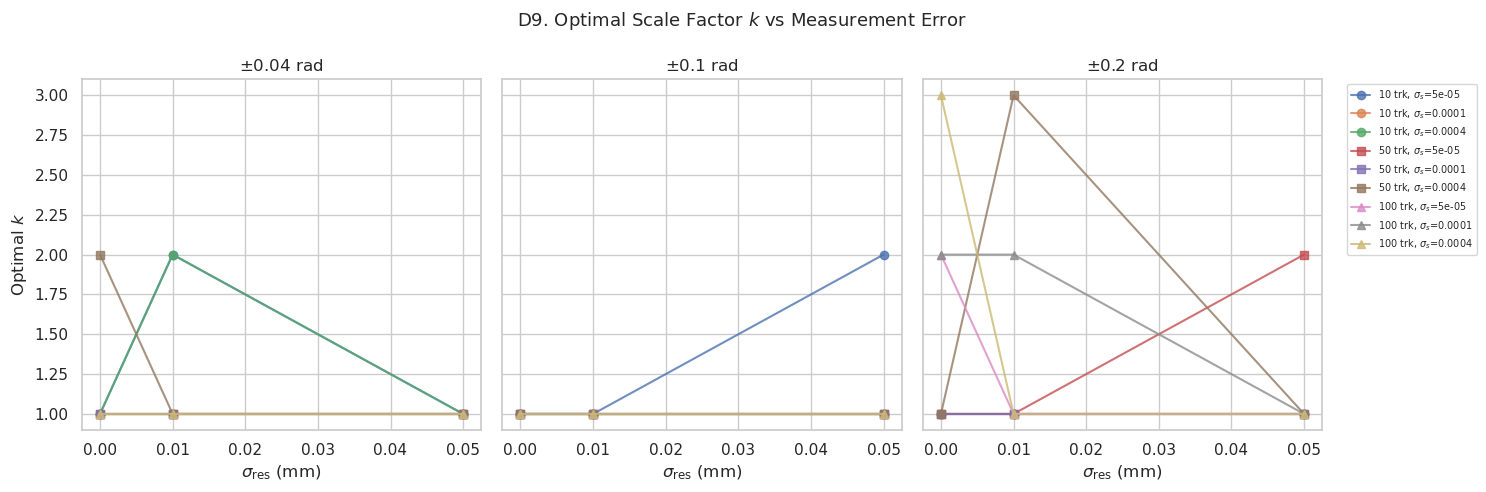

In [62]:
# D9: Optimal k vs sigma_res
fig, axes = plt.subplots(1, len(ANGLES), figsize=(15, 5), sharey=True)
markers = ['o', 's', '^']

for j, ang in enumerate(ANGLES):
    ax = axes[j]
    for ti, nt in enumerate(TRACKS):
        sel = opt[(opt.angle == ang) & (opt.n_tracks == nt)]
        for cn in COLL_NOISES:
            row = sel[sel.collision_noise == cn].sort_values('measurement_error')
            ax.plot(row['measurement_error'], row['scale'],
                    f'-{markers[ti]}', ms=6, alpha=0.8,
                    label=f'{nt} trk, $\\sigma_s$={cn}')
    ax.set_title(ANGLE_LABELS[ang])
    ax.set_xlabel(r'$\sigma_{\text{res}}$ (mm)')
    if j == 0:
        ax.set_ylabel('Optimal $k$')

axes[-1].legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')
fig.suptitle('D9. Optimal Scale Factor $k$ vs Measurement Error', fontsize=13)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'D9_optimal_k_vs_meas_err.png', bbox_inches='tight', dpi=150)
plt.show()

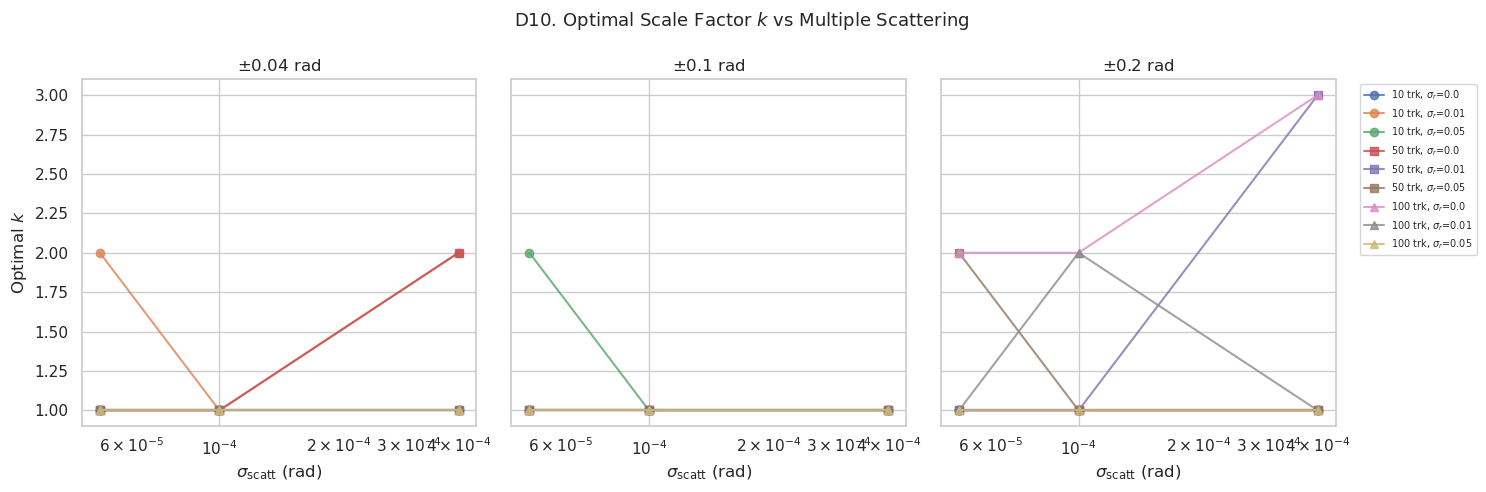

In [63]:
# D10: Optimal k vs sigma_scatt
fig, axes = plt.subplots(1, len(ANGLES), figsize=(15, 5), sharey=True)

for j, ang in enumerate(ANGLES):
    ax = axes[j]
    for ti, nt in enumerate(TRACKS):
        sel = opt[(opt.angle == ang) & (opt.n_tracks == nt)]
        for me in MEAS_ERRS:
            row = sel[sel.measurement_error == me].sort_values('collision_noise')
            ax.plot(row['collision_noise'], row['scale'],
                    f'-{markers[ti]}', ms=6, alpha=0.8,
                    label=f'{nt} trk, $\\sigma_r$={me}')
    ax.set_title(ANGLE_LABELS[ang])
    ax.set_xlabel(r'$\sigma_{\text{scatt}}$ (rad)')
    ax.set_xscale('log')
    if j == 0:
        ax.set_ylabel('Optimal $k$')

axes[-1].legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')
fig.suptitle('D10. Optimal Scale Factor $k$ vs Multiple Scattering', fontsize=13)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'D10_optimal_k_vs_coll_noise.png', bbox_inches='tight', dpi=150)
plt.show()

### D11. Physics-Regime Stability Table

In [64]:
# D11: Best (k, theta_d) per physics regime (averaged over angle/tracks)
opt_phys = find_optimal(df, ['measurement_error', 'collision_noise',
                             'angle', 'n_tracks'])

table = opt_phys.groupby(['measurement_error', 'collision_noise']).agg(
    k_mode=('scale', lambda x: x.mode().iloc[0]),
    td_mode=('theta_d', lambda x: x.mode().iloc[0]),
    eff_mean=('m_reconstruction_efficiency_mean', 'mean'),
    ghost_mean=('m_ghost_rate_mean', 'mean'),
    score_mean=('score', 'mean'),
    epsilon_mean=('epsilon', 'mean'),
).reset_index()

print('D11. Physics-regime stability table')
print('=' * 80)
table.style.format({
    'eff_mean': '{:.3f}',
    'ghost_mean': '{:.3f}',
    'score_mean': '{:.3f}',
    'epsilon_mean': '{:.6f}',
})

D11. Physics-regime stability table


,measurement_error,collision_noise,k_mode,td_mode,eff_mean,ghost_mean,score_mean,epsilon_mean
0,0.000000,0.000050,1,0.001000,1.000,0.000,1.000,0.000082
1,0.000000,0.000100,1,0.001000,0.997,0.001,0.996,0.000159
2,0.000000,0.000400,1,0.001000,0.955,0.011,0.946,0.000755
3,0.010000,0.000050,1,0.001000,0.860,0.035,0.837,0.001169
4,0.010000,0.000100,1,0.010000,0.905,0.022,0.889,0.001177
5,0.010000,0.000400,1,0.010000,0.857,0.046,0.830,0.001590
6,0.050000,0.000050,1,0.010000,0.440,0.227,0.401,0.006416
7,0.050000,0.000100,1,0.010000,0.464,0.325,0.403,0.005251
8,0.050000,0.000400,1,0.010000,0.491,0.245,0.452,0.005279


---
## E. Density Dependence

### E12. All Metrics vs $n_{\text{tracks}}$ at Optimal Parameters

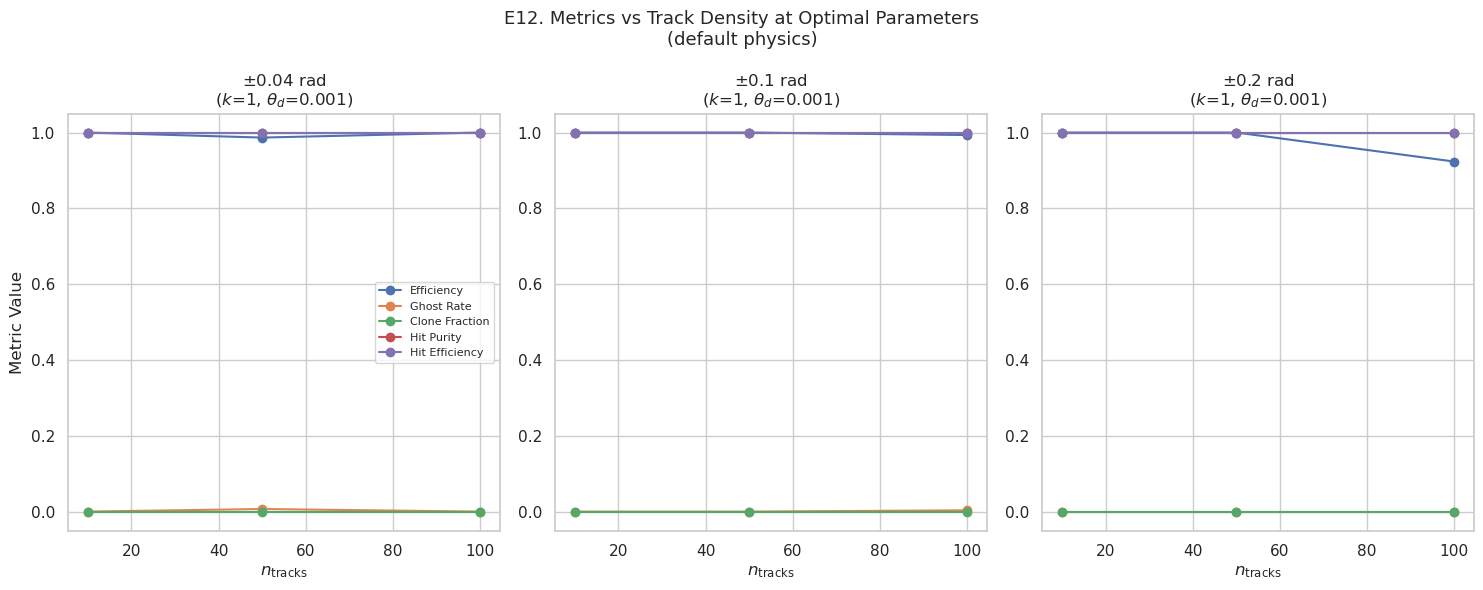

In [65]:
# For each (angle, physics), find the best (k, theta_d), then show how it
# performs across track densities.

metrics_to_plot = [
    ('m_reconstruction_efficiency_mean', 'Efficiency'),
    ('m_ghost_rate_mean', 'Ghost Rate'),
    ('m_clone_fraction_total_mean', 'Clone Fraction'),
    ('hit_purity_mean_primary_mean', 'Hit Purity'),
    ('hit_efficiency_mean_primary_mean', 'Hit Efficiency'),
]

# Use default physics for clarity
sub_def = df[(df.measurement_error == 0.0) & (df.collision_noise == 1e-4)]

# Find optimal (k, theta_d) per angle using 50-track data
opt50 = find_optimal(sub_def[sub_def.n_tracks == 50], ['angle'])

fig, axes = plt.subplots(1, len(ANGLES), figsize=(15, 6), sharey=False)

for j, ang in enumerate(ANGLES):
    ax = axes[j]
    best = opt50[opt50.angle == ang].iloc[0]
    best_k, best_td = best.scale, best.theta_d
    
    sel = sub_def[(sub_def.angle == ang) & (sub_def.scale == best_k) &
                  (sub_def.theta_d == best_td)].sort_values('n_tracks')
    
    for mi, (mcol, mname) in enumerate(metrics_to_plot):
        ax.plot(sel['n_tracks'], sel[mcol], '-o', ms=6, label=mname)
    
    ax.set_title(f'{ANGLE_LABELS[ang]}\n($k$={int(best_k)}, $\\theta_d$={best_td})')
    ax.set_xlabel('$n_{\\text{tracks}}$')
    ax.set_ylim(-0.05, 1.05)
    if j == 0:
        ax.set_ylabel('Metric Value')
        ax.legend(fontsize=8)

fig.suptitle('E12. Metrics vs Track Density at Optimal Parameters\n(default physics)',
             fontsize=13)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'E12_metrics_vs_density.png', bbox_inches='tight', dpi=150)
plt.show()

### E13. Efficiency vs Ghost Rate Scatter (Pareto)

/tmp/ipykernel_3014358/2274011125.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


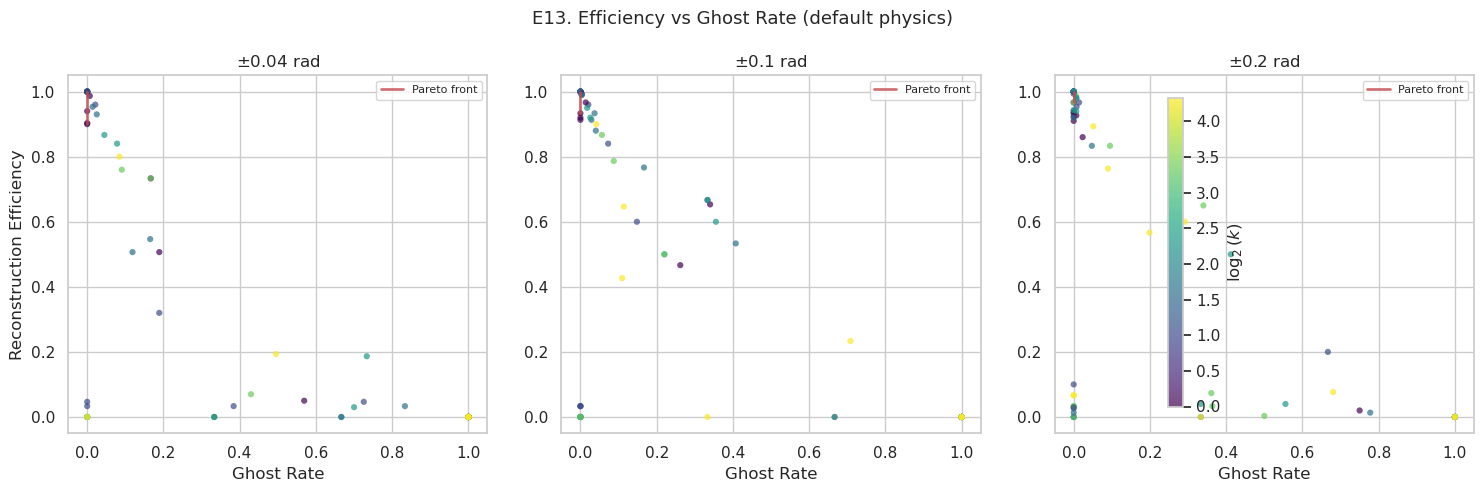

In [66]:
def pareto_front(eff, ghost):
    """Find Pareto-optimal indices: max eff, min ghost."""
    pts = np.column_stack([eff, ghost])
    is_pareto = np.ones(len(pts), dtype=bool)
    for i, p in enumerate(pts):
        if is_pareto[i]:
            # A point dominates if it has higher eff AND lower ghost
            is_pareto[is_pareto] = ~np.all(
                pts[is_pareto] >= p, axis=1) | np.all(
                pts[is_pareto] == p, axis=1)
            # But we want: dominator has eff >= p.eff AND ghost <= p.ghost
            # Simpler: mark dominated
            is_pareto[i] = True
    return is_pareto


fig, axes = plt.subplots(1, len(ANGLES), figsize=(15, 5))
sub_def = df[(df.measurement_error == 0.0) & (df.collision_noise == 1e-4)]

for j, ang in enumerate(ANGLES):
    ax = axes[j]
    sel = sub_def[sub_def.angle == ang]
    
    sc = ax.scatter(sel['m_ghost_rate_mean'], sel['m_reconstruction_efficiency_mean'],
                    c=np.log2(sel['scale']), cmap='viridis', s=20, alpha=0.7,
                    edgecolors='none')
    
    # Highlight Pareto front
    eff = sel['m_reconstruction_efficiency_mean'].values
    ghost = sel['m_ghost_rate_mean'].values
    # Simple Pareto: for each unique ghost level, keep max eff
    pareto_df = sel.copy()
    pareto_df = pareto_df.sort_values('m_ghost_rate_mean')
    pareto_pts = []
    best_eff = -1
    for _, r in pareto_df.sort_values('m_ghost_rate_mean').iterrows():
        if r['m_reconstruction_efficiency_mean'] > best_eff:
            pareto_pts.append(r)
            best_eff = r['m_reconstruction_efficiency_mean']
    if pareto_pts:
        p = pd.DataFrame(pareto_pts)
        ax.plot(p['m_ghost_rate_mean'], p['m_reconstruction_efficiency_mean'],
                'r-', lw=2, alpha=0.8, label='Pareto front')
    
    ax.set_title(ANGLE_LABELS[ang])
    ax.set_xlabel('Ghost Rate')
    if j == 0:
        ax.set_ylabel('Reconstruction Efficiency')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)

fig.colorbar(sc, ax=axes, label='$\\log_2(k)$', shrink=0.8)
fig.suptitle('E13. Efficiency vs Ghost Rate (default physics)', fontsize=13)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'E13_pareto_eff_ghost.png', bbox_inches='tight', dpi=150)
plt.show()

---
## G. Epsilon Landscape

### G17. All Metrics vs Computed $\varepsilon$

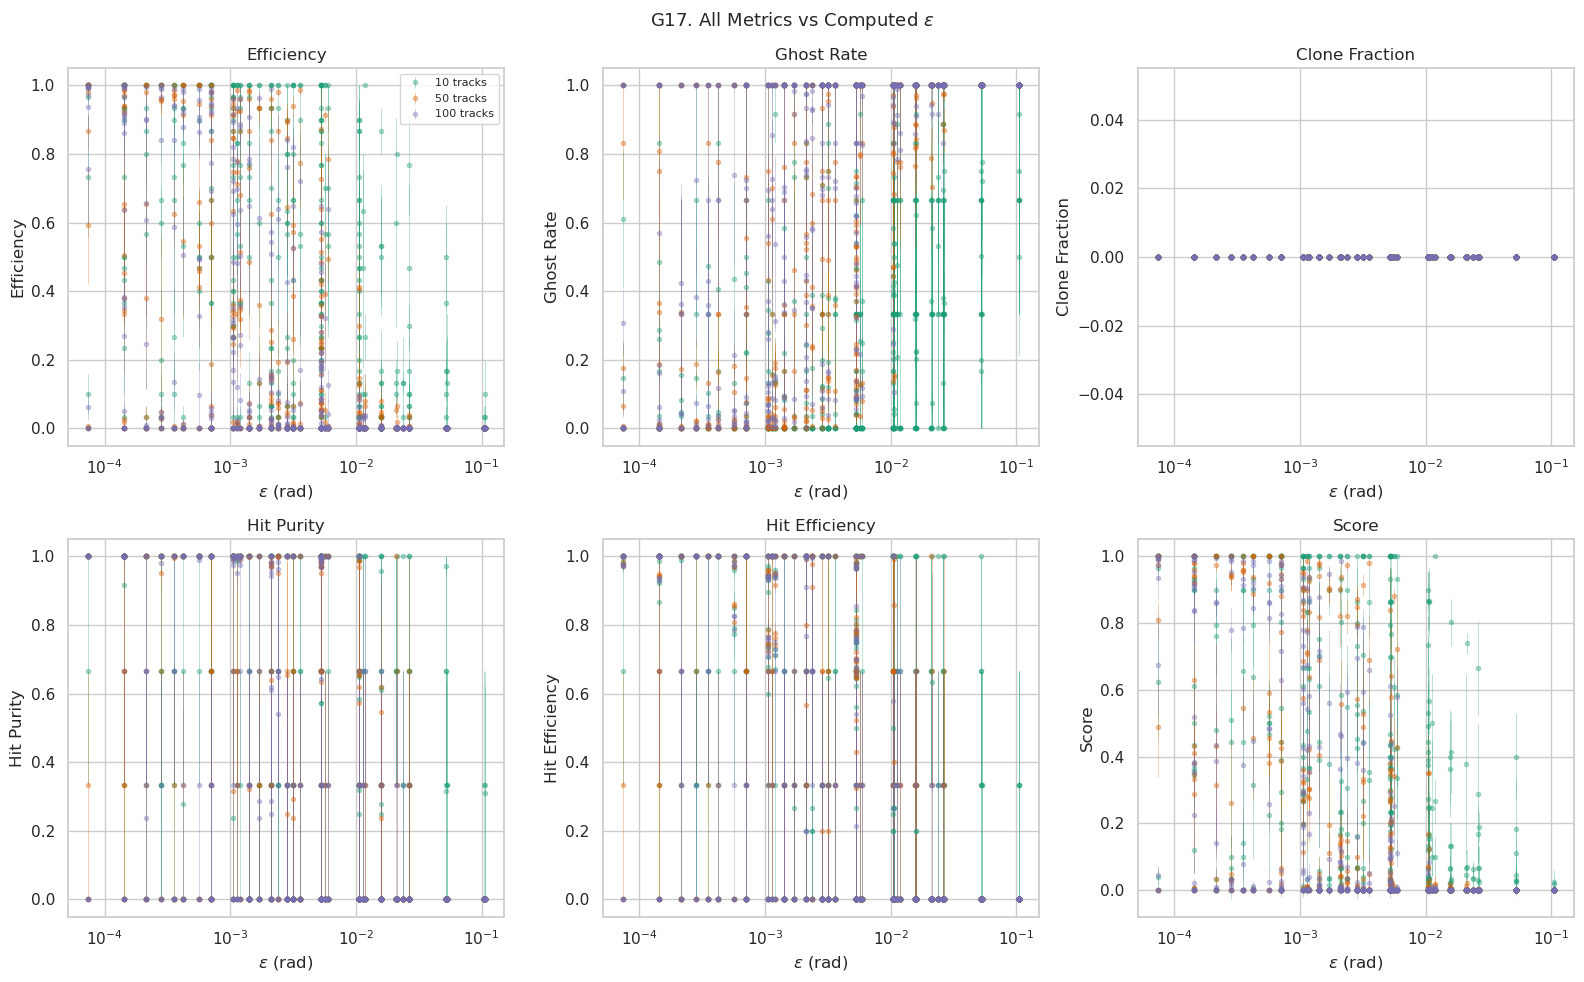

In [67]:
# SE column for score is not in the CSV, so we propagate it analytically
# score = eff * (1 - ghost)  →  se_score ≈ sqrt[ (1-g)^2 se_e^2 + e^2 se_g^2 ]
df['score_se'] = np.sqrt(
    (1 - df['m_ghost_rate_mean'])**2 * df['m_reconstruction_efficiency_se']**2 +
    df['m_reconstruction_efficiency_mean']**2 * df['m_ghost_rate_se']**2
)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
metric_list = [
    ('m_reconstruction_efficiency_mean', 'm_reconstruction_efficiency_se', 'Efficiency'),
    ('m_ghost_rate_mean', 'm_ghost_rate_se', 'Ghost Rate'),
    ('m_clone_fraction_total_mean', 'm_clone_fraction_total_se', 'Clone Fraction'),
    ('hit_purity_mean_primary_mean', 'hit_purity_mean_primary_se', 'Hit Purity'),
    ('hit_efficiency_mean_primary_mean', 'hit_efficiency_mean_primary_se', 'Hit Efficiency'),
    ('score', 'score_se', 'Score'),
]

for idx, (mcol, secol, mname) in enumerate(metric_list):
    ax = axes.flat[idx]
    for nt in TRACKS:
        sel = df[df.n_tracks == nt].sort_values('epsilon')
        ax.errorbar(sel['epsilon'], sel[mcol], yerr=sel[secol],
                    fmt='o', ms=3, capsize=0, alpha=0.35, lw=0.6,
                    color=TRACK_COLORS[nt],
                    label=TRACK_LABELS[nt] if idx == 0 else None)
    ax.set_xlabel(r'$\varepsilon$ (rad)')
    ax.set_ylabel(mname)
    ax.set_title(mname)
    ax.set_xscale('log')

axes.flat[0].legend(fontsize=8)
fig.suptitle('G17. All Metrics vs Computed $\\varepsilon$', fontsize=13)
fig.tight_layout()
fig.savefig(PLOT_DIR / 'G17_metrics_vs_epsilon.png', bbox_inches='tight', dpi=150)
plt.show()

---
## I. Individual Metric Scans at Optimal Baseline

For each metric, scan over one parameter at a time while holding the remaining
parameters at their **per-angle optimal values** (chosen by maximising the Score
at $n_\text{tracks}=50$). Each plot shows all track multiplicities as separate
coloured scatter series with error bars.

Scanned parameters: $k$, $\theta_d$, $\sigma_\text{res}$, $\sigma_\text{scatt}$, $\varepsilon$.

In [68]:
# ── Find per-angle optimal baseline (maximise score at n_tracks=50) ──
# For each angle, pick the (k, theta_d, meas_err, coll_noise) that gives the
# highest score at 50 tracks.  This becomes the "held-fixed" baseline.

_mid = df[df.n_tracks == 50]
_opt_idx = _mid.groupby('angle')['score'].idxmax()
opt_baseline = df.loc[_opt_idx].set_index('angle')

print('Optimal baseline per angle (from n_tracks=50):')
for ang in ANGLES:
    r = opt_baseline.loc[ang]
    print(f'  {ANGLE_LABELS[ang]:>15s}:  k={r.scale:.0f}, θ_d={r.theta_d:.0e}, '
          f'σ_res={r.measurement_error}, σ_scatt={r.collision_noise:.0e}, '
          f'score={r.score:.3f}')

# ── Metrics to scan ──
ALL_METRICS = [
    ('m_reconstruction_efficiency_mean', 'm_reconstruction_efficiency_se',
     'Reconstruction Efficiency'),
    ('m_ghost_rate_mean', 'm_ghost_rate_se', 'Ghost Rate'),
    ('m_clone_fraction_total_mean', 'm_clone_fraction_total_se',
     'Clone Fraction (total)'),
    ('m_clone_fraction_among_matched_mean', 'm_clone_fraction_among_matched_se',
     'Clone Fraction (matched)'),
    ('m_purity_all_matched_mean', 'm_purity_all_matched_se',
     'Purity (all matched)'),
    ('m_purity_primary_only_mean', 'm_purity_primary_only_se',
     'Purity (primary only)'),
    ('m_hit_efficiency_mean_mean', 'm_hit_efficiency_mean_se',
     'Hit Efficiency (mean)'),
    ('m_hit_efficiency_weighted_mean', 'm_hit_efficiency_weighted_se',
     'Hit Efficiency (weighted)'),
    ('hit_purity_mean_primary_mean', 'hit_purity_mean_primary_se',
     'Hit Purity (primary)'),
    ('hit_efficiency_mean_primary_mean', 'hit_efficiency_mean_primary_se',
     'Hit Efficiency (primary)'),
    ('hit_efficiency_weighted_primary_mean', 'hit_efficiency_weighted_primary_se',
     'Hit Efficiency (wt. primary)'),
    ('score', 'score_se', 'Score'),
]

# ── Scan definitions: (column, nice label, use log x-axis?) ──
SCAN_PARAMS = [
    ('scale',             '$k$ (scale factor)',                            True),
    ('theta_d',           r'$\theta_d$ (ERF width)',                      True),
    ('measurement_error', r'$\sigma_{\mathrm{res}}$ (mm)',                False),
    ('collision_noise',   r'$\sigma_{\mathrm{scatt}}$ (rad)',             True),
    ('epsilon',           r'$\varepsilon$ (rad)',                          True),
]

# Map from scan column → the other columns that should be held fixed
# (epsilon is derived, so when scanning it we vary k and hold physics fixed)
HOLD_FIXED = {
    'scale':             ['theta_d', 'measurement_error', 'collision_noise'],
    'theta_d':           ['scale',   'measurement_error', 'collision_noise'],
    'measurement_error': ['scale',   'theta_d',           'collision_noise'],
    'collision_noise':   ['scale',   'theta_d',           'measurement_error'],
    'epsilon':           ['theta_d', 'measurement_error', 'collision_noise'],
}

print(f'\n{len(ALL_METRICS)} metrics × {len(SCAN_PARAMS)} scanned parameters '
      f'= {len(ALL_METRICS)*len(SCAN_PARAMS)} plots')

Optimal baseline per angle (from n_tracks=50):
   $\pm 0.04$ rad:  k=1, θ_d=1e-04, σ_res=0.0, σ_scatt=5e-05, score=1.000
    $\pm 0.1$ rad:  k=1, θ_d=1e-04, σ_res=0.0, σ_scatt=5e-05, score=1.000
    $\pm 0.2$ rad:  k=1, θ_d=1e-03, σ_res=0.0, σ_scatt=5e-05, score=1.000

12 metrics × 5 scanned parameters = 60 plots


In [69]:
def plot_single_metric_scan(df, opt_baseline, scan_col, scan_label, logx,
                            metric_mean, metric_se, metric_name,
                            save_name=None):
    """One figure per (metric, scanned parameter): 1 × len(ANGLES) subplots,
    scatter + error bars coloured by n_tracks."""

    fig, axes = plt.subplots(1, len(ANGLES), figsize=(5 * len(ANGLES), 5),
                             sharey=True)
    if len(ANGLES) == 1:
        axes = [axes]

    hold_cols = HOLD_FIXED[scan_col]

    for j, ang in enumerate(ANGLES):
        ax = axes[j]
        base = opt_baseline.loc[ang]

        # Build filter: hold non-scanned params at optimal, this angle
        mask = df['angle'] == ang
        for hc in hold_cols:
            mask &= df[hc] == base[hc]

        sel = df[mask]

        for nt in TRACKS:
            row = sel[sel.n_tracks == nt].sort_values(scan_col)
            if row.empty:
                continue
            ax.errorbar(row[scan_col], row[metric_mean], yerr=row[metric_se],
                        fmt='o', ms=5, capsize=3, lw=1.5,
                        color=TRACK_COLORS[nt],
                        label=TRACK_LABELS[nt] if j == len(ANGLES) - 1 else None)

        ax.set_title(ANGLE_LABELS[ang], fontsize=11)
        ax.set_xlabel(scan_label, fontsize=10)
        if j == 0:
            ax.set_ylabel(metric_name, fontsize=10)
        if logx and sel[scan_col].min() > 0:
            ax.set_xscale('log')

    axes[-1].legend(title='Tracks', fontsize=8, title_fontsize=9)

    # Subtitle showing the held-fixed values (from first angle for brevity)
    base0 = opt_baseline.loc[ANGLES[0]]
    held_str = ', '.join(f'{hc}={base0[hc]:.3g}' for hc in hold_cols)
    fig.suptitle(f'{metric_name} vs {scan_label}\n(held fixed: {held_str})',
                 fontsize=12, y=1.02)
    fig.tight_layout()
    if save_name:
        fig.savefig(PLOT_DIR / save_name, bbox_inches='tight', dpi=150)
    plt.show()

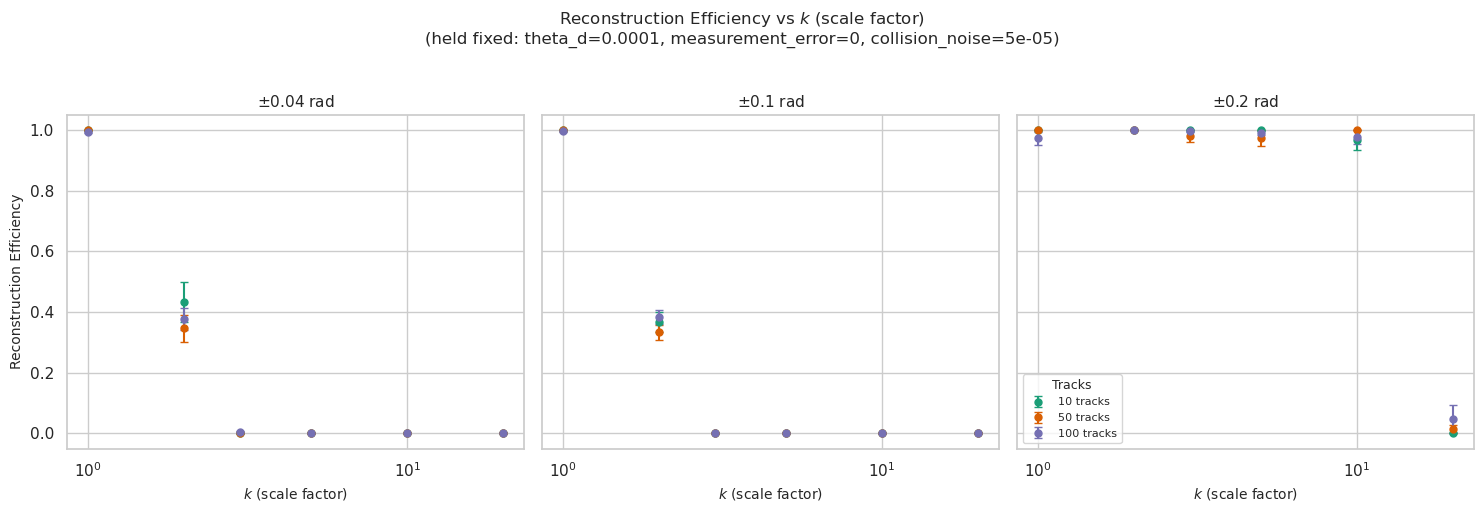

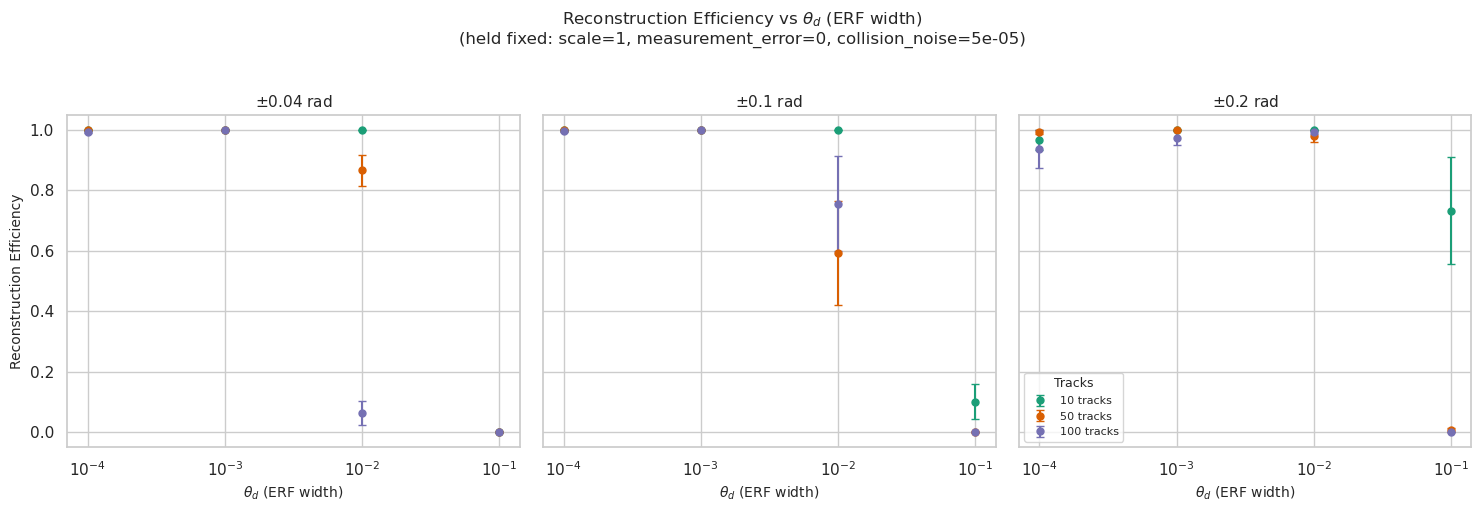

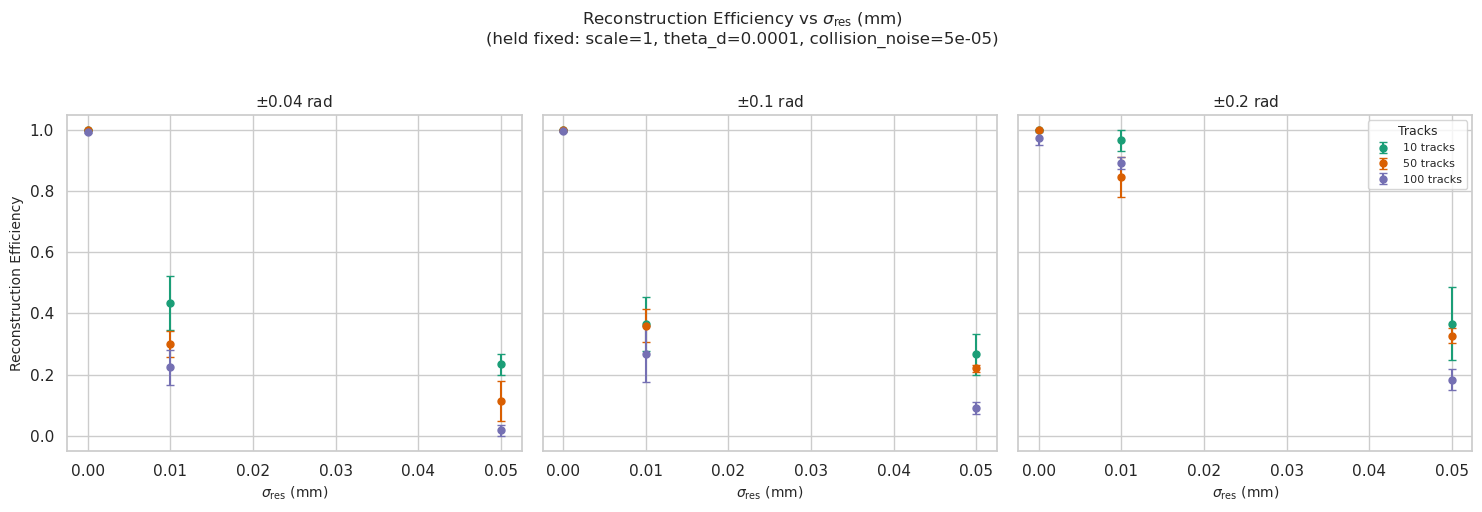

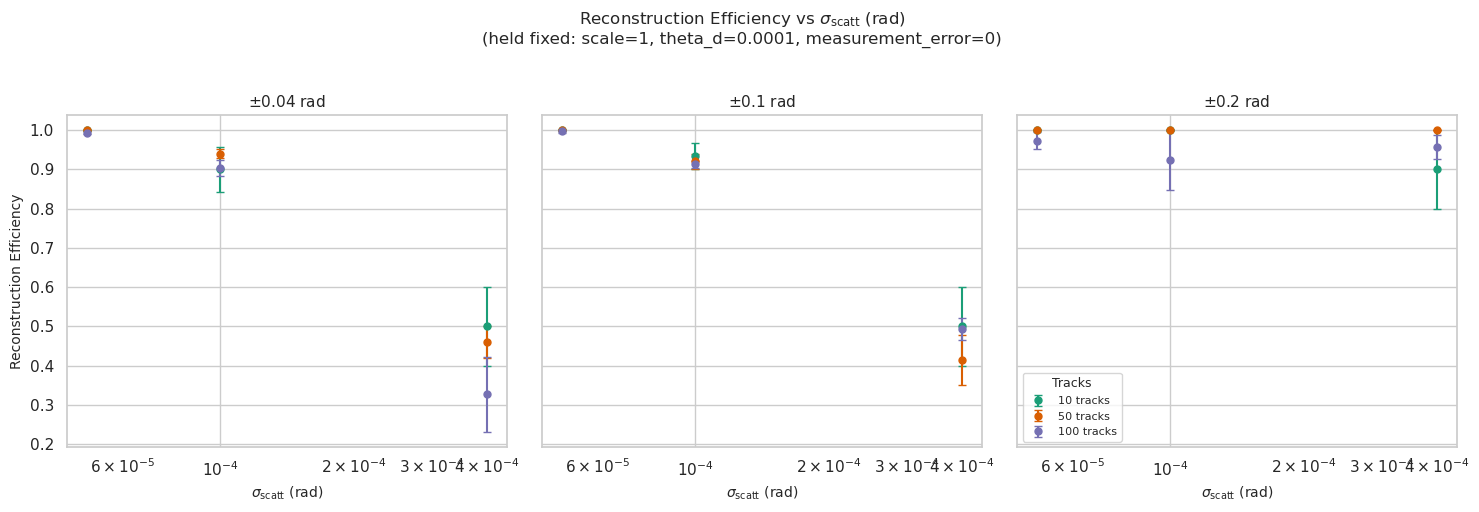

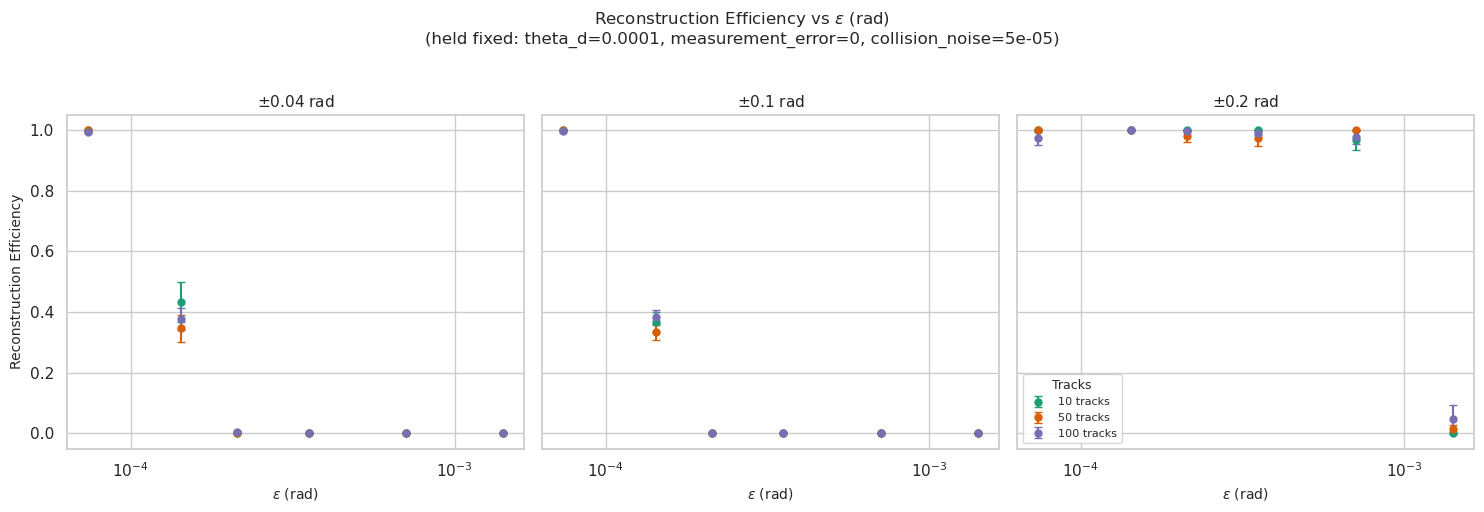

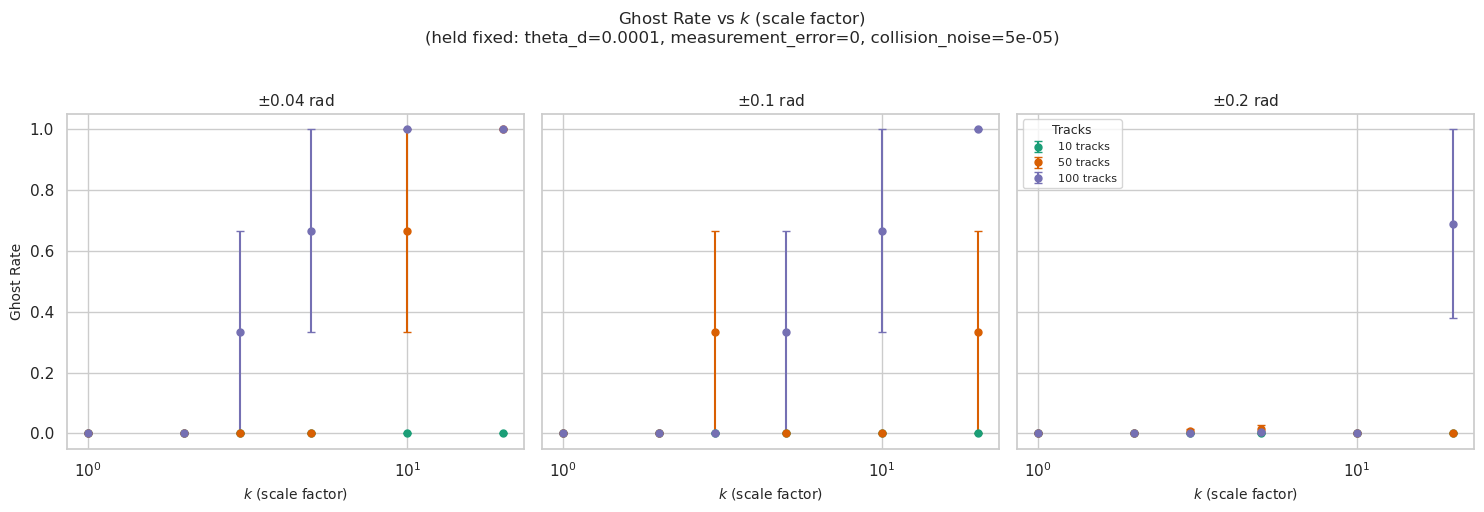

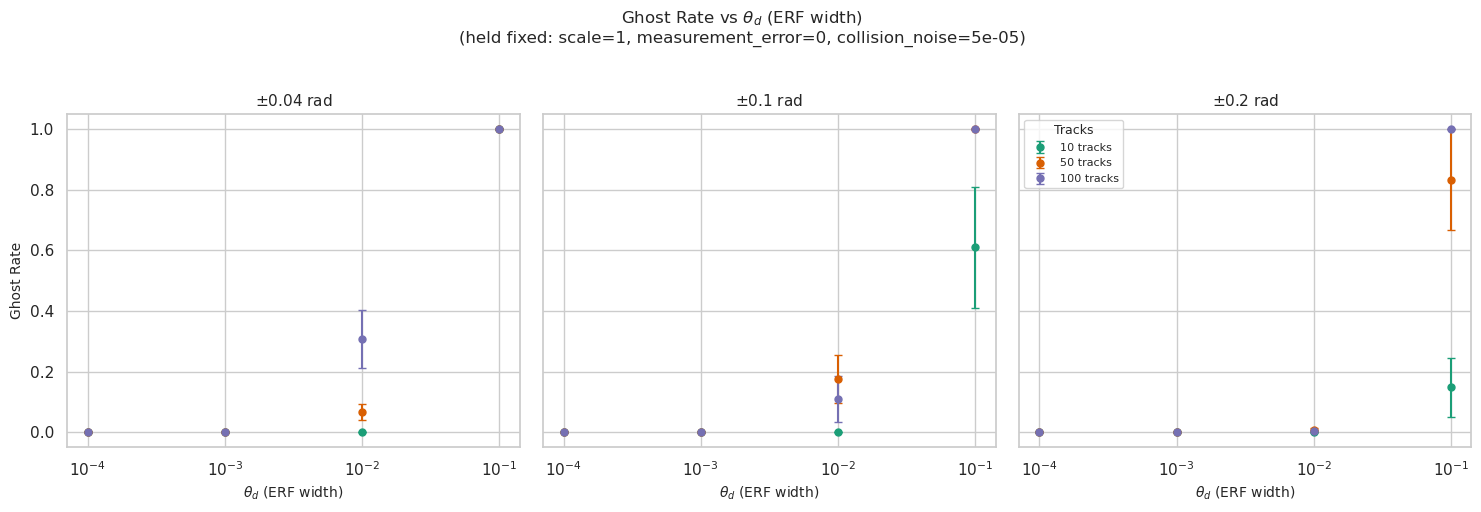

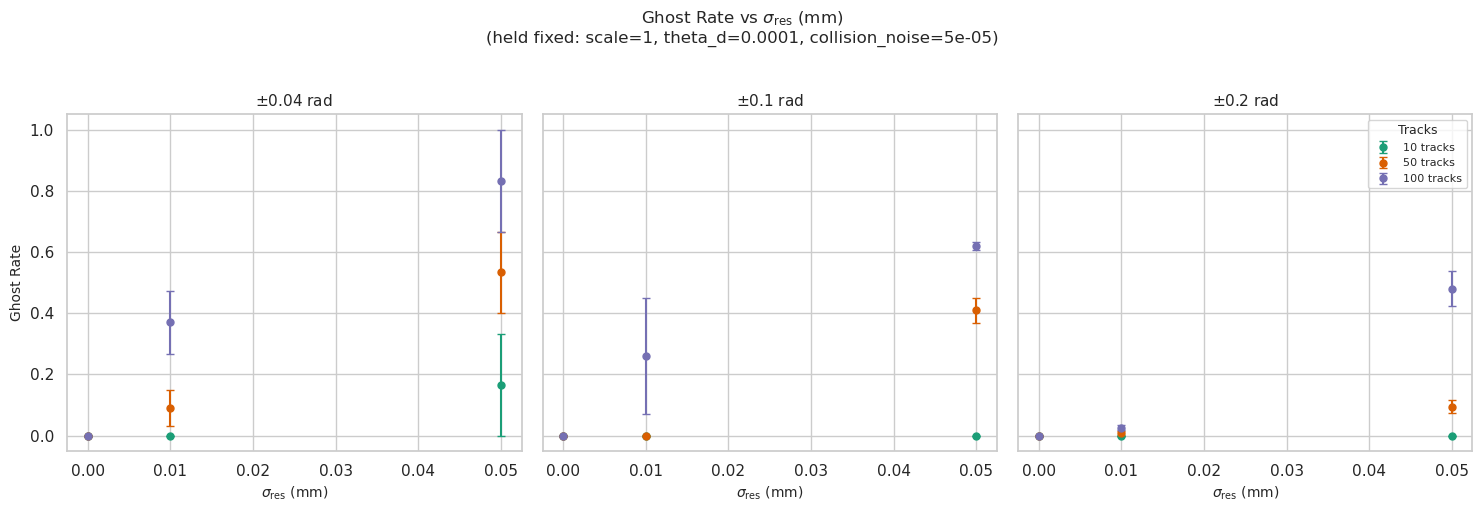

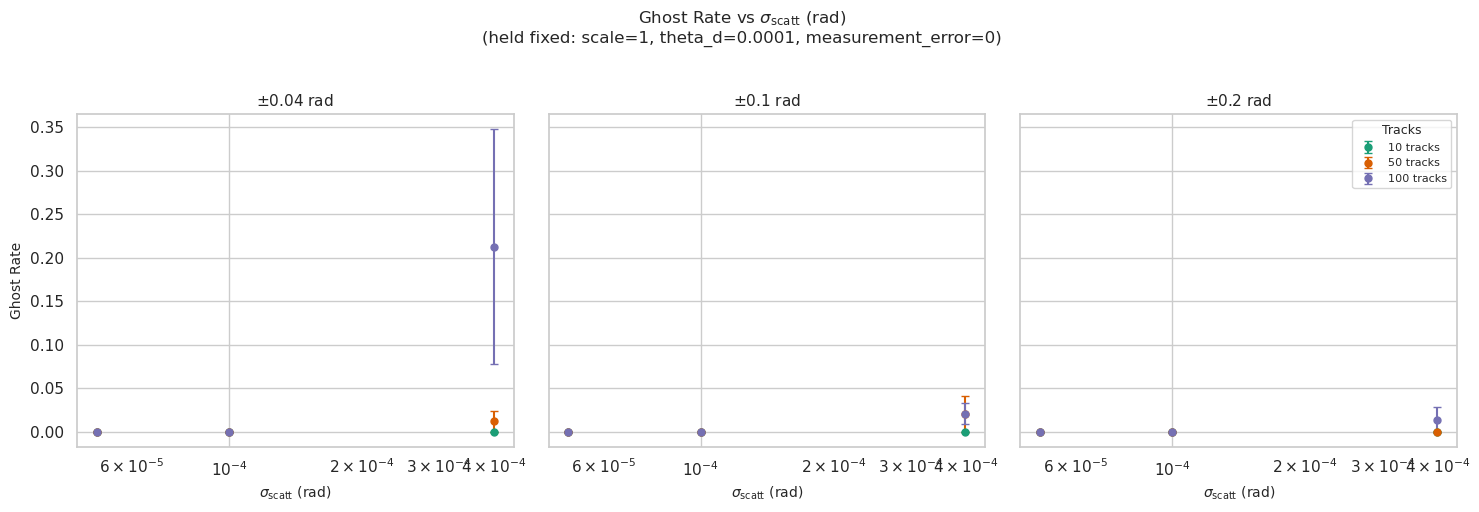

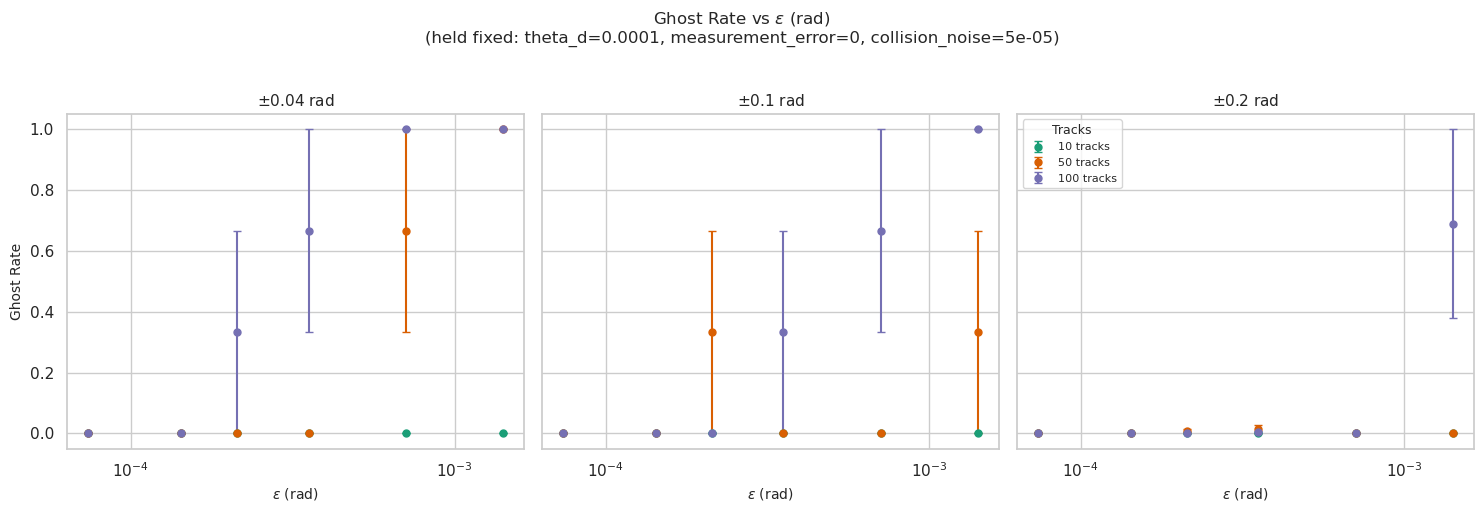

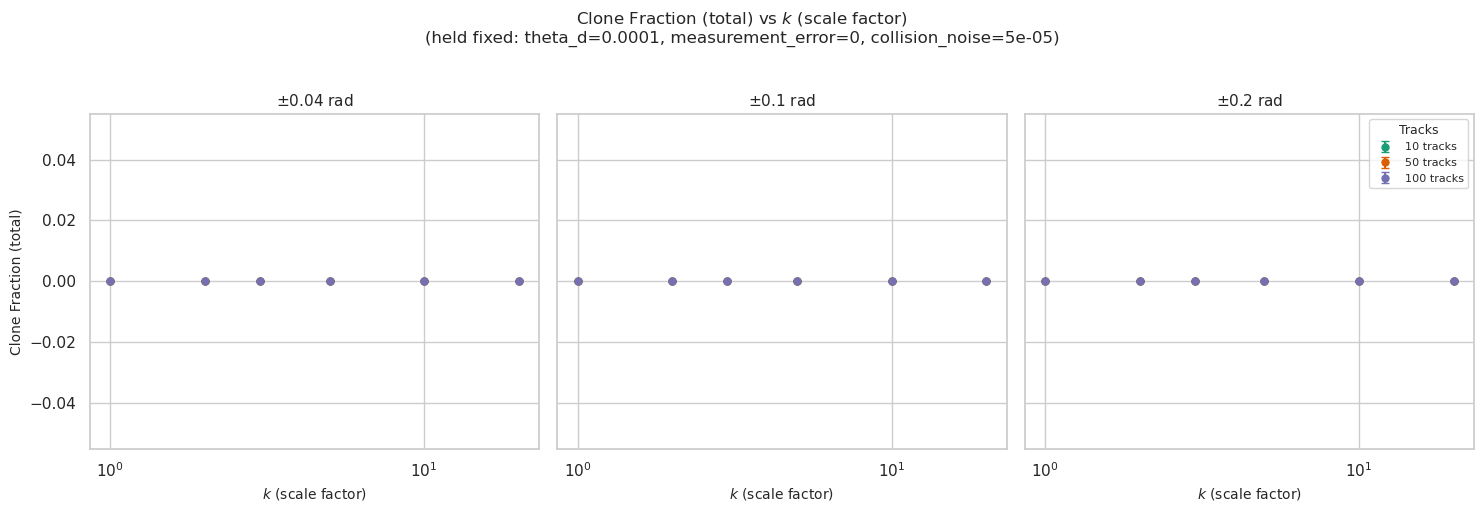

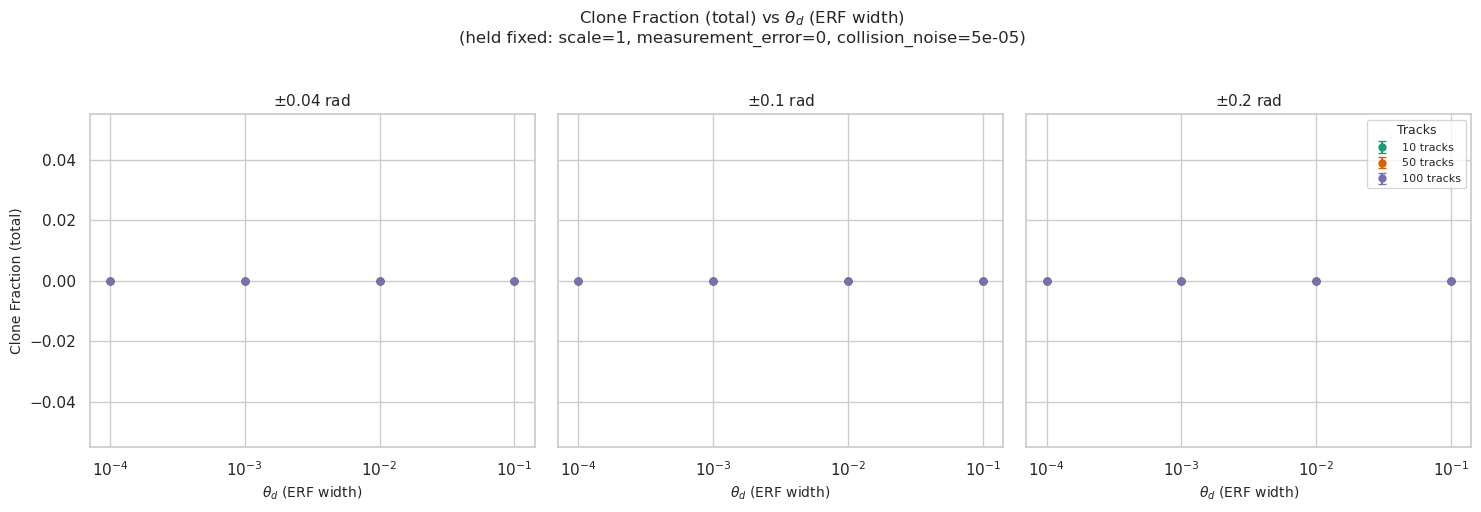

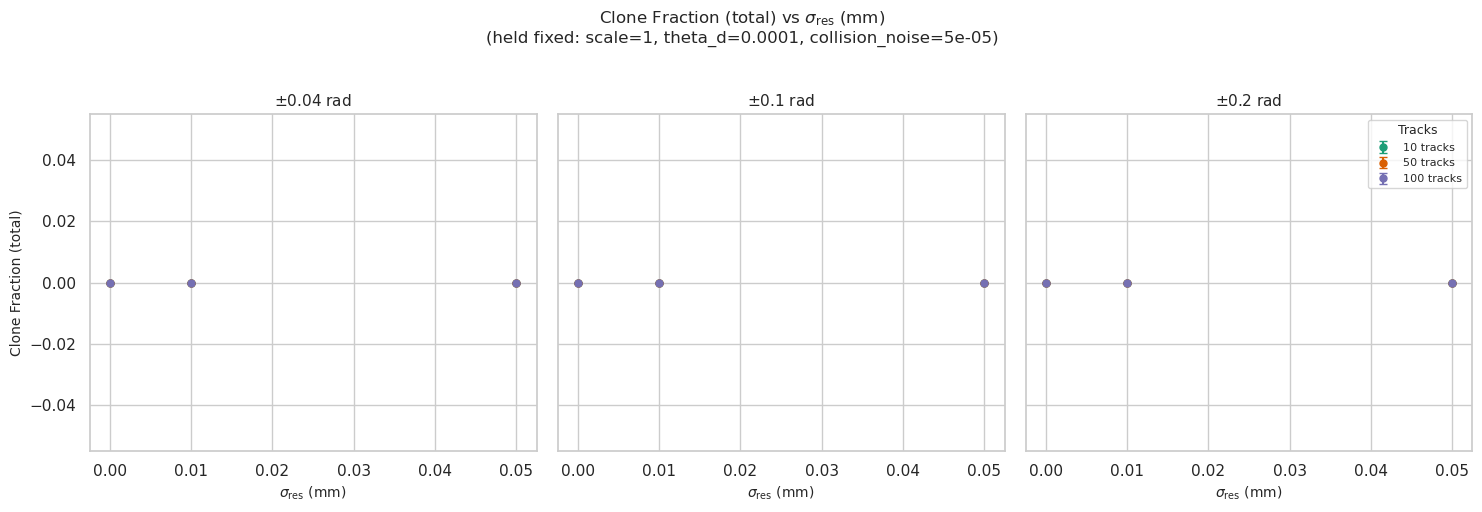

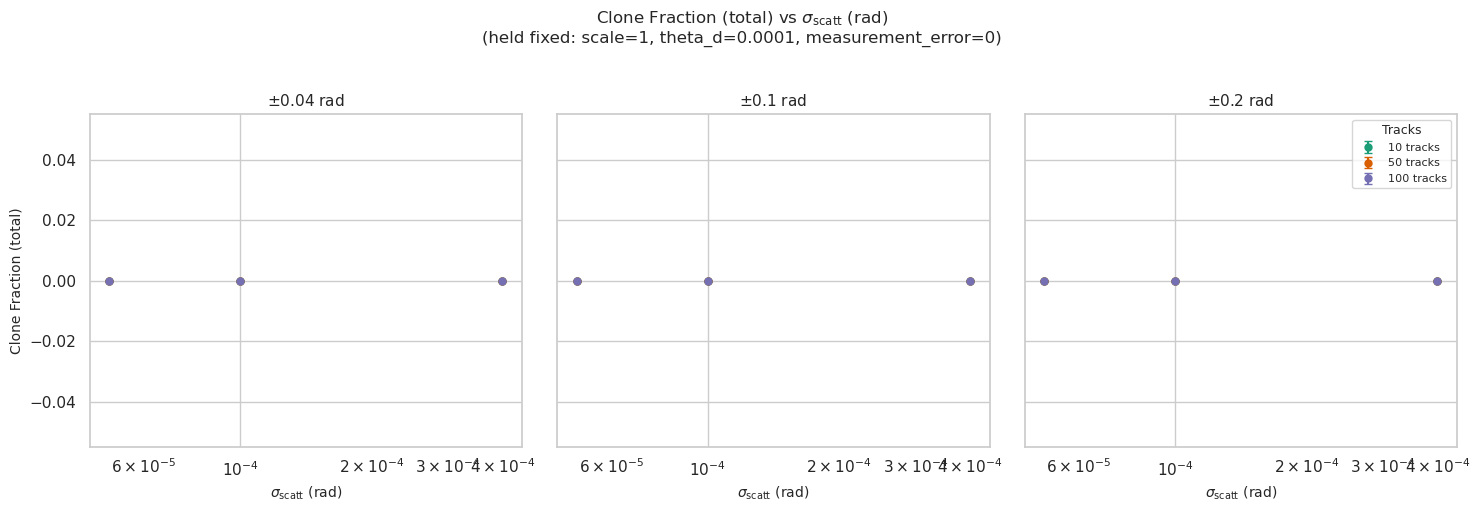

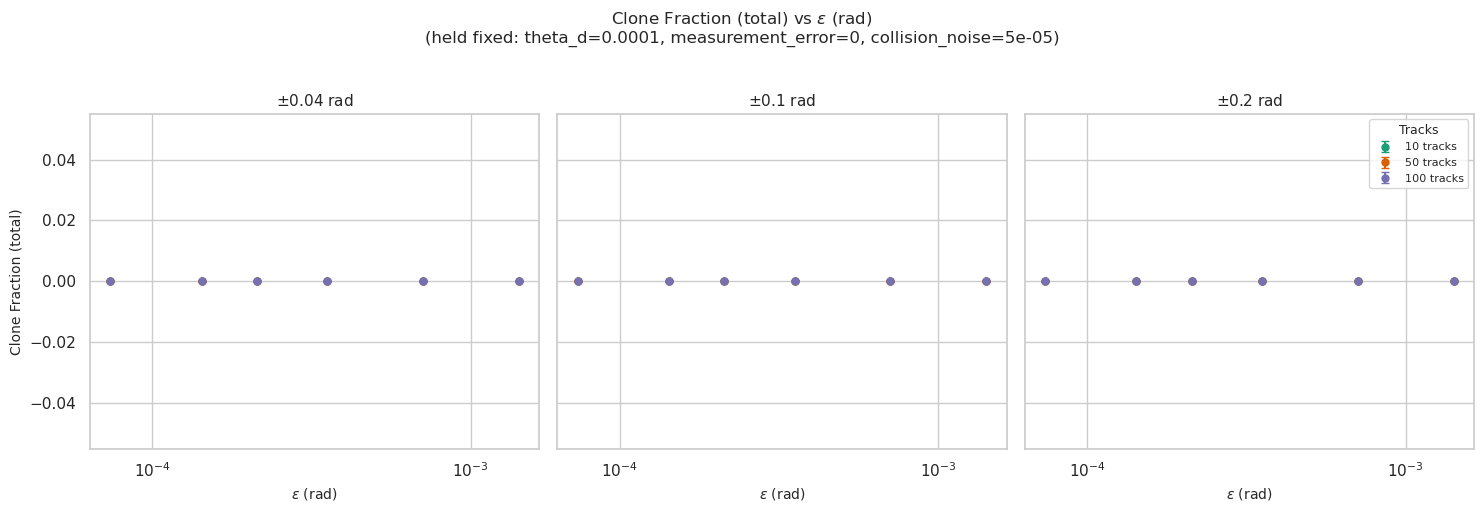

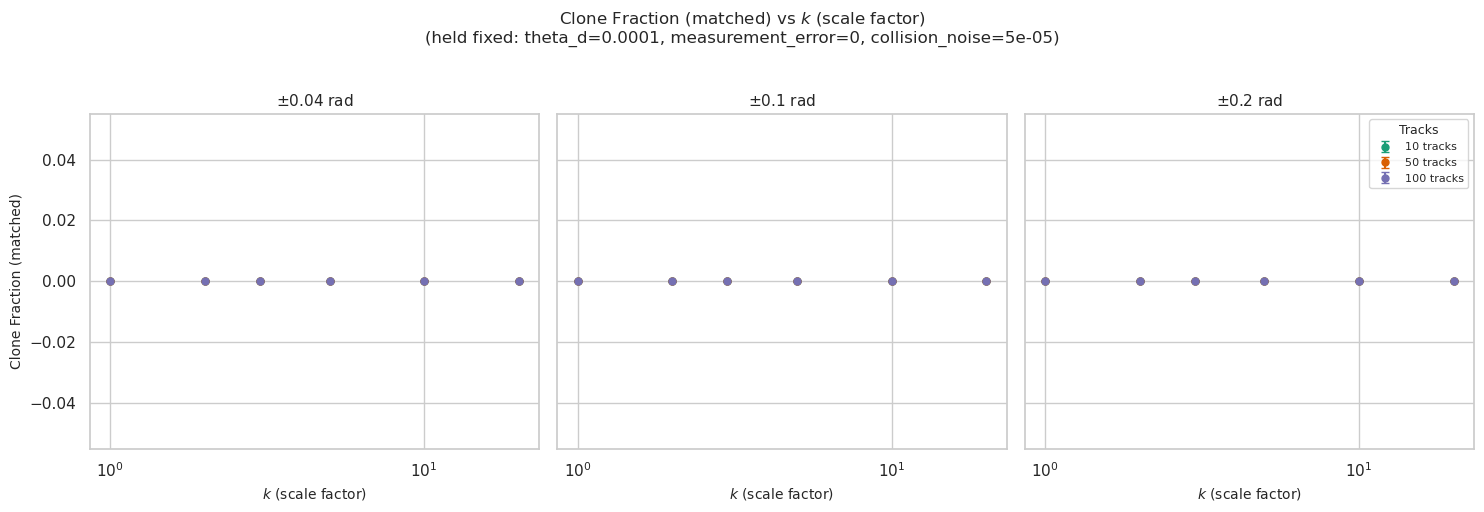

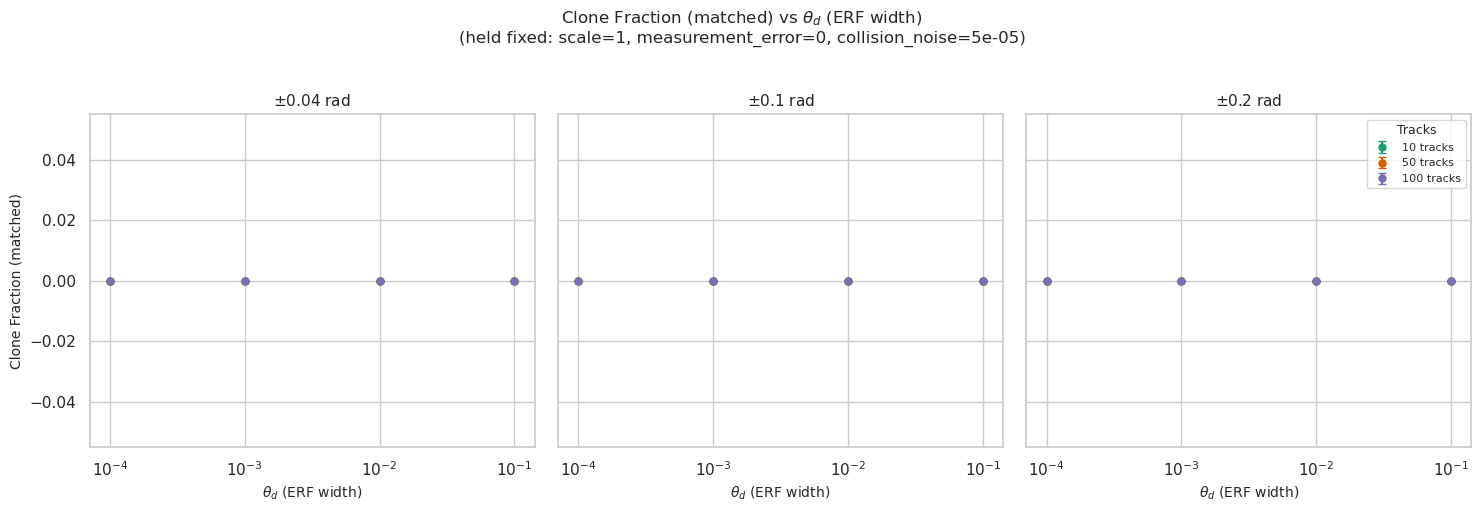

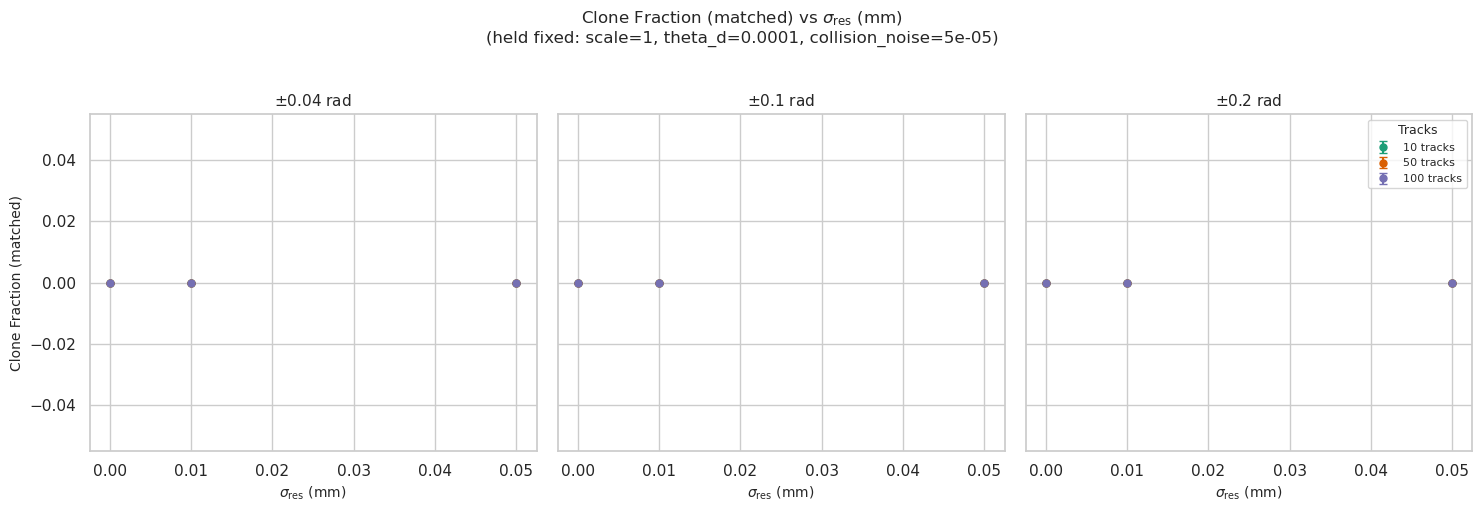

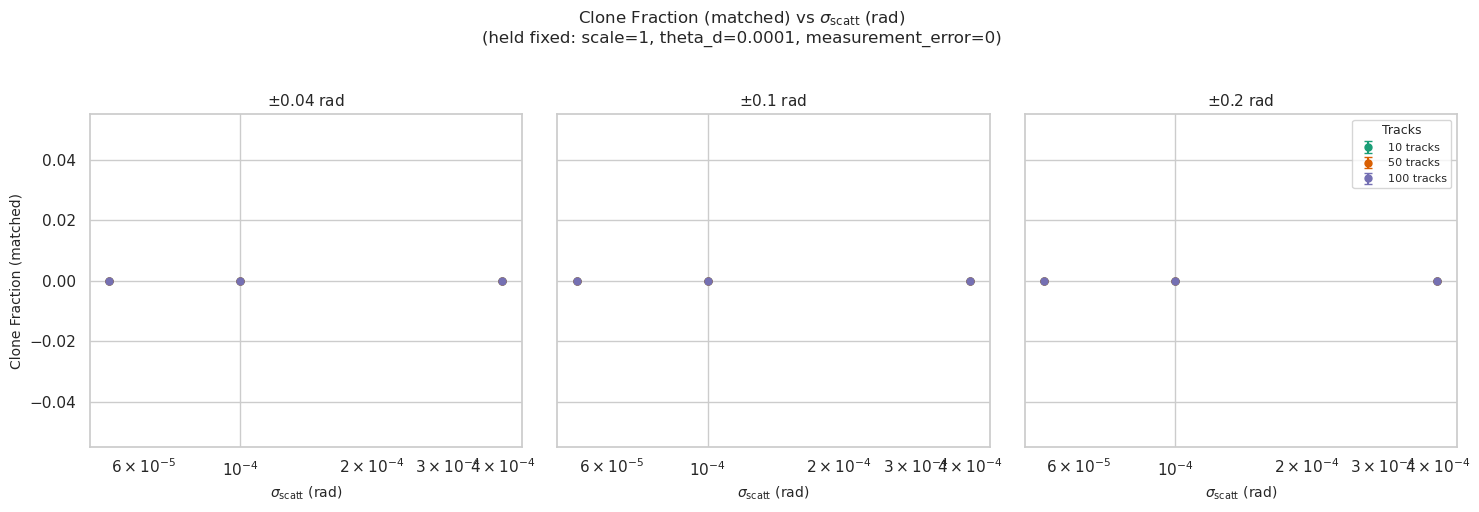

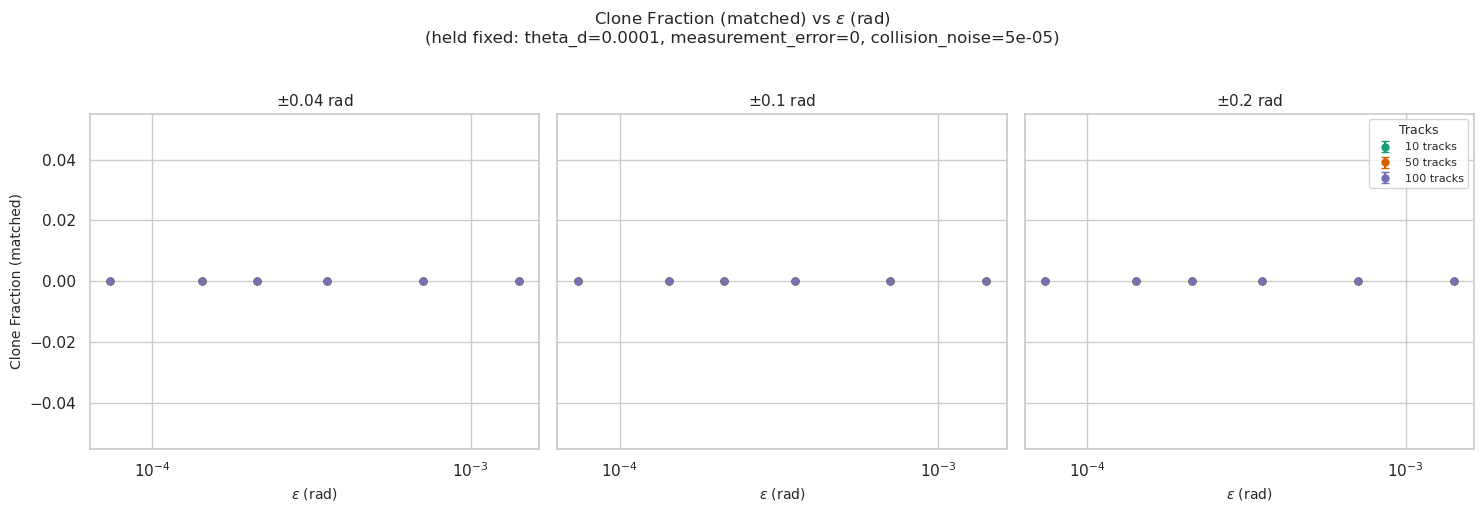

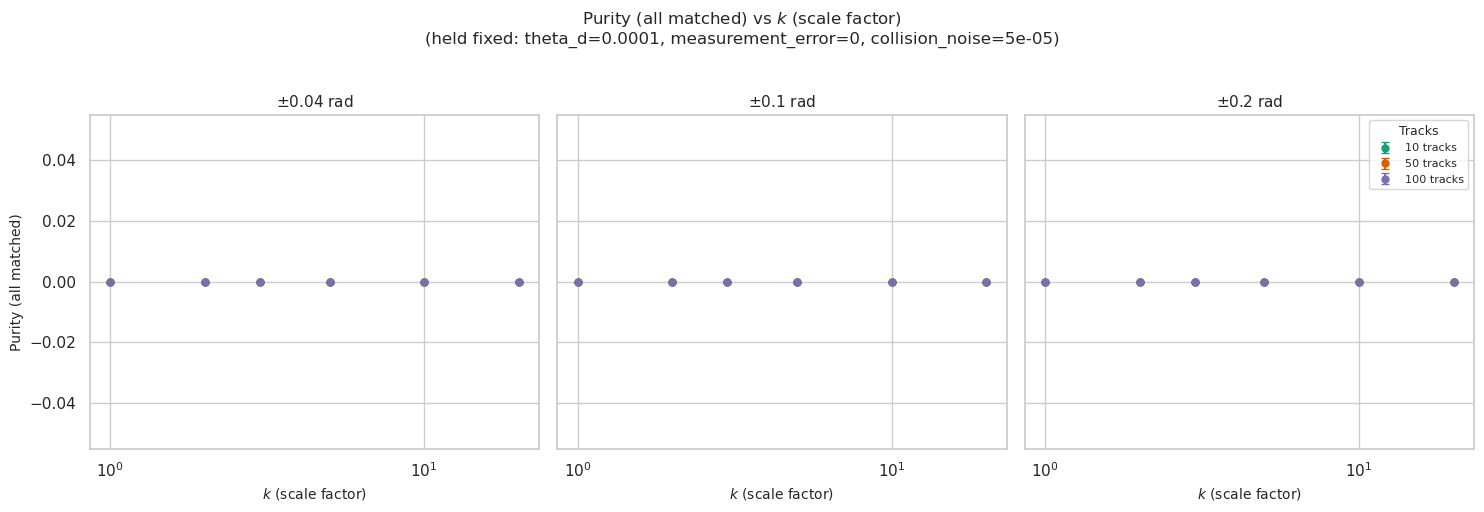

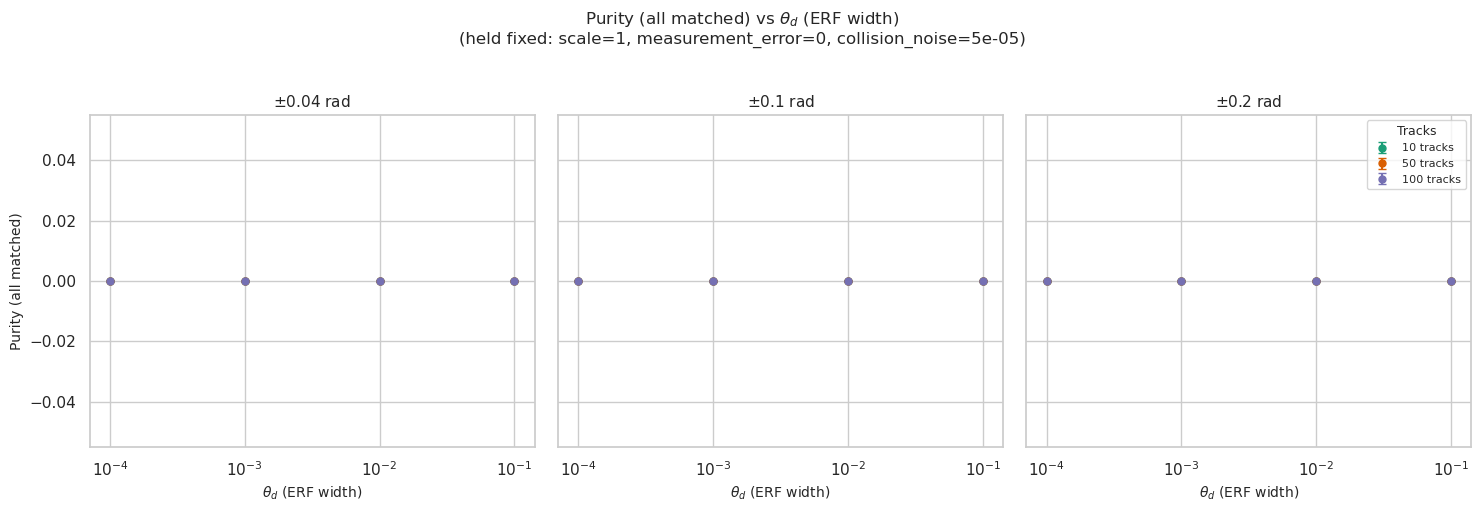

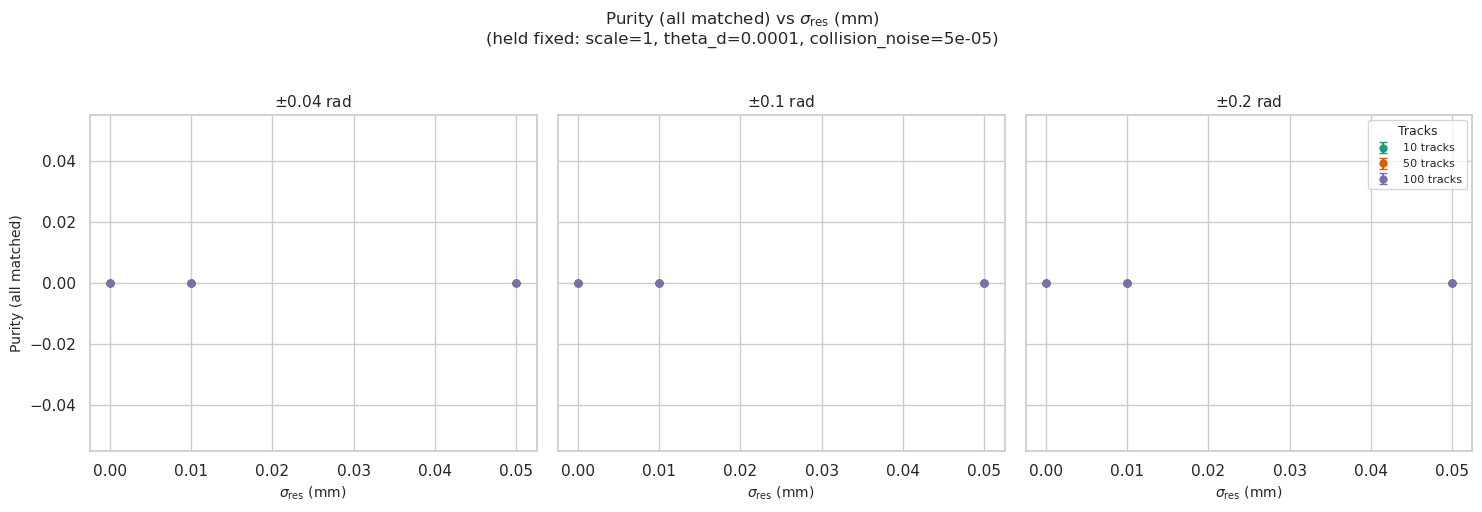

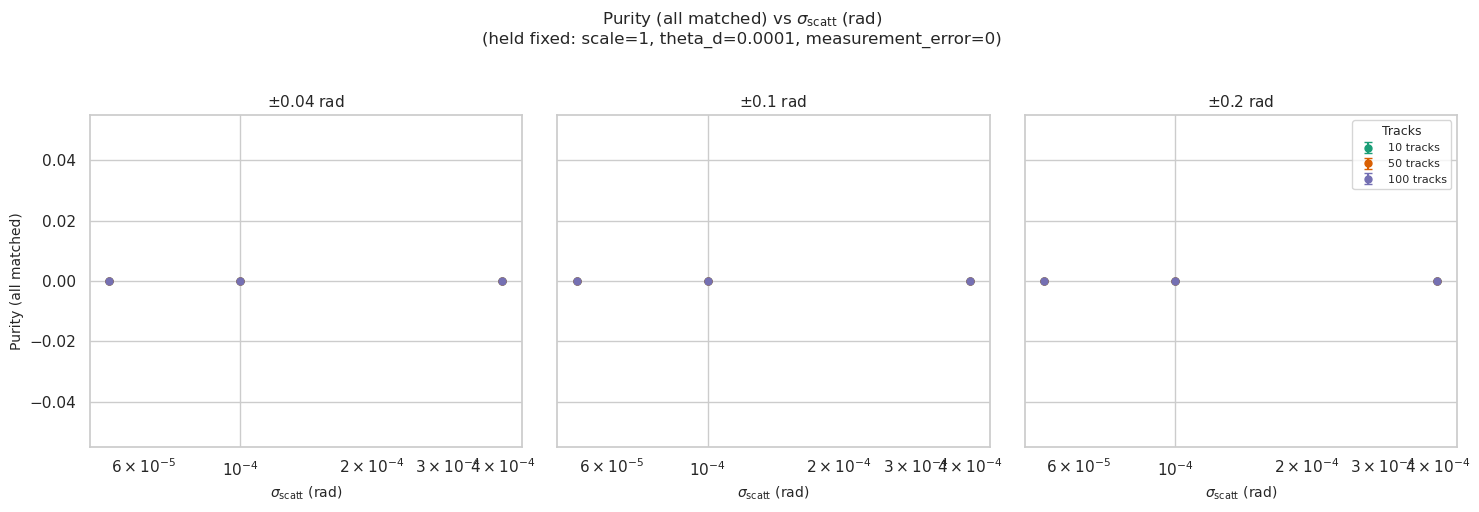

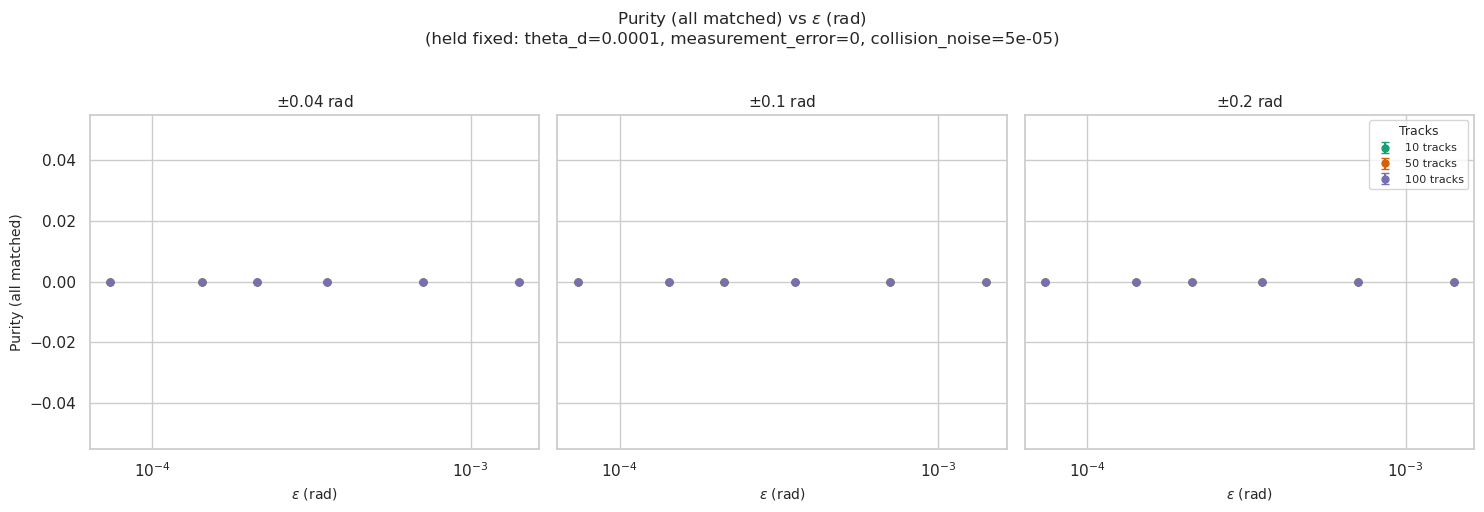

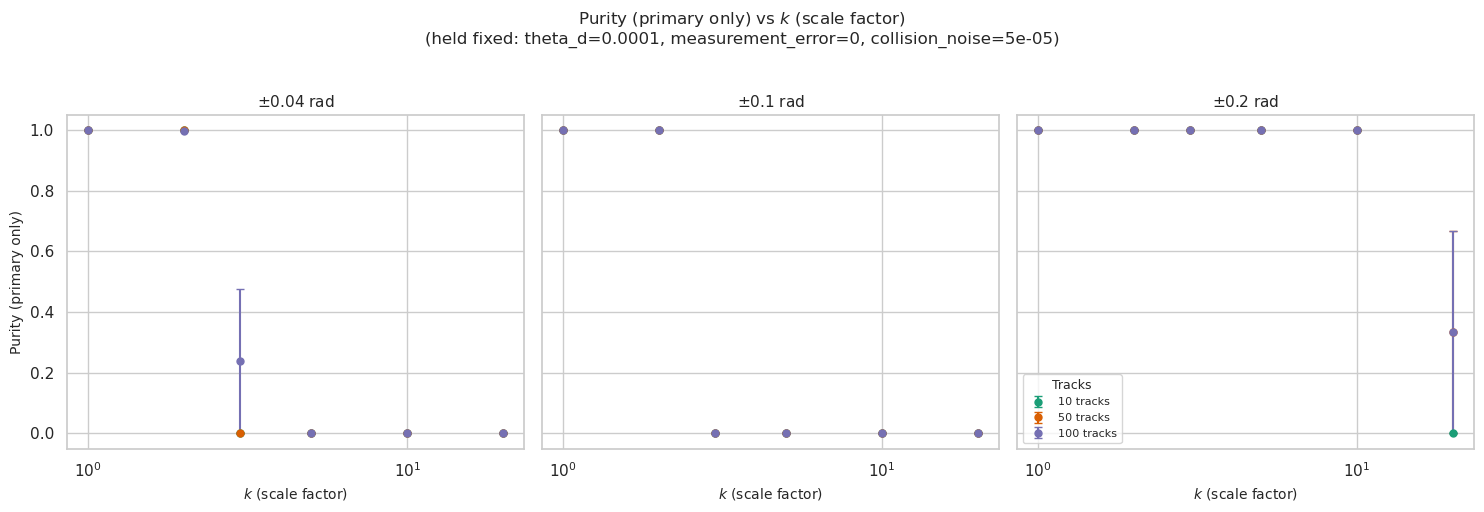

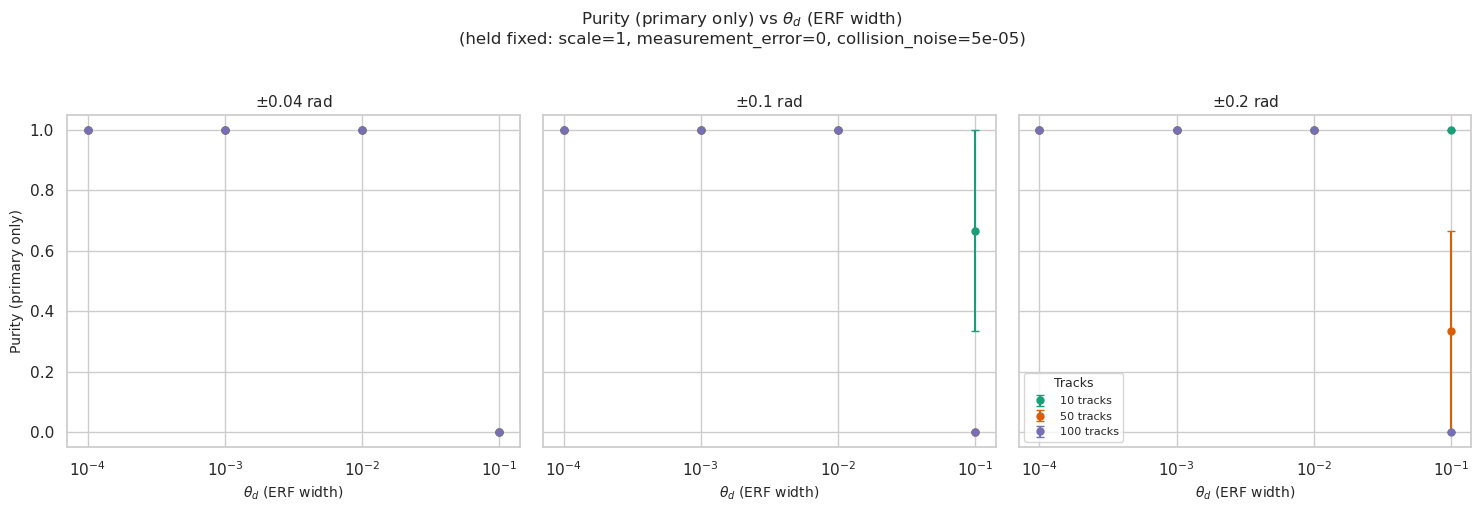

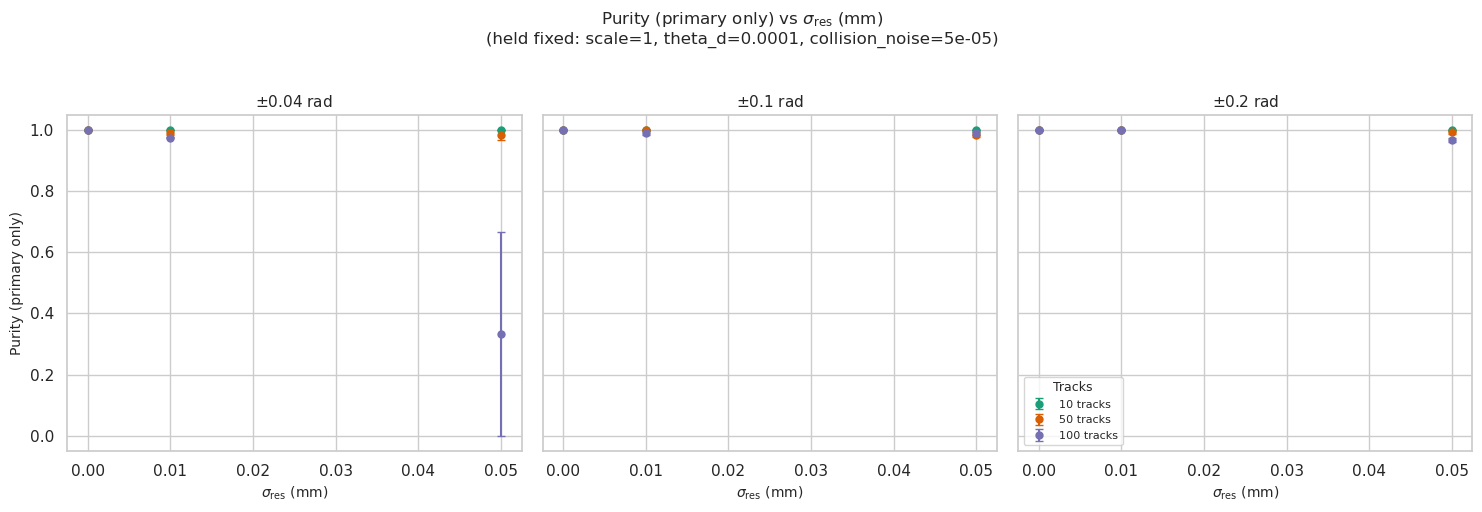

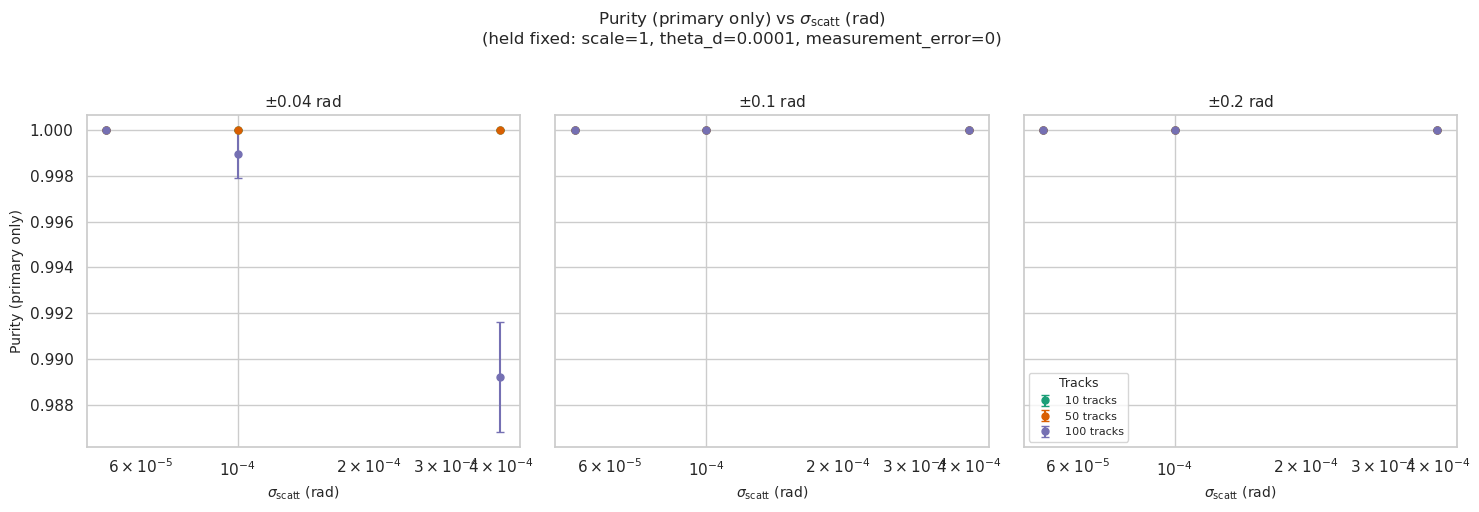

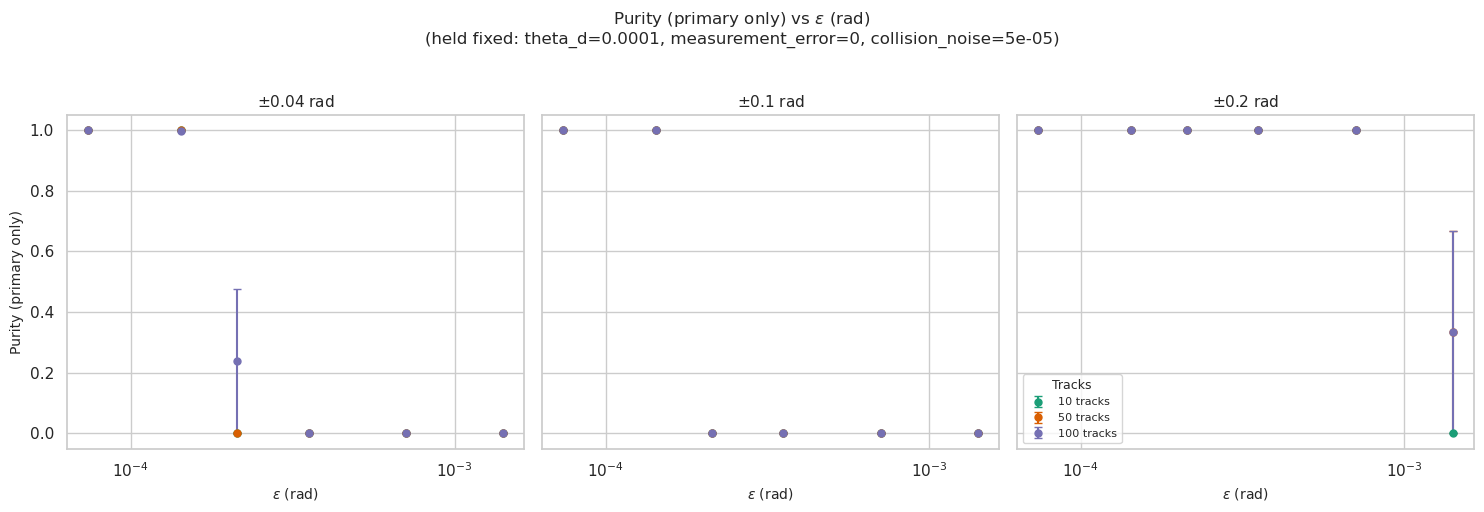

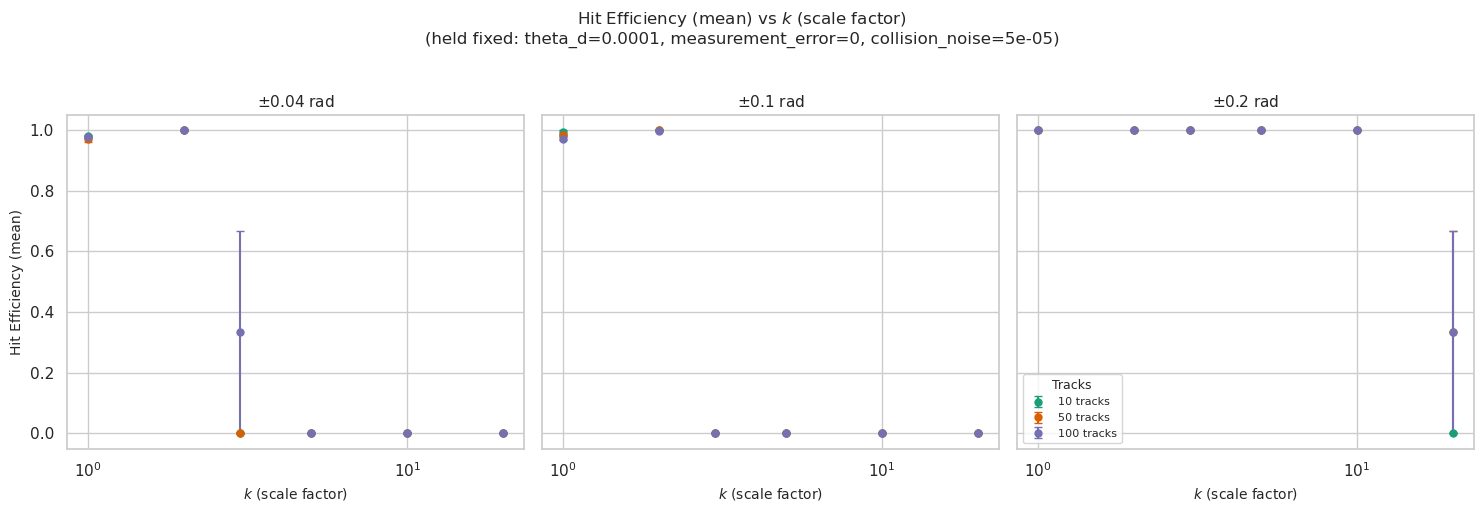

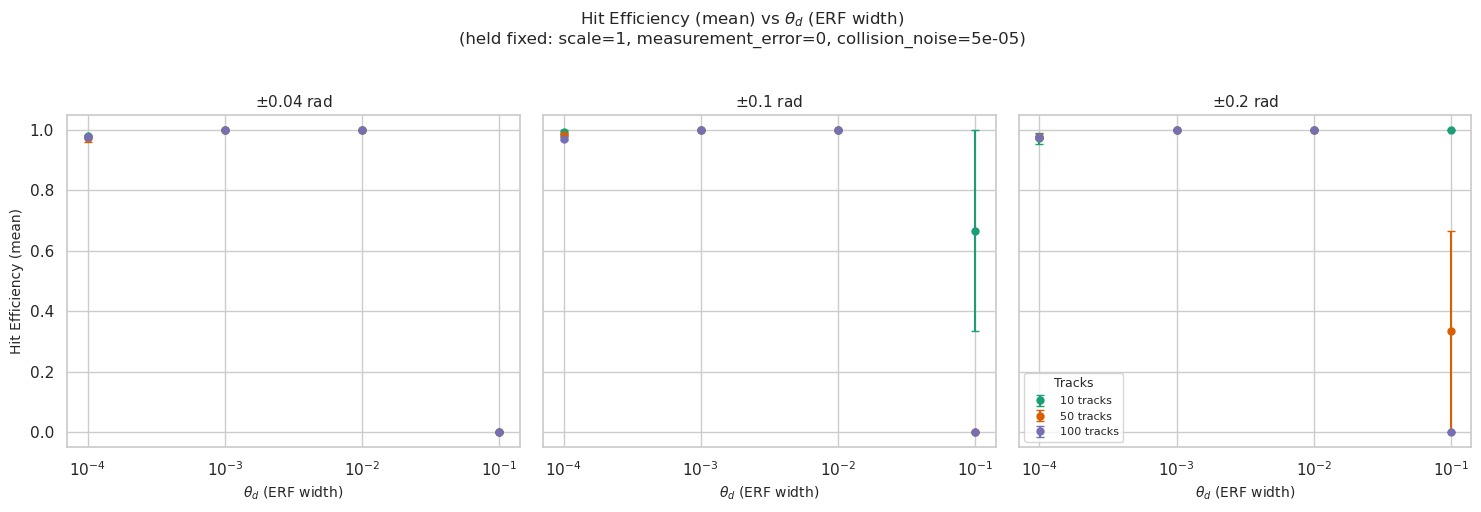

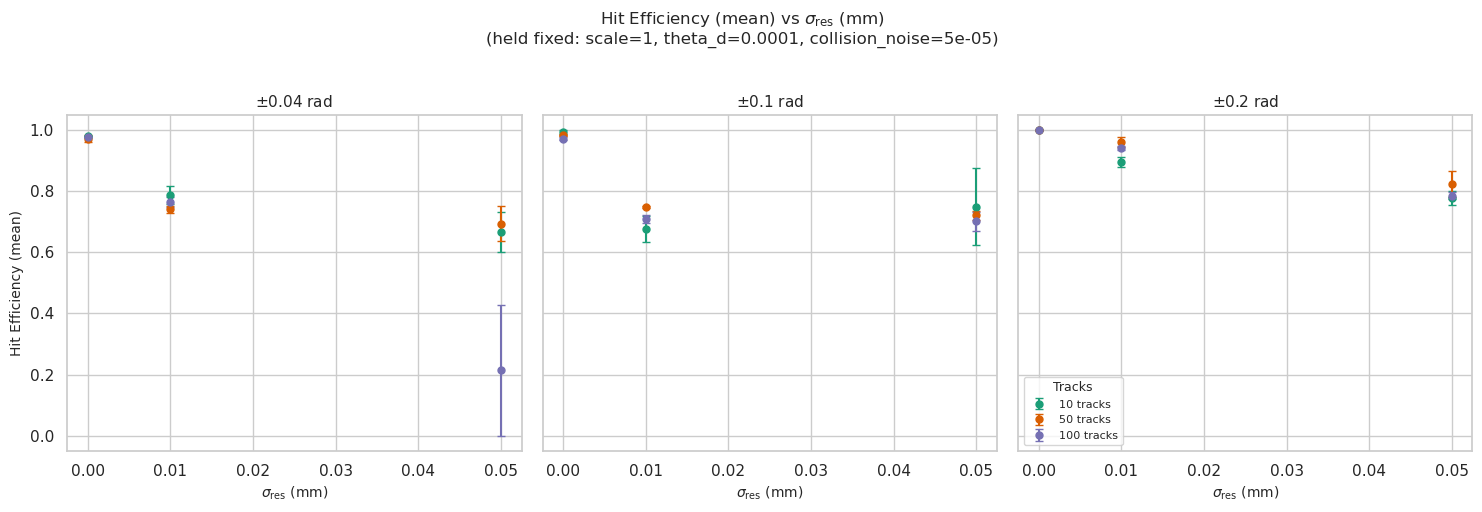

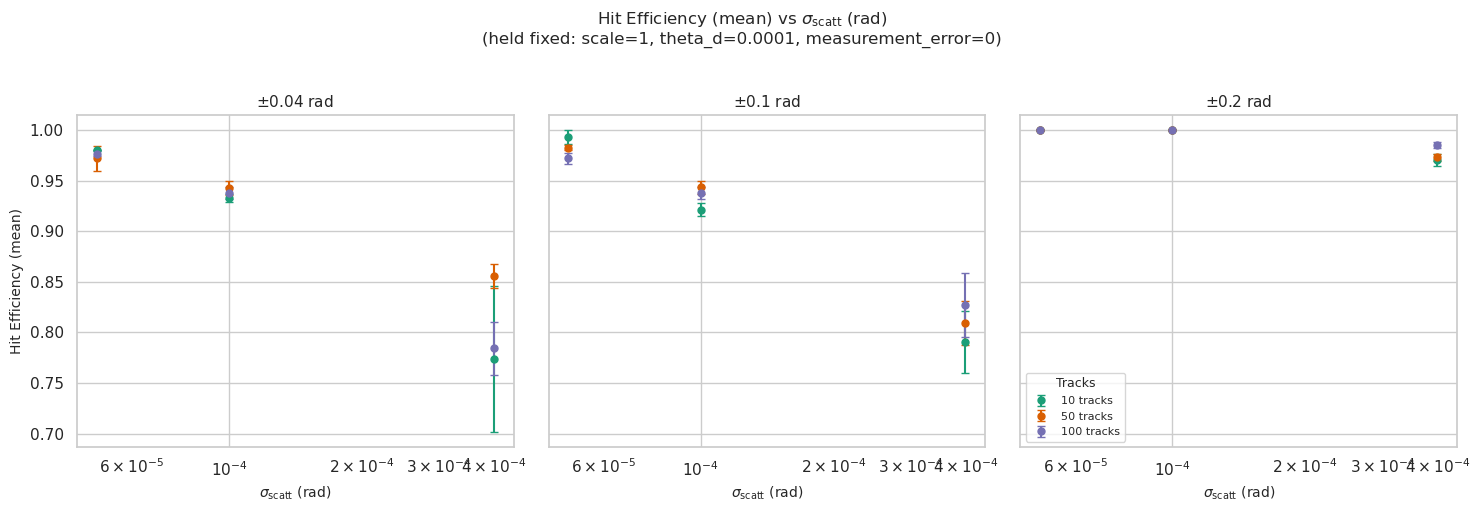

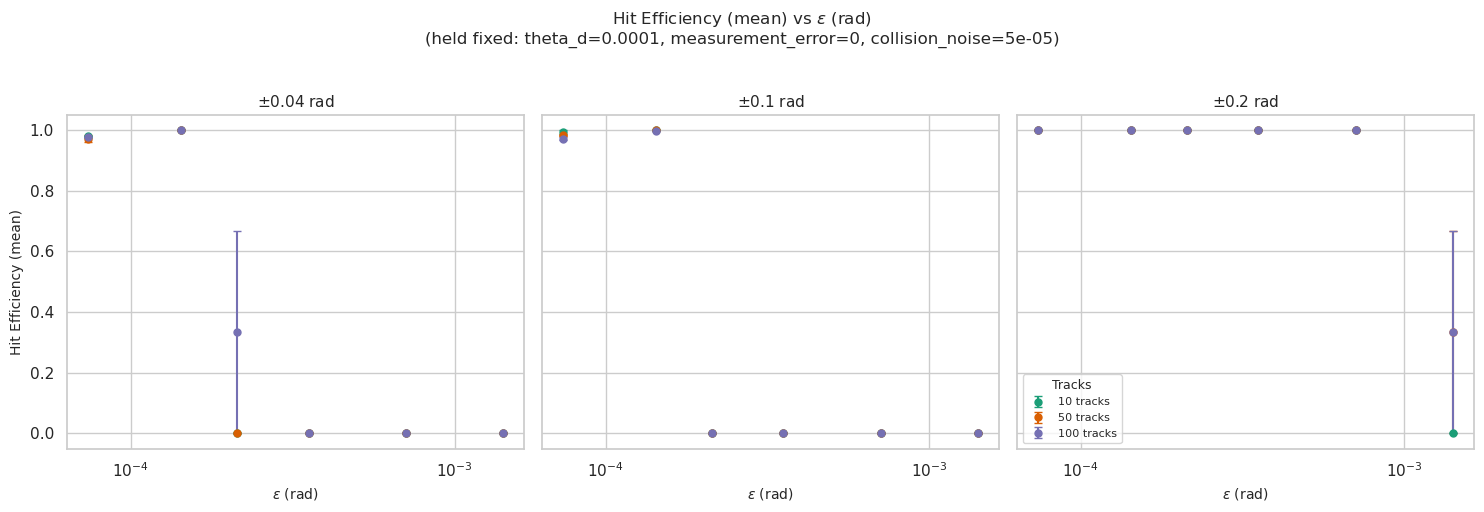

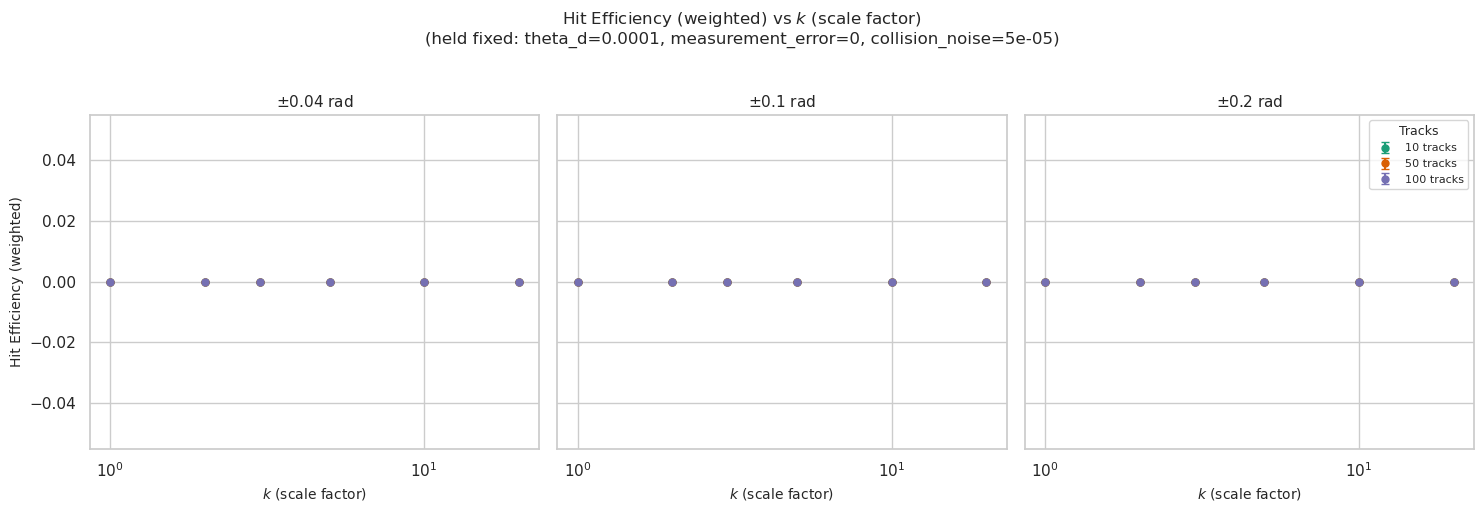

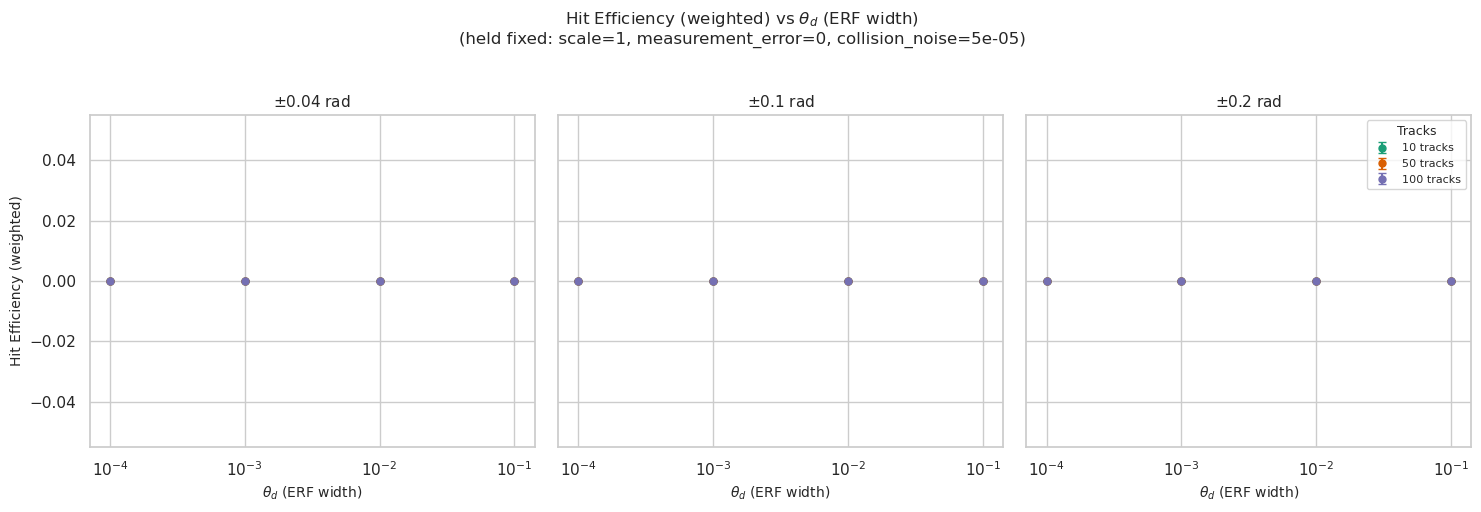

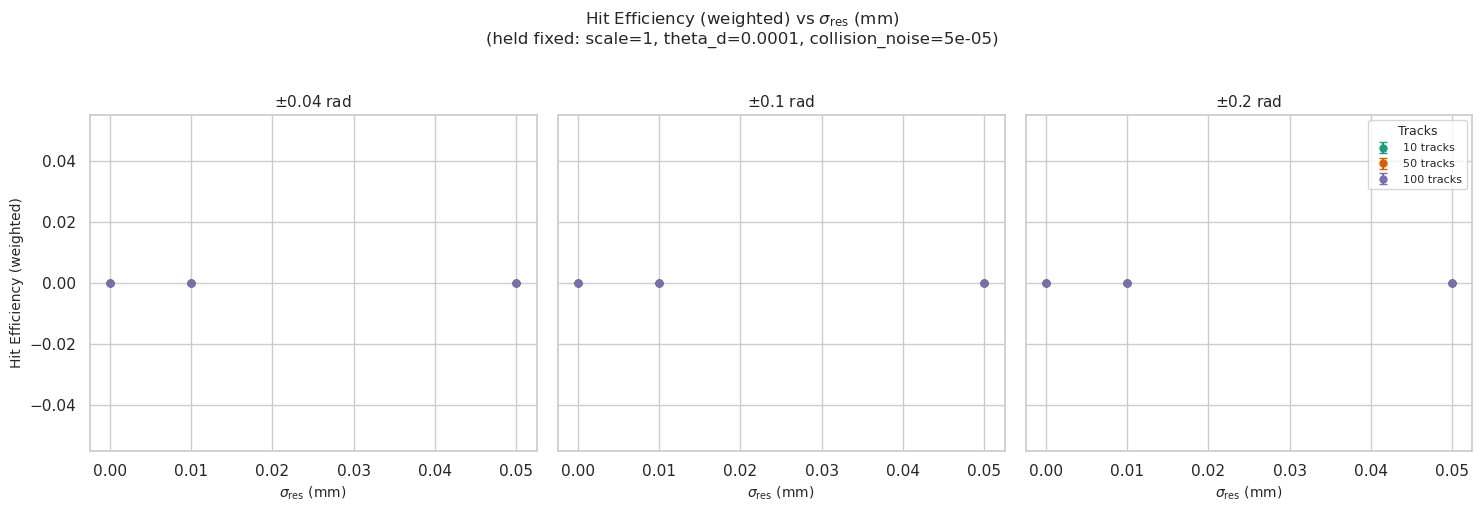

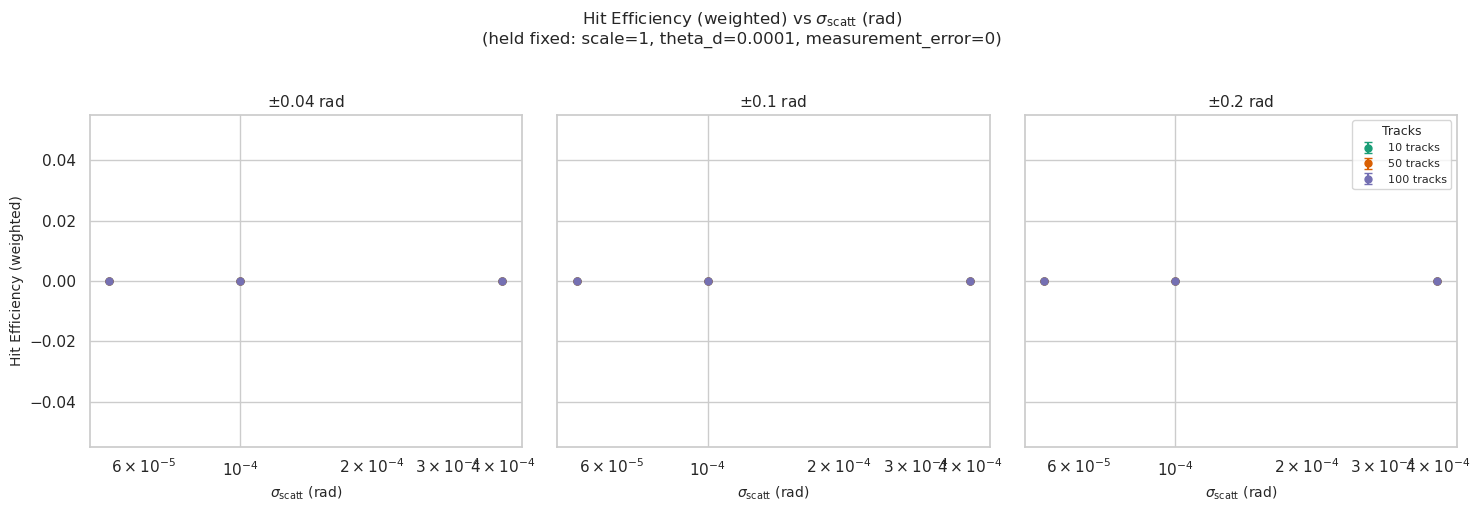

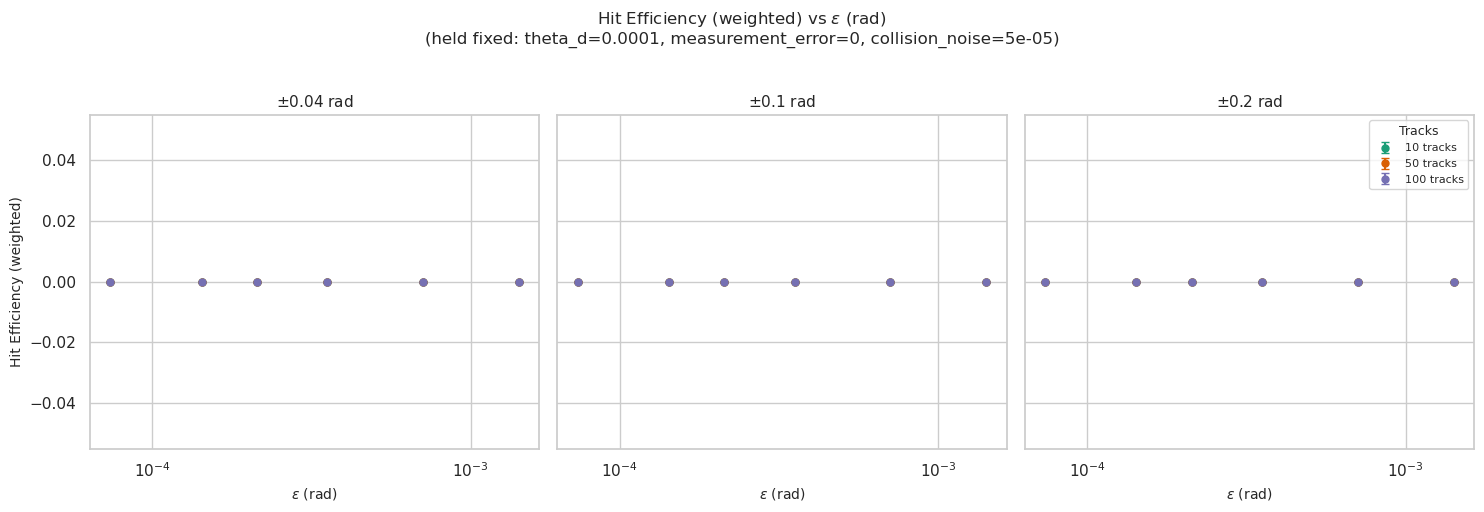

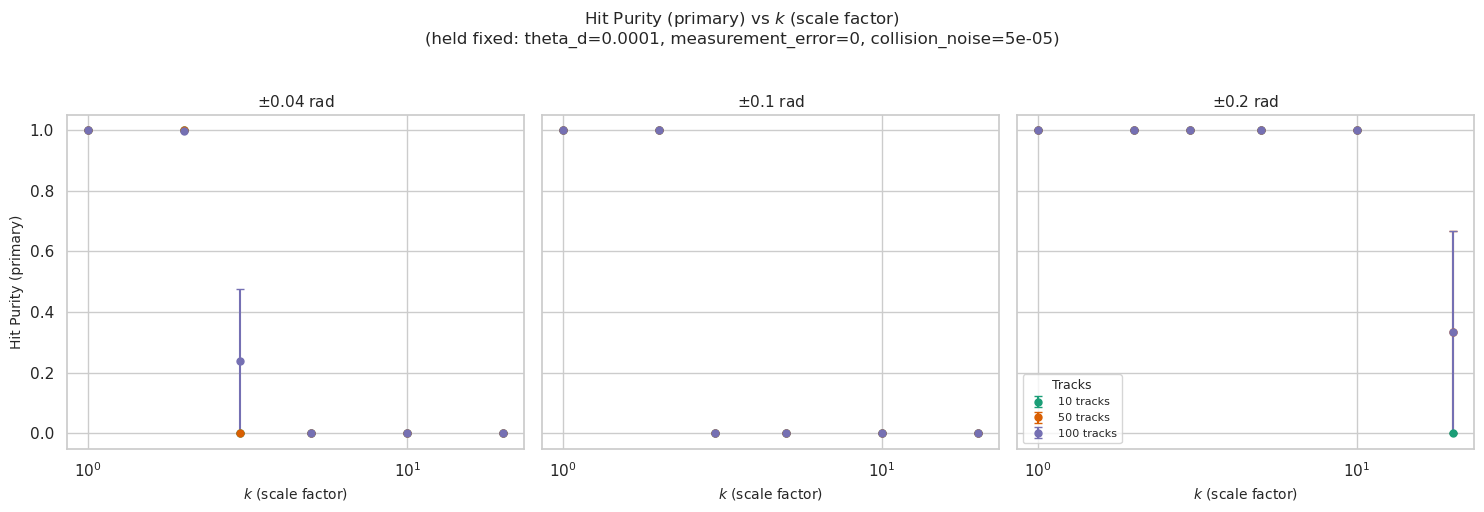

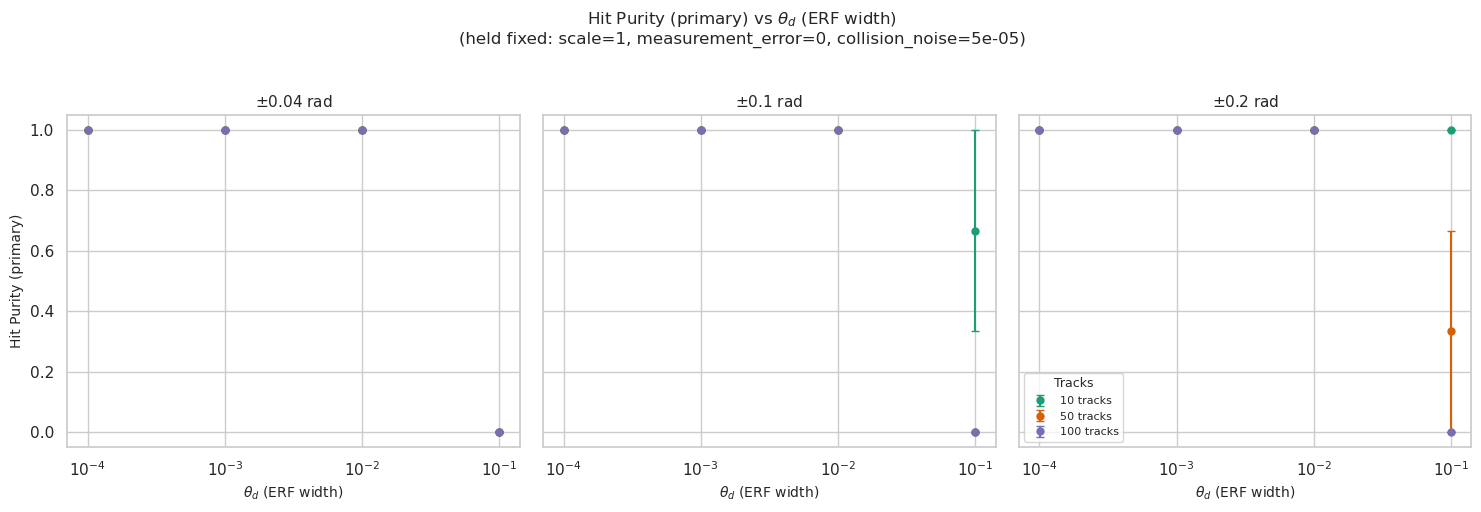

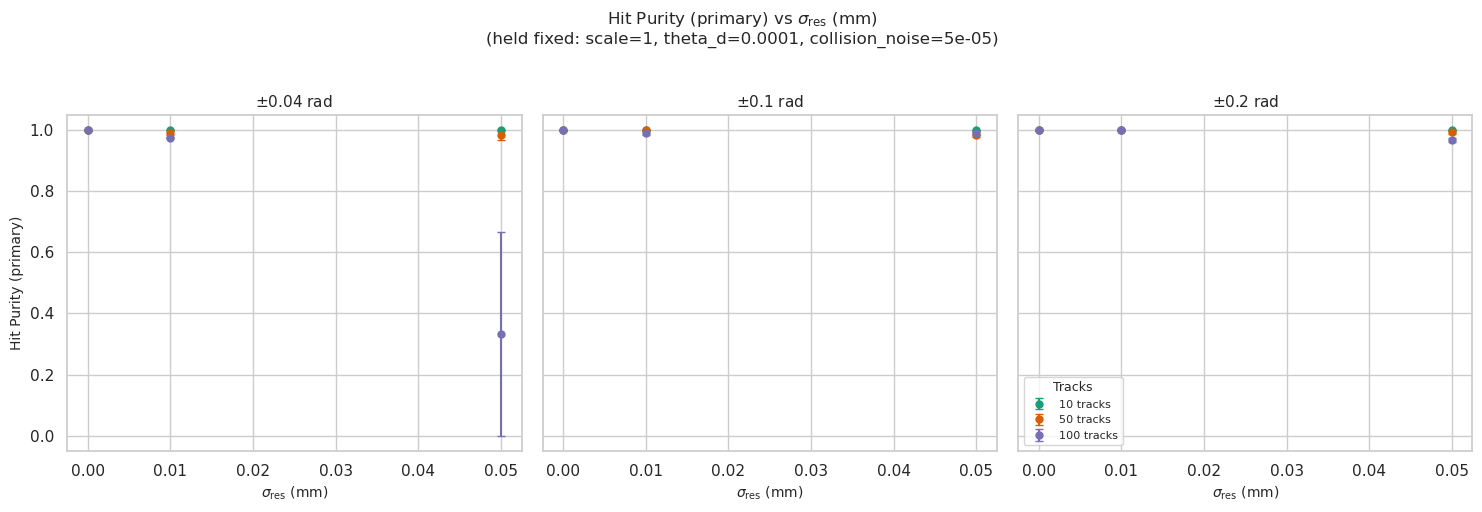

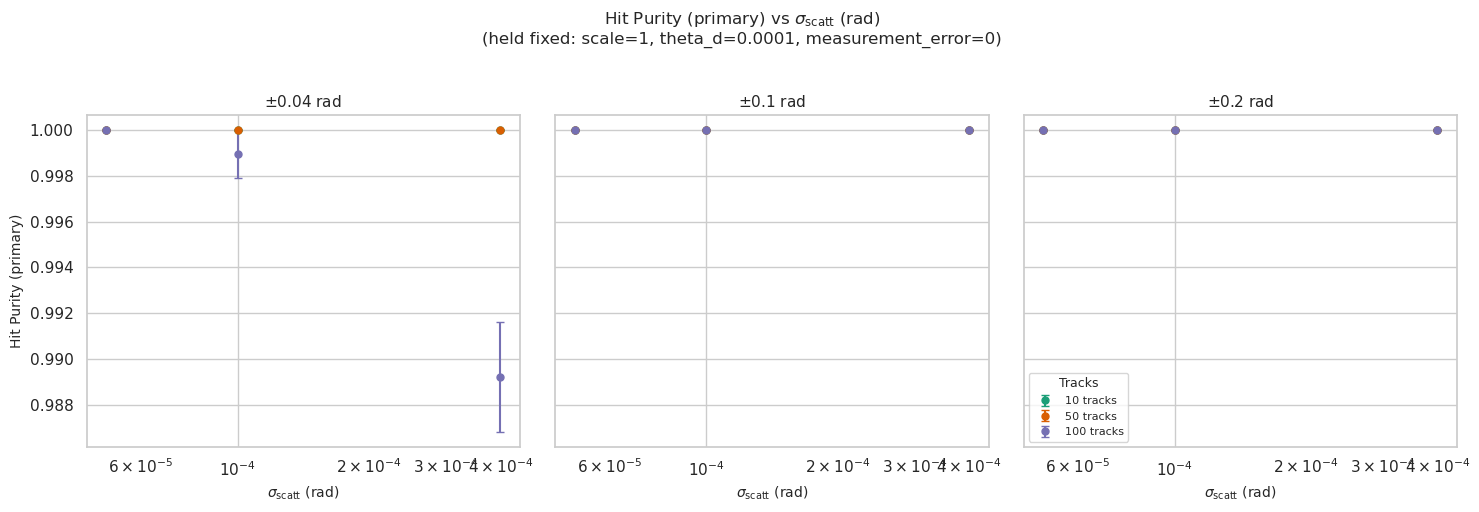

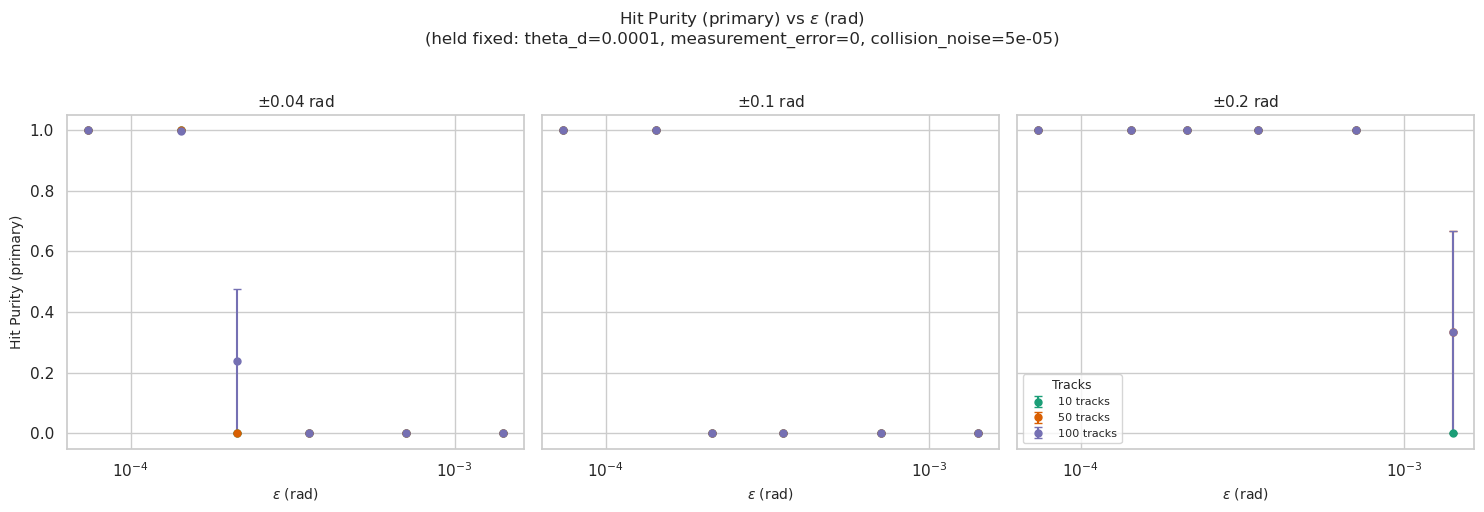

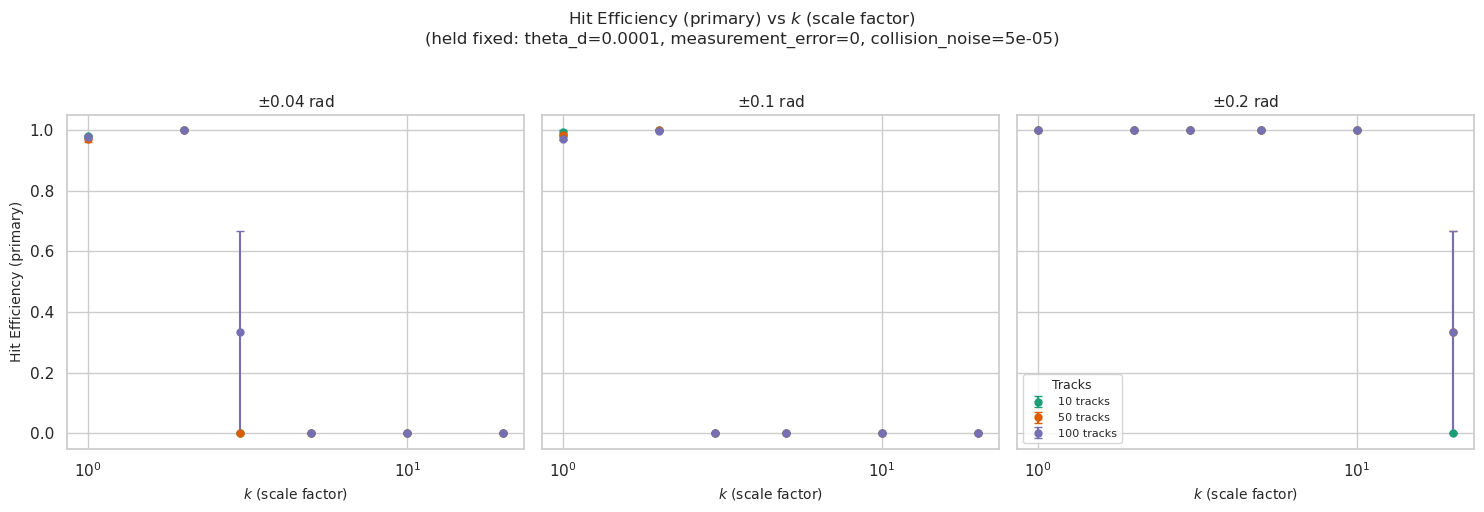

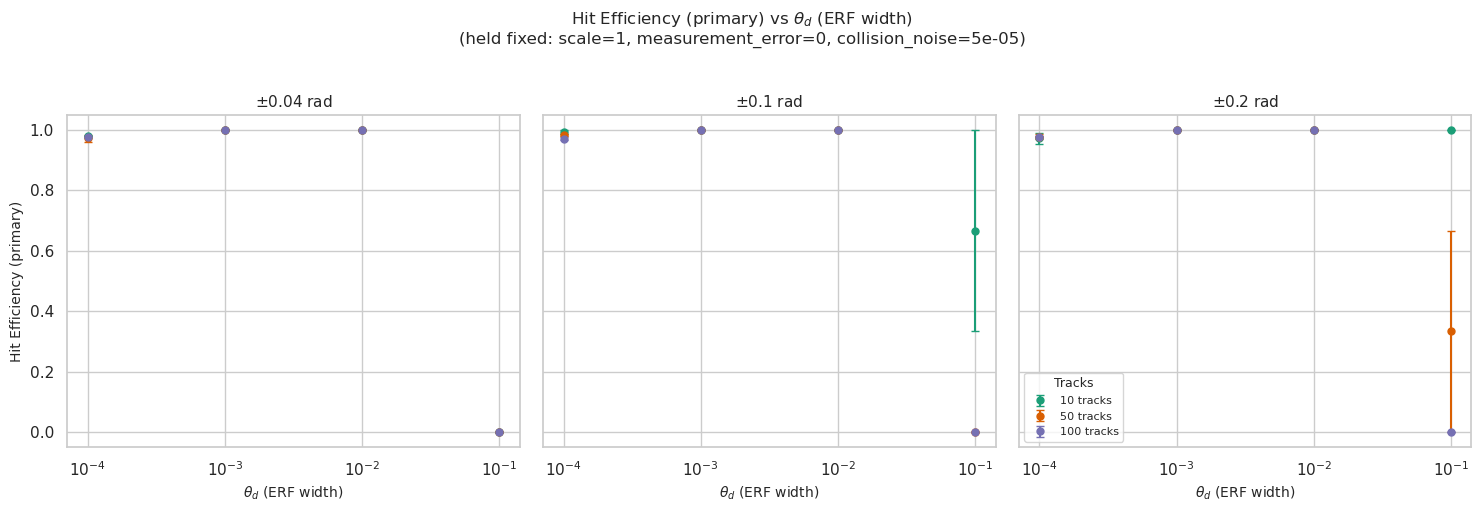

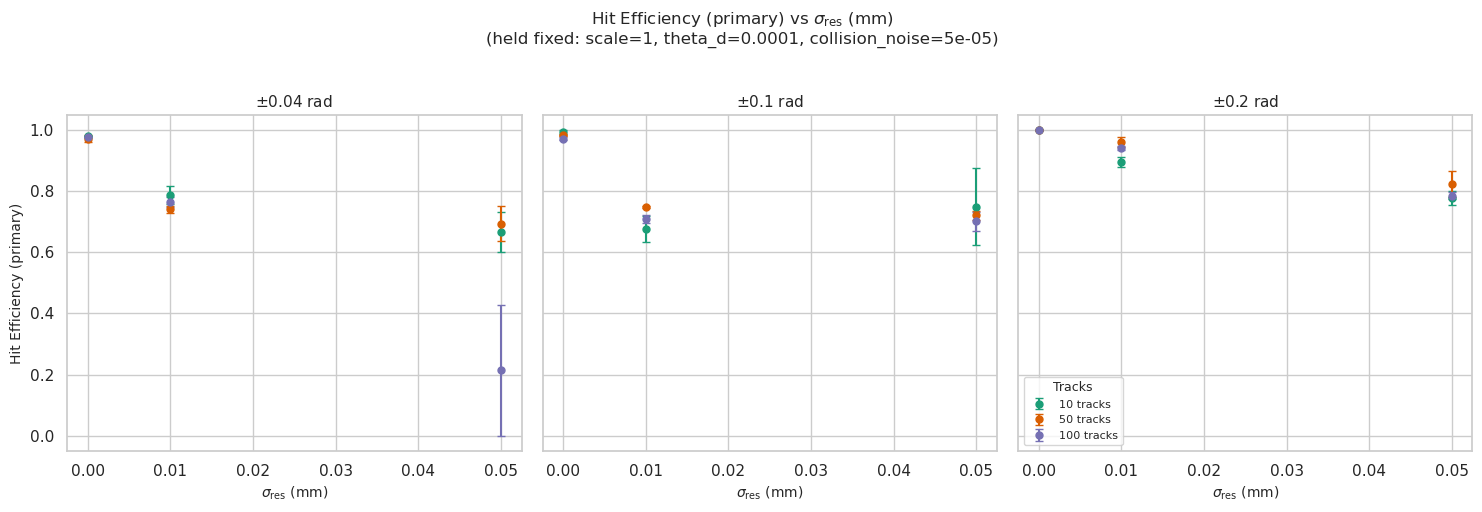

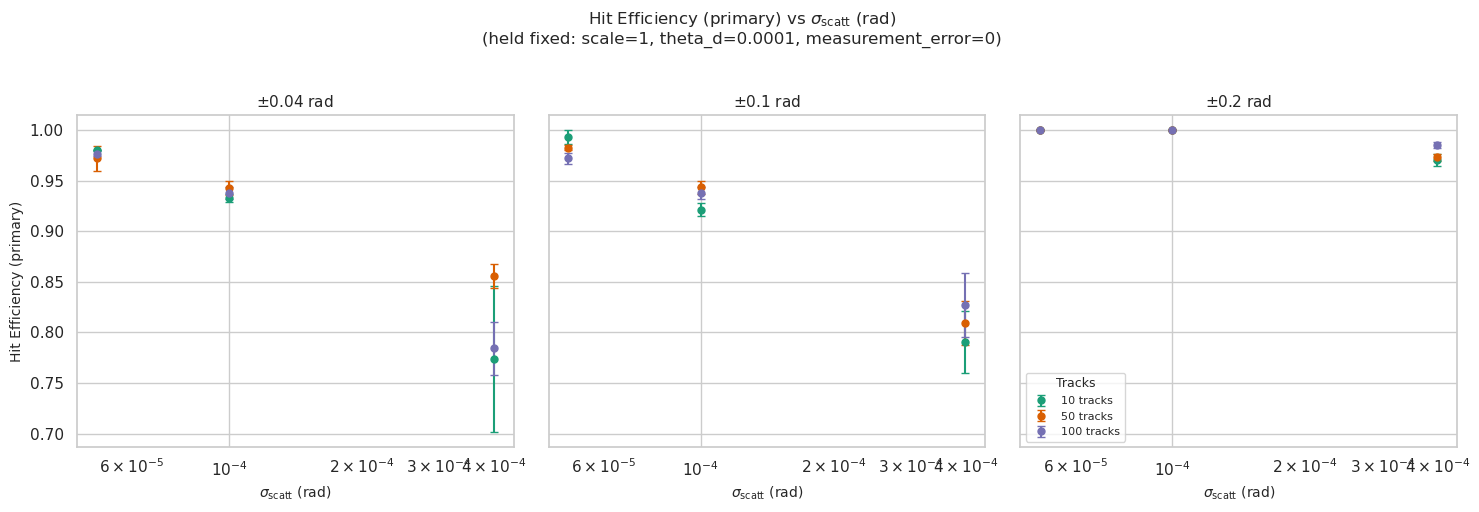

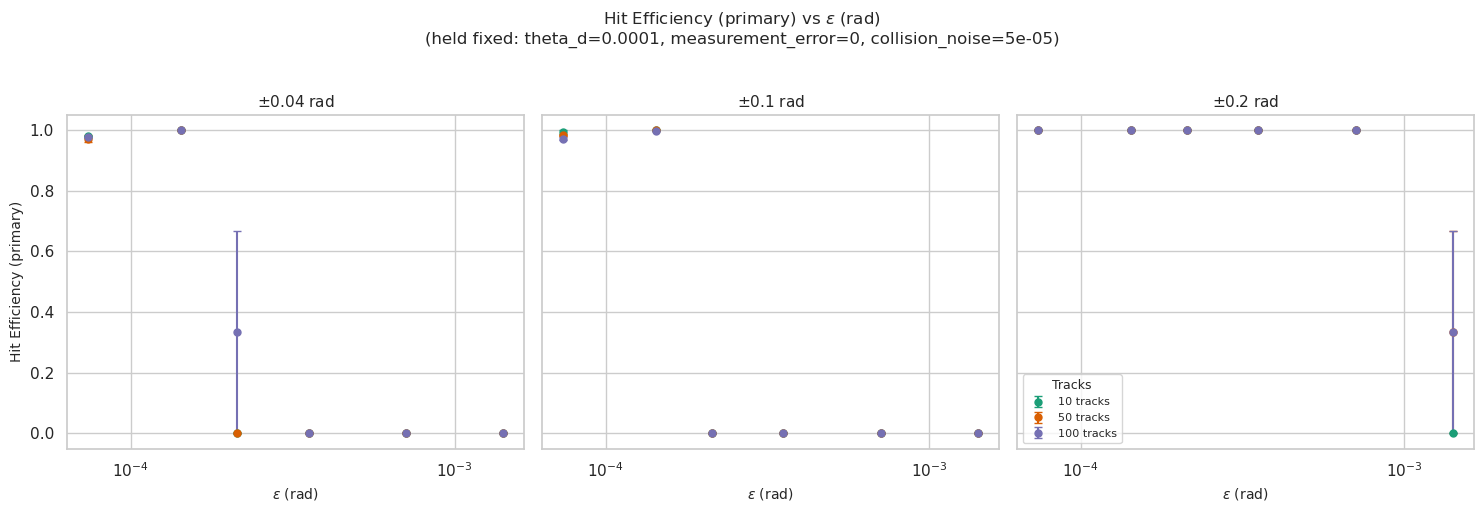

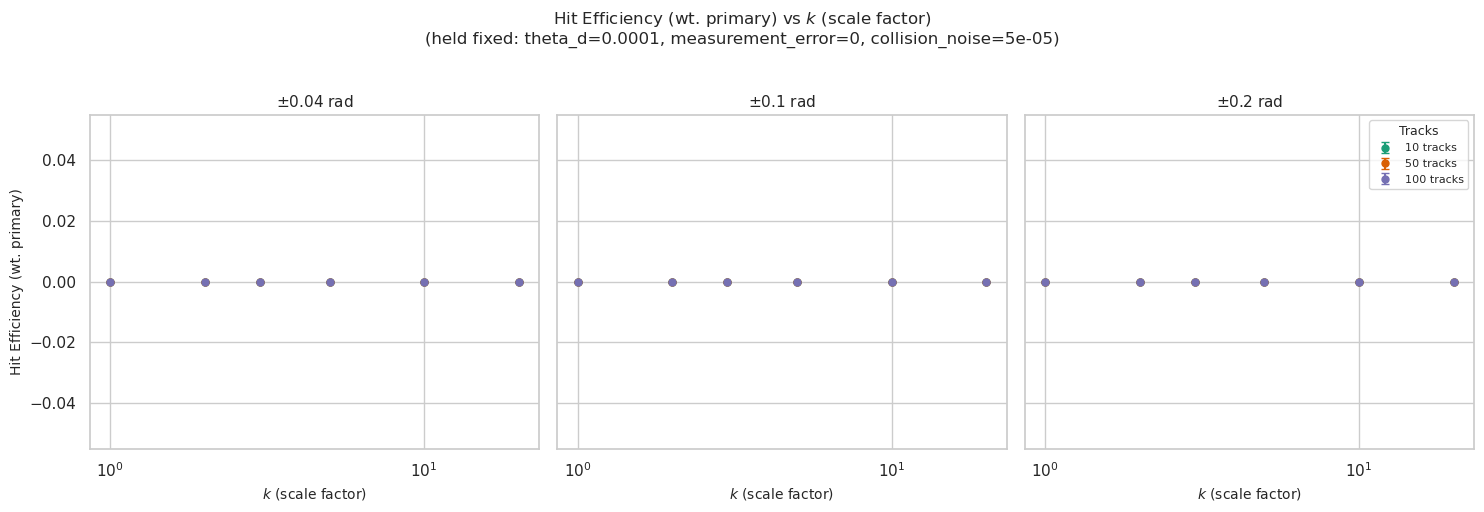

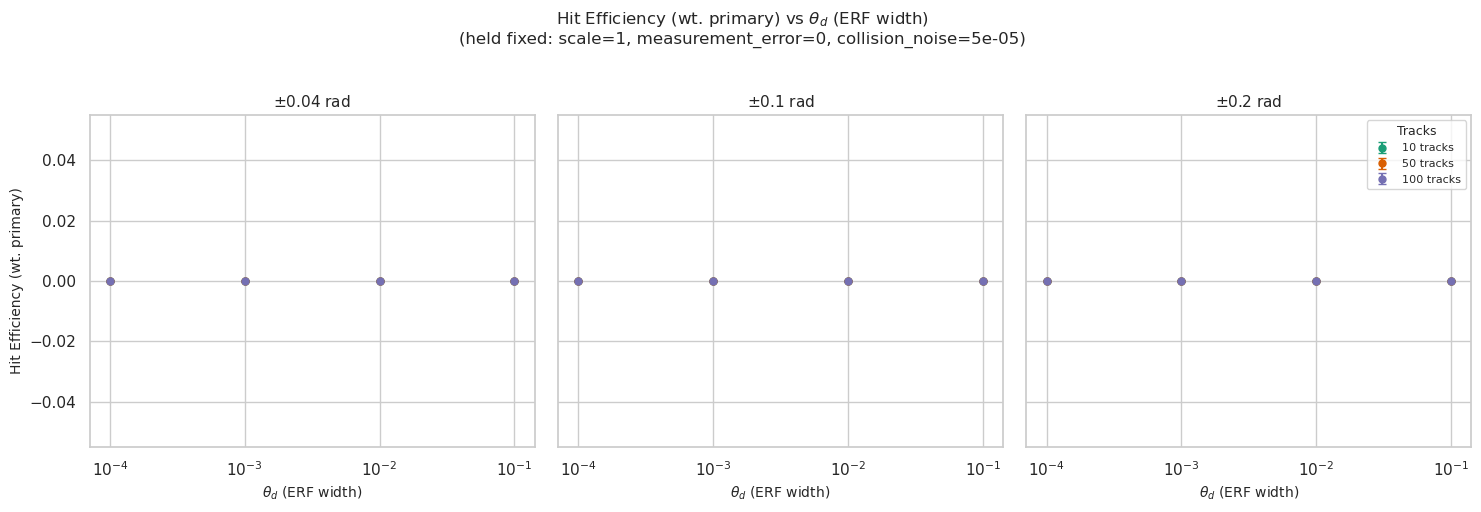

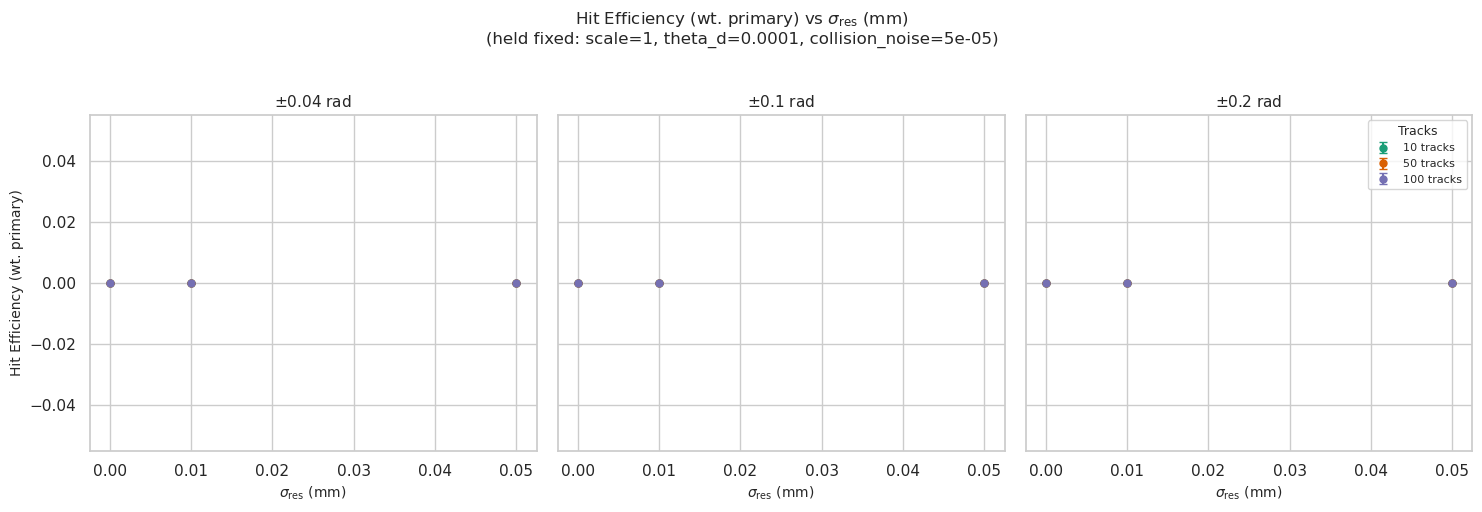

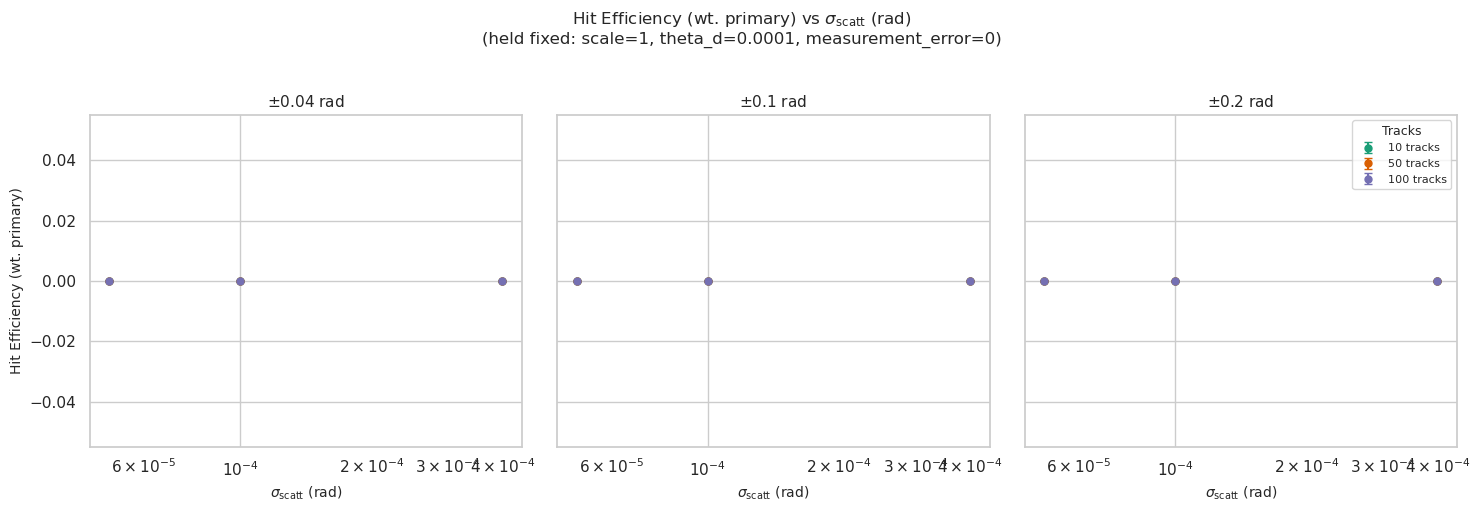

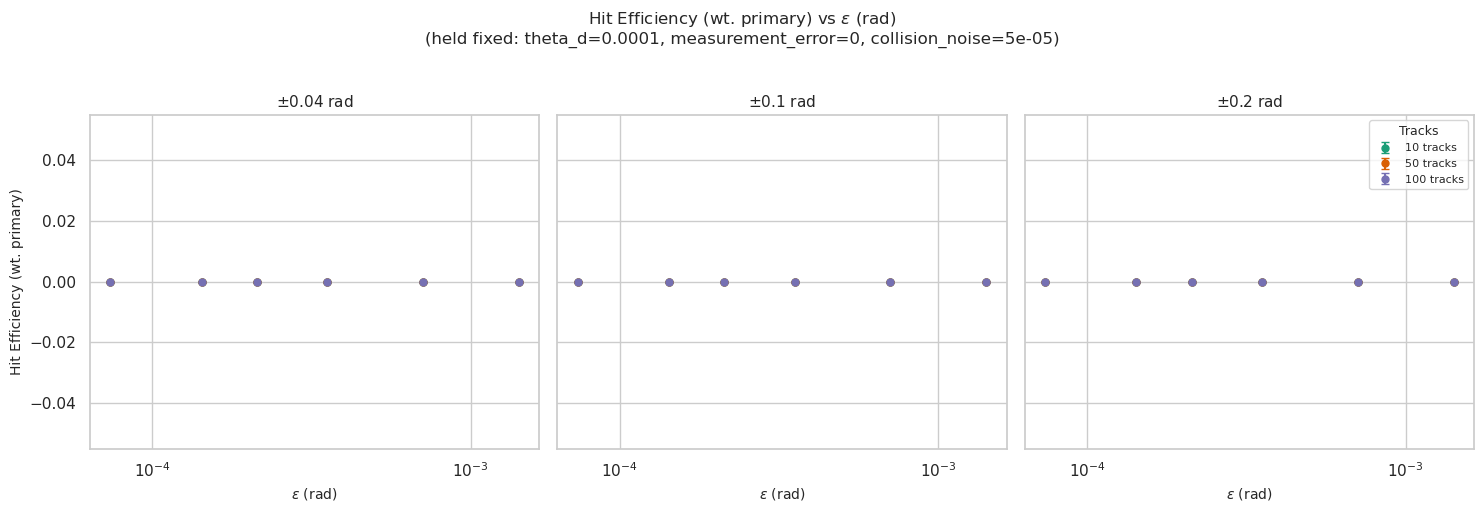

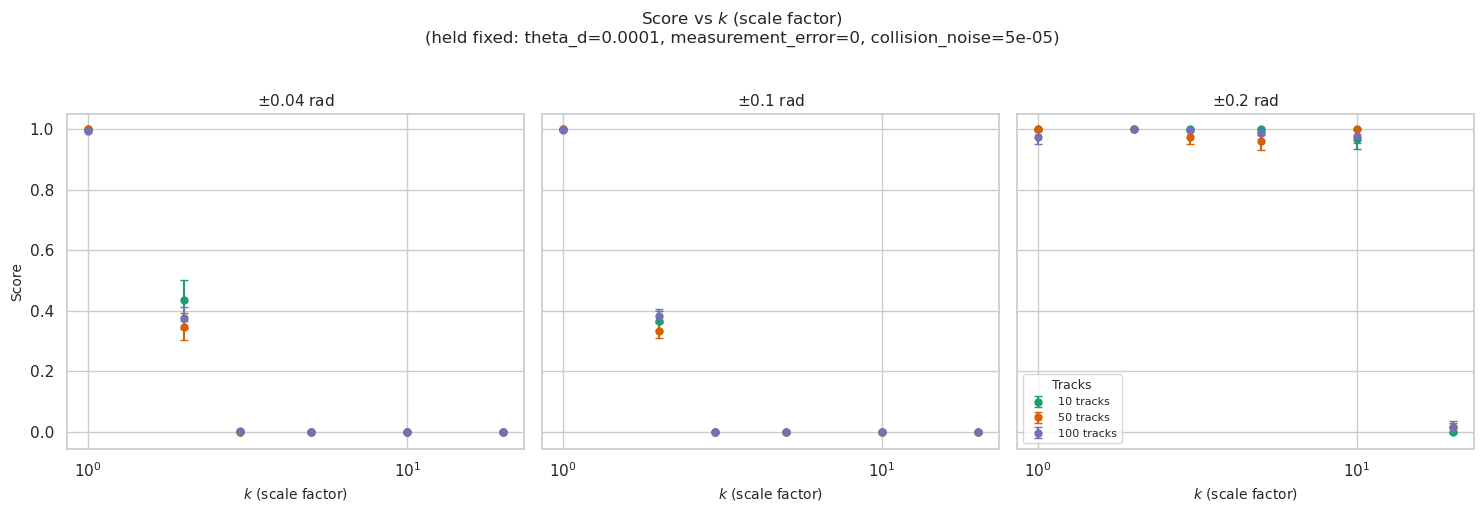

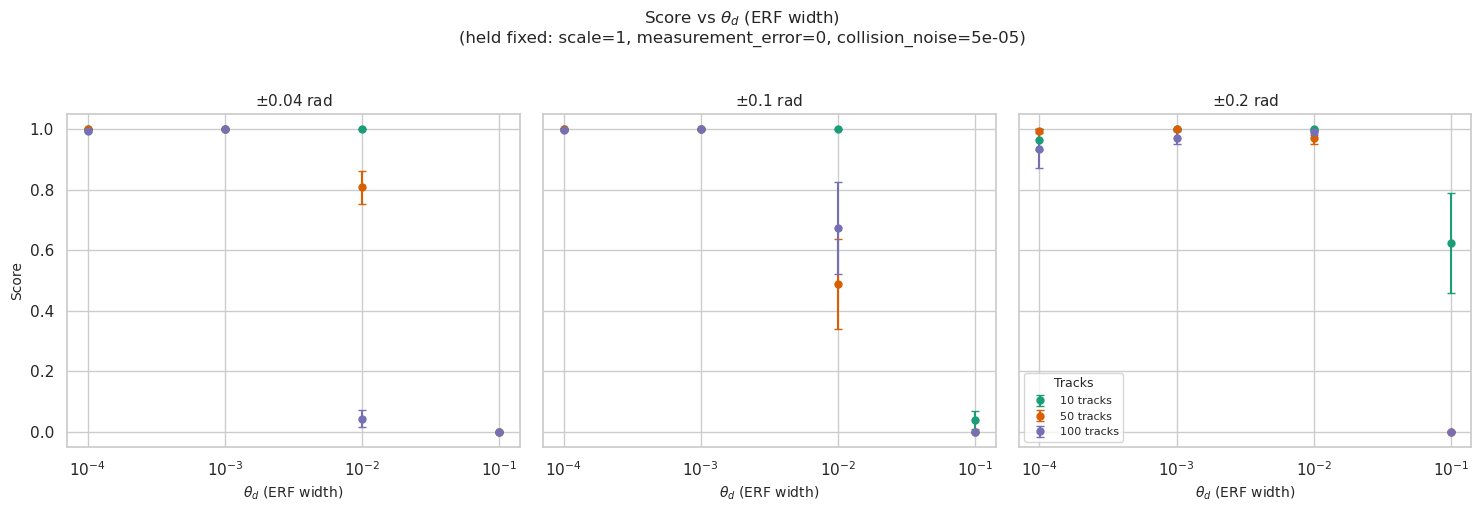

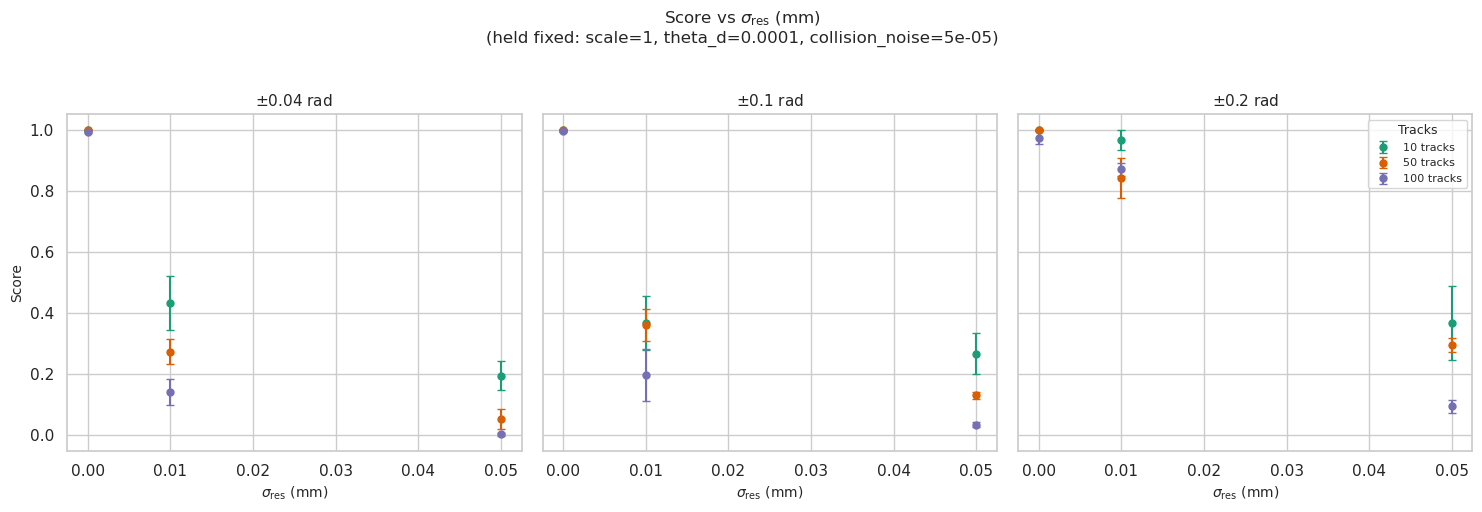

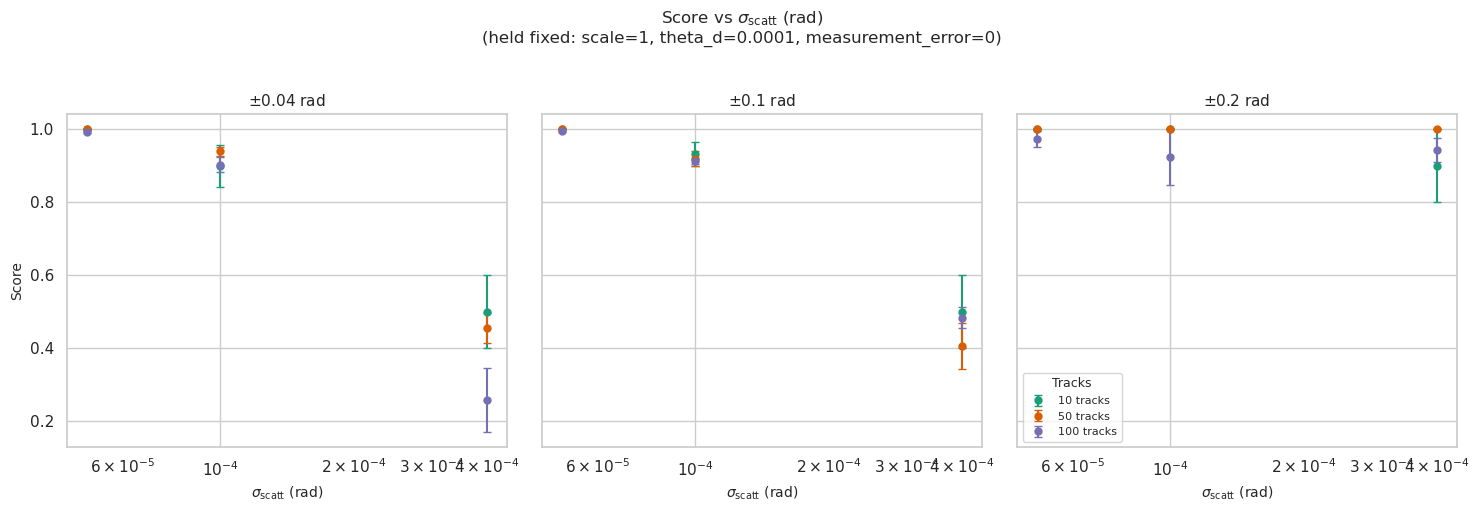

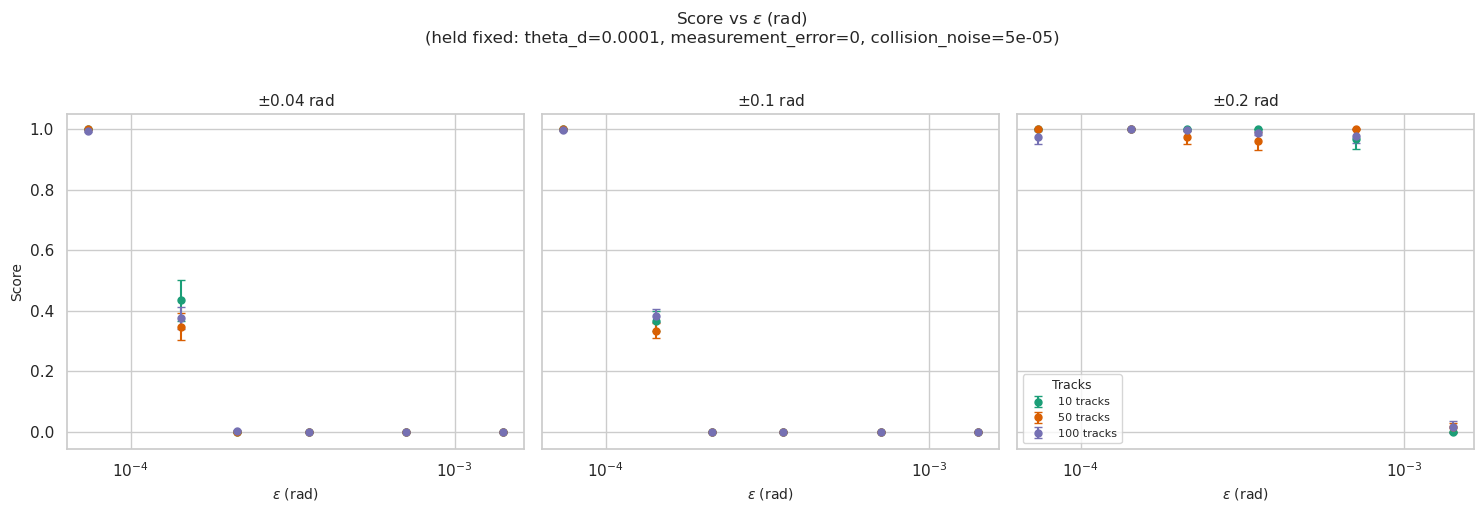

In [70]:
# ── Generate all metric × parameter-scan plots ──
SCAN_PLOT_DIR = PLOT_DIR / 'param_scans'
SCAN_PLOT_DIR.mkdir(exist_ok=True)

for mcol, secol, mname in ALL_METRICS:
    for scan_col, scan_label, logx in SCAN_PARAMS:
        safe_metric = mname.replace(' ', '_').replace('(', '').replace(')', '').lower()
        safe_scan = scan_col
        fname = f'scan_{safe_scan}__{safe_metric}.png'
        plot_single_metric_scan(df, opt_baseline, scan_col, scan_label, logx,
                                mcol, secol, mname,
                                save_name=f'param_scans/{fname}')

---
## H. Summary Dashboard

### H18. Best Parameters Table

In [71]:
# Best (k, theta_d) for each (angle, n_tracks) condition, at default physics
best_table = find_optimal(
    df[(df.measurement_error == 0.0) & (df.collision_noise == 1e-4)],
    ['angle', 'n_tracks']
)[['angle', 'n_tracks', 'scale', 'theta_d', 'epsilon',
   'm_reconstruction_efficiency_mean', 'm_ghost_rate_mean',
   'm_clone_fraction_total_mean',
   'hit_purity_mean_primary_mean', 'hit_efficiency_mean_primary_mean',
   'score']].sort_values(['angle', 'n_tracks'], ascending=[False, True])

best_table = best_table.rename(columns={
    'scale': 'k', 'epsilon': 'ε',
    'm_reconstruction_efficiency_mean': 'Eff',
    'm_ghost_rate_mean': 'Ghost',
    'm_clone_fraction_total_mean': 'Clone',
    'hit_purity_mean_primary_mean': 'Purity',
    'hit_efficiency_mean_primary_mean': 'Hit Eff',
})

print('H18. Best Parameters — Default Physics (σ_res=0, σ_scatt=1e-4)')
print('=' * 90)
best_table.style.format({
    'ε': '{:.6f}', 'Eff': '{:.3f}', 'Ghost': '{:.3f}',
    'Clone': '{:.3f}', 'Purity': '{:.3f}', 'Hit Eff': '{:.3f}',
    'score': '{:.3f}', 'theta_d': '{:.0e}',
})

H18. Best Parameters — Default Physics (σ_res=0, σ_scatt=1e-4)


,angle,n_tracks,k,theta_d,ε,Eff,Ghost,Clone,Purity,Hit Eff,score
1306,0.200000,10,1,1e-03,0.000143,1.000,0.000,0.000,1.000,1.000,1.000
1522,0.200000,50,1,1e-03,0.000143,1.000,0.000,0.000,1.000,1.000,1.000
1774,0.200000,100,2,1e-03,0.000284,0.993,0.000,0.000,1.000,1.000,0.993
658,0.100000,10,1,1e-03,0.000143,1.000,0.000,0.000,1.000,1.000,1.000
874,0.100000,50,1,1e-03,0.000143,1.000,0.000,0.000,1.000,1.000,1.000
1090,0.100000,100,1,1e-03,0.000143,0.993,0.003,0.000,1.000,1.000,0.990
10,0.040000,10,1,1e-03,0.000143,1.000,0.000,0.000,1.000,1.000,1.000
226,0.040000,50,1,1e-03,0.000143,0.987,0.007,0.000,1.000,1.000,0.980
442,0.040000,100,1,1e-03,0.000143,1.000,0.000,0.000,1.000,1.000,1.000


In [72]:
# Full best table across ALL physics conditions
best_all = find_optimal(
    df, ['angle', 'n_tracks', 'measurement_error', 'collision_noise']
)[['angle', 'n_tracks', 'measurement_error', 'collision_noise',
   'scale', 'theta_d', 'epsilon',
   'm_reconstruction_efficiency_mean', 'm_ghost_rate_mean', 'score'
]].sort_values(['angle', 'n_tracks', 'measurement_error', 'collision_noise'],
               ascending=[False, True, True, True])

best_all = best_all.rename(columns={
    'scale': 'k', 'epsilon': 'ε',
    'measurement_error': 'σ_res', 'collision_noise': 'σ_scatt',
    'm_reconstruction_efficiency_mean': 'Eff',
    'm_ghost_rate_mean': 'Ghost',
})

print(f'\nFull best-parameter table: {len(best_all)} conditions')
best_all.to_csv(PLOT_DIR / 'H18_best_parameters.csv', index=False)
print(f'Saved to plots/H18_best_parameters.csv')
best_all.head(15)


Full best-parameter table: 81 conditions
Saved to plots/H18_best_parameters.csv


,angle,n_tracks,σ_res,σ_scatt,k,theta_d,ε,Eff,Ghost,score
1305,0.2,10,0.00,0.00005,1,0.001,0.000074,1.000000,0.000000,1.000000
1306,0.2,10,0.00,0.00010,1,0.001,0.000143,1.000000,0.000000,1.000000
1316,0.2,10,0.00,0.00040,1,0.010,0.000566,1.000000,0.000000,1.000000
1317,0.2,10,0.01,0.00005,1,0.010,0.001052,1.000000,0.000000,1.000000
1318,0.2,10,0.01,0.00010,1,0.010,0.001059,1.000000,0.000000,1.000000
1319,0.2,10,0.01,0.00040,1,0.010,0.001193,1.000000,0.000000,1.000000
1320,0.2,10,0.05,0.00005,1,0.010,0.005249,1.000000,0.000000,1.000000
1321,0.2,10,0.05,0.00010,1,0.010,0.005251,1.000000,0.000000,1.000000
1322,0.2,10,0.05,0.00040,1,0.010,0.005279,0.866667,0.000000,0.866667
1521,0.2,50,0.00,0.00005,1,0.001,0.000074,1.000000,0.000000,1.000000


---
## Summary

Key observations from the Phase 1 coarse scan.

In [73]:
# Quick summary statistics
print('=== Phase 1 Summary ===')
print(f'Total configurations: {len(df)}')
print(f'Perfect score (eff=1, ghost=0): {(df.score == 1.0).sum()}')
print(f'High performance (score > 0.9): {(df.score > 0.9).sum()}')
print(f'Low performance (score < 0.1): {(df.score < 0.1).sum()}')
print()

# Most common optimal k across all conditions
opt_all = find_optimal(df, ['angle', 'n_tracks', 'measurement_error', 'collision_noise'])
print('Most frequent optimal k:')
print(opt_all['scale'].value_counts())
print()
print('Most frequent optimal theta_d:')
print(opt_all['theta_d'].value_counts())
print()

# Worst-performing conditions
worst = df.nsmallest(5, 'score')[['angle','n_tracks','scale','theta_d',
                                   'measurement_error','collision_noise',
                                   'm_reconstruction_efficiency_mean',
                                   'm_ghost_rate_mean','score']]
print('5 worst-scoring configurations:')
print(worst.to_string(index=False))

=== Phase 1 Summary ===
Total configurations: 1944
Perfect score (eff=1, ghost=0): 111
High performance (score > 0.9): 205
Low performance (score < 0.1): 1368

Most frequent optimal k:
scale
1    71
2     8
3     2
Name: count, dtype: int64

Most frequent optimal theta_d:
theta_d
0.0010    37
0.0100    34
0.0001    10
Name: count, dtype: int64

5 worst-scoring configurations:
 angle  n_tracks  scale  theta_d  measurement_error  collision_noise  m_reconstruction_efficiency_mean  m_ghost_rate_mean  score
  0.04        10      1      0.1               0.00          0.00005                               0.0                1.0    0.0
  0.04        10      1      0.1               0.00          0.00010                               0.0                1.0    0.0
  0.04        10      1      0.1               0.00          0.00040                               0.0                1.0    0.0
  0.04        10      1      0.1               0.01          0.00005                               0.0   